### Biological Interpretation of Stress Response, Recovery, and Persistent Expression

### **Purpose**

#### This notebook investigates the biological meaning of the expression patterns identified during exploratory analysis of the *Arabidopsis thaliana* stress-recovery dataset.

#### The previous analysis established which genes responded to stress, how strongly their expression returned toward control after recovery, which genes remained persistently altered, and how persistent-gene sets were shared or differed across stress conditions. Here, those patterns are connected to biological function.

#### The analysis will focus on identifying and characterizing genes associated with persistent expression after recovery, including condition-specific, shared, and high-breadth persistent genes. Gene annotations, known biological functions, functional categories, and pathway or enrichment analyses will be used to determine whether particular biological processes are repeatedly represented within these gene sets and whether different stress conditions show distinct or shared functional patterns.

#### Particular attention will be given to:

#### - the biological functions of genes that remain persistently different from control after recovery;

#### - genes showing persistence across several different stress conditions;

#### - genes whose persistence is restricted to particular stresses;

#### - functional differences between shared and condition-specific persistent responses;

#### - biological processes associated with stronger or weaker recovery;

#### - the relationship between single-stress and combined-stress responses where supported by the data.

#### The goal is not to infer biological mechanisms directly from expression patterns alone, but to use gene annotation and functional evidence to develop biologically grounded interpretations and testable hypotheses from the exploratory results.

#### **Main question:** What biological functions and processes are associated with the stress-response, recovery, and persistent-expression patterns observed across the different stress conditions?

### Loading the Biological Products from exploratory_analyisis Notebook

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
EXPLORATORY_DIR = Path(
    "../data/interim/exploratory_analysis"
)

persistent_genes = pd.read_csv(
    EXPLORATORY_DIR / "persistent_gene_table.csv"
)

high_breadth_genes = pd.read_csv(
    EXPLORATORY_DIR / "high_breadth_persistent_genes.csv"
)

condition_persistence = pd.read_csv(
    EXPLORATORY_DIR / "condition_persistence_summary.csv",
    index_col=0
)

recovery_categories = pd.read_csv(
    EXPLORATORY_DIR / "gene_recovery_categories.csv",
    index_col=0
)

### Inspecting if the Data has been loaded properly

In [3]:
persistent_genes.shape

(3046, 7)

In [4]:
persistent_genes["gene_id"].nunique()

1609

In [5]:
high_breadth_genes.shape

(206, 4)

### Arabidopsis Gene Annotation

#### The exploratory analysis identified several gene sets of interest, including genes showing persistent expression after recovery, genes shared across multiple stress conditions, and genes whose persistence was restricted to particular treatments. 

#### However, the expression matrix contains primarily Arabidopsis locus identifiers such as `AT1G80160`, which by themselves provide little information about biological function.

#### To interpret these expression patterns biologically, the gene identifiers are linked to established Arabidopsis functional annotations. The Araport11 annotation resource is used to obtain available descriptions and functional information for the genes identified during the exploratory analysis.

#### This annotation step provides the connection between the statistical expression patterns and the known or predicted biological roles of the corresponding genes. It therefore forms the foundation for subsequent functional interpretation and enrichment analysis.

#### **Main question:** What biological functions are associated with the genes identified as important during stress response and recovery?

### Deciding our Annotation Reference properly

#### The original RNA-seq study mapped reads against TAIR10, so we want our main gene annotation to remain compatible with the TAIR10/Araport11 gene model ecosystem, rather than casually switching the project to a newer coordinate system

> ### **Note -**
>
> #### TAIR provides bulk Araport11 functional-description files containing functional descriptions for Araport11 gene models, along with companion files for aliases, GO annotations and genomic annotation.

#### We create a separate arabidopsis_annotation folder in data/external

#### For our first annotation artifact, we will be using the TAIR/Araport11 functional-description file:

#### `Araport11_functional_descriptions_20240931.txt.gz`

#### from the TAIR functional annotation release archived on Zenodo

#### We will be extracting the zip file and storing the file on our arabidopsis_annotation folder

In [6]:
ANNOTATION_PATH = Path(
    "../data/external/arabidopsis_annotation/"
    "Araport11_functional_descriptions_20240931.txt"
)

### Inspecting the Annotation File Structure

#### Before loading the annotation resource into a structured table, the first few lines are inspected directly. 

#### This helps identify the file format, header structure, delimiter, gene-identifier format, and any metadata or comment lines that may need to be handled during parsing.

In [7]:
with open(
    ANNOTATION_PATH,
    "r",
    encoding="utf-8"
) as f:
    for _ in range(10):
        print(f.readline().rstrip())

name	gene_model_type	short_description	Curator_summary	Computational_description
AAN	unknown	NULL	Putative QTL located at the top of chromosome 5 with a period-lengthening effect of about 1 h	NULL
ACL1	unknown	NULL	Mutants are defective in leaf and inflorescence meristem. Cauline leaves are small and twisted in appearance. Meristem is smaller in diameter and terminates early so the plants produce fewer flowers.Mapped to  chromosome 4 in the vicinity of locus ap2.	NULL
ACL2	unknown	NULL	Loss of function mutants have reduced internode length. Maps within a region on chr 1 where there is a one nucleotide substitution from G in wild-type plants to A in acl2 mutant plants was detected at 21872231 on the AGI map between now obsolete locus AT1G59535 and AT1G59540.  Bidirectional non-coding RNAs are transcribed from the ACL2 locus, and small RNAs are generated from them in flower stalks.	NULL
ACL3	unknown	NULL	Loss of function mutants have reduced internode length and smaller leaves. May be in

### **Observation —** Initial annotation-file inspection

#### The Araport11 functional-description file is tab-delimited and contains fields describing gene names, gene-model type, short descriptions, curator summaries, and computational descriptions. Missing annotation fields are represented explicitly as NULL.

#### Initial rows contain gene names such as ACL1 and AGE1 rather than the AT... locus identifiers used in the expression matrix. The annotation table therefore cannot yet be joined directly to the expression data. Its identifier structure must first be examined to determine whether Arabidopsis locus IDs are present elsewhere in the file or whether an additional locus-to-gene mapping resource is required.

### Loading the Annotation Table

In [8]:
gene_annotation_raw = pd.read_csv(
    ANNOTATION_PATH,
    sep="\t",
    dtype=str,
    encoding="cp1252"
)

In [9]:
gene_annotation_raw.shape

(64475, 5)

#### 64,475 annotation records and 5 fields

In [10]:
gene_annotation_raw.columns.tolist()

['name',
 'gene_model_type',
 'short_description',
 'Curator_summary',
 'Computational_description']

In [11]:
gene_annotation_raw.head()

,name,gene_model_type,short_description,Curator_summary,Computational_description
0,AAN,unknown,NaN,Putative QTL located at the top of chromosome ...,NaN
1,ACL1,unknown,NaN,Mutants are defective in leaf and inflorescenc...,NaN
2,ACL2,unknown,NaN,Loss of function mutants have reduced internod...,NaN
3,ACL3,unknown,NaN,Loss of function mutants have reduced internod...,NaN
4,ADD1,unknown,NaN,Temperature-sensitive gene required for normal...,NaN


In [12]:
gene_annotation_raw["name"].head(20).tolist()

['AAN',
 'ACL1',
 'ACL2',
 'ACL3',
 'ADD1',
 'AGE1',
 'AGE2',
 'AGI1',
 'ALB2',
 'ALF3',
 'ALS4',
 'AND',
 'ANL1',
 'BGL',
 'BOD1',
 'BOD2',
 'BOD3',
 'CAT4',
 'CH12',
 'CH13']

### Searching the entire Annotation Table for (AT...) names

In [13]:
gene_annotation_raw[
    gene_annotation_raw["name"].str.startswith(
        "AT",
        na=False
    )
].head(20)

,name,gene_model_type,short_description,Curator_summary,Computational_description
263,AT1G75800.1,protein_coding,Pathogenesis-related thaumatin superfamily pro...,NaN,Pathogenesis-related thaumatin superfamily pro...
264,AT1G75690.1,protein_coding,DnaJ/Hsp40 cysteine-rich domain superfamily pr...,Thylakoid Thiol/Disulfide-Modulating Protein.,DnaJ/Hsp40 cysteine-rich domain superfamily pr...
265,AT1G75680.1,protein_coding,glycosyl hydrolase 9B7,NaN,glycosyl hydrolase 9B7;(source:Araport11)
266,AT1G75770.1,protein_coding,NaN,NaN,hypothetical protein;(source:Araport11)
267,AT1G75550.1,protein_coding,glycine-rich protein,NaN,glycine-rich protein;(source:Araport11)
268,AT1G75660.1,protein_coding,5'-3' exoribonuclease 3,Encodes a protein with similarity to yeast 5'-...,5-3 exoribonuclease 3;(source:Araport11)
269,AT1G75760.1,protein_coding,ER lumen protein retaining receptor family pro...,NaN,ER lumen protein retaining receptor family pro...
270,AT1G75540.1,protein_coding,salt tolerance homolog2,Encodes a B-box zinc finger transcription fact...,salt tolerance homolog2;(source:Araport11)
271,AT1G75640.1,protein_coding,Leucine-rich receptor-like protein kinase fami...,Encodes a Leucine-Rich Repeat Receptor-Like Ki...,Leucine-rich receptor-like protein kinase fami...
272,AT1G75750.1,protein_coding,GAST1 protein homolog 1,GA-responsive GAST1 protein homolog regulated ...,GAST1 protein homolog 1;(source:Araport11)


### **Observation —** Annotation identifier level

#### The expression matrix and the Araport annotation resource represent genes at different identifier levels. The expression matrix uses gene/locus identifiers such as `AT1G75800`, whereas the annotation file contains transcript or gene-model identifiers such as `AT1G75800.1`.

#### A locus identifier refers to the genomic gene region, while suffixes such as `.1`, `.2`, and `.3` distinguish annotated transcript models associated with that locus. A single locus can therefore have more than one transcript record in the annotation file.

#### Because the expression matrix contains one record per locus rather than separate transcript-level measurements, the annotation data should not be merged directly using the original name field. 

#### The transcript identifiers must first be connected to their corresponding locus identifiers, and loci with multiple transcript records must be handled appropriately before annotation is joined to the expression data.

### Finding annotation rows that look like Arabidopsis locus/transcript identifiers rather than ordinary gene symbols.

> ### **Note -**
>
> #### Arabidopsis has both organellar loci. (ATMG..) for Mitochondrial loci and (ATCG..) for Choloroplast loci

In [14]:
gene_annotation_raw["name"].str.match(
    r"^AT[1-5MC]G\d+",
    na=False
).sum()

np.int64(59900)

#### Regex found 59,900 rows beginning with an Arabidopsis locus-style identifier. 

#### Since the full file contains 64,475 rows, about 4,575 rows must be other names such as gene symbols or legacy names.

### Building the locus-level annotation subset

In [15]:
model_mask = gene_annotation_raw["name"].str.match(
    r"^AT[1-5MC]G\d+\.\d+$",
    na=False
)

annotation_models = (
    gene_annotation_raw.loc[model_mask]
    .copy()
)

In [16]:
annotation_models["gene_id"] = (
    annotation_models["name"]
    .str.replace(
        r"\.\d+$",
        "",
        regex=True
    )
)

In [17]:
annotation_models.shape

(59782, 6)

In [18]:
annotation_models["gene_id"].nunique()

38208

In [19]:
annotation_models[
    ["name", "gene_id", "gene_model_type",
     "short_description"]
].head(10)

,name,gene_id,gene_model_type,short_description
263,AT1G75800.1,AT1G75800,protein_coding,Pathogenesis-related thaumatin superfamily pro...
264,AT1G75690.1,AT1G75690,protein_coding,DnaJ/Hsp40 cysteine-rich domain superfamily pr...
265,AT1G75680.1,AT1G75680,protein_coding,glycosyl hydrolase 9B7
266,AT1G75770.1,AT1G75770,protein_coding,NaN
267,AT1G75550.1,AT1G75550,protein_coding,glycine-rich protein
268,AT1G75660.1,AT1G75660,protein_coding,5'-3' exoribonuclease 3
269,AT1G75760.1,AT1G75760,protein_coding,ER lumen protein retaining receptor family pro...
270,AT1G75540.1,AT1G75540,protein_coding,salt tolerance homolog2
271,AT1G75640.1,AT1G75640,protein_coding,Leucine-rich receptor-like protein kinase fami...
272,AT1G75750.1,AT1G75750,protein_coding,GAST1 protein homolog 1


### Checking how many transcript model each locus has

In [20]:
models_per_gene = (
    annotation_models
    .groupby("gene_id")
    .size()
)

models_per_gene.describe()

count    38208.000000
mean         1.564646
std          1.225598
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         27.000000
dtype: float64

In [21]:
models_per_gene.sort_values(
    ascending=False
).head(20)

gene_id
AT4G30820    27
AT2G23985    26
AT4G16990    19
AT1G06710    19
AT4G17310    17
AT4G32850    17
AT5G43990    17
AT5G62165    17
AT2G04790    16
AT2G37150    15
AT1G09195    15
AT1G51270    15
AT2G30740    15
AT5G66600    15
AT1G05710    14
AT2G20950    14
AT5G09690    14
AT4G25434    13
AT1G07780    13
AT3G08840    13
dtype: int64

In [22]:
persistent_gene_ids = set(
    persistent_genes["gene_id"]
)

annotation_gene_ids = set(
    annotation_models["gene_id"]
)

matched_persistent = (
    persistent_gene_ids
    & annotation_gene_ids
)

len(matched_persistent)

1609

In [23]:
len(persistent_gene_ids - annotation_gene_ids)

0

In [24]:
annotation_models[
    annotation_models["gene_id"].isin(
        ["AT1G80160", "AT2G43570"]
    )
][
    [
        "name",
        "gene_id",
        "gene_model_type",
        "short_description",
        "Curator_summary",
        "Computational_description",
    ]
]

,name,gene_id,gene_model_type,short_description,Curator_summary,Computational_description
1489,AT1G80160.1,AT1G80160,protein_coding,Lactoylglutathione lyase / glyoxalase I family...,Vicinal oxygen chelate (VOC) superfamily member.,Lactoylglutathione lyase / glyoxalase I family...
26197,AT2G43570.1,AT2G43570,protein_coding,"chitinase, putative",Putative basic chitinase.,chitinase;(source:Araport11)
36376,AT1G80160.2,AT1G80160,protein_coding,Lactoylglutathione lyase / glyoxalase I family...,Vicinal oxygen chelate (VOC) superfamily member.,Lactoylglutathione lyase / glyoxalase I family...
58316,AT1G80160.3,AT1G80160,protein_coding,NaN,Vicinal oxygen chelate (VOC) superfamily member.,Lactoylglutathione lyase / glyoxalase I family...


### **Observations -**

#### - 59,782 transcript/gene-model records

#### - 38,208 unique Arabidopsis loci

#### - median = 1 transcript model per locus

#### - 75th percentile = 2 models

#### - maximum = 27 models

#### - 1,609 / 1,609 persistent genes matched

#### - 0 persistent genes unmatched

#### - `AT1G80160`, one of the two genes persistent across eight stress conditions, contains three protein-coding transcript models. Its available annotation fields consistently associate the locus with the lactoylglutathione lyase / glyoxalase I family and the VOC superfamily, although one transcript model lacks a short description.

#### - `AT2G43570`, the other eight-condition persistent gene, contains one protein-coding transcript model and is annotated as a putative chitinase / putative basic chitinase.

#### - Importantly, 100 % annotation coverage of our persistent-gene set

#### - So we do not have an identifier-mapping problem between our GEO expression matrix and the Araport11 annotation resource.

### **Insight —** Araport11 identifier harmonization and coverage

#### The Araport11 functional-description resource contains 59,782 transcript/gene-model records representing 38,208 unique Arabidopsis loci. 

#### Because individual loci can be represented by multiple transcript models—the median was one model per locus, the 75th percentile was two, and some loci contained as many as 27—the transcript-level annotation table cannot be treated directly as a one-row-per-gene resource.

#### Removing the terminal transcript suffix allows these model identifiers to be linked to the locus-level identifiers used in the expression analysis. 

#### However, loci with multiple transcript records will need to be consolidated carefully rather than represented by an arbitrarily selected model because annotation information may be repeated, complementary, or missing in individual transcript records.

#### All 1,609 persistent genes identified during exploratory analysis were present in the Araport11 locus set, with zero unmatched persistent genes. The annotation resource therefore provides complete identifier coverage for the persistent-gene set, allowing all of these genes to be carried forward for gene-level annotation.

#### Preliminary inspection of the two highest-breadth persistent genes showed that `AT1G80160` is associated with glyoxalase-I-family/VOC-superfamily annotations, while `AT2G43570` is annotated as a putative chitinase.

#### Their biological relevance to the observed persistence patterns will be evaluated later after transcript-level annotations are consolidated to one record per locus.

### Consolidating Transcript Annotations to one record per gene

#### Araport gives us multiple transcript-level annotation rows per gene, but our biological analysis is gene-level. 

#### So we need to combine all useful transcript annotations into one reliable row per gene without arbitrarily throwing information away.

In [25]:
def combine_unique(values):
    values = (
        values
        .dropna()
        .astype(str)                        # ensures the remaining values are strings
        .str.strip()                        # removes extra white-spaces
    )

    values = values[
        (values != "")                      # removing empty strings and literal NULL
        & (values != "NULL")
    ]

    unique_values = list(                   # removing dupliate annotations
        dict.fromkeys(values)
    )

    if not unique_values:
        return pd.NA                        # mark the results as missing if gene has no useful annotation value after cleaning 

    return " | ".join(unique_values)        # combine multiple distinct annotations

### Building the Gene-level Annotation Table

In [26]:
gene_annotation = (
    annotation_models
    .groupby("gene_id")
    .agg(
        transcript_count=("name", "size"),          # counting how many transcript-model rows belong to this gene

        gene_model_type=(
            "gene_model_type",                     # taking all the gene_model_type values of the genes and ;
            combine_unique                         # combining the unique values into one
        ),

        short_description=(
            "short_description",
            combine_unique
        ),

        curator_summary=(
            "Curator_summary",
            combine_unique
        ),

        computational_description=(
            "Computational_description",
            combine_unique
        ),
    )
    .reset_index()
)

In [27]:
gene_annotation.shape

(38208, 6)

In [28]:
gene_annotation["gene_id"].duplicated().sum()

np.int64(0)

### Inspecting the two High-breadth Genes

In [29]:
gene_annotation[
    gene_annotation["gene_id"].isin(
        ["AT1G80160", "AT2G43570"]
    )
]

,gene_id,transcript_count,gene_model_type,short_description,curator_summary,computational_description
9611,AT1G80160,3,protein_coding,Lactoylglutathione lyase / glyoxalase I family...,Vicinal oxygen chelate (VOC) superfamily member.,Lactoylglutathione lyase / glyoxalase I family...
15509,AT2G43570,1,protein_coding,"chitinase, putative",Putative basic chitinase.,chitinase;(source:Araport11)


### Rebuilding the Persistence Summary

#### Now we are creating one row per persistent gene

In [30]:
persistent_direction_summary = (
    persistent_genes
    .groupby("gene_id")
    .agg(
        n_persistent_conditions=(
            "condition",
            "nunique"
        ),

        n_persistent_up=(
            "direction",
            lambda x: (x == "up").sum()
        ),

        n_persistent_down=(
            "direction",
            lambda x: (x == "down").sum()
        ),
    )
    .reset_index()
)

In [31]:
persistent_direction_summary.shape

(1609, 4)

In [32]:
persistent_direction_summary.head()

,gene_id,n_persistent_conditions,n_persistent_up,n_persistent_down
0,AT1G01340,2,2,0
1,AT1G01480,5,5,0
2,AT1G01560,4,4,0
3,AT1G01680,3,3,0
4,AT1G01720,1,1,0


### Key Integration Step

#### We are merging the expression-analysis result with their biological annotations

#### We merge them using the `gene_id` because both now use the same locus level identifier

#### This creates a single table containing both persistence characteristics and functional annotation for each persistent gene, providing the basis for downstream biological interpretation

In [33]:
persistent_gene_annotation = (
    persistent_direction_summary
    .merge(
        gene_annotation,
        on="gene_id",
        how="left",
        validate="one_to_one"
    )
)

In [34]:
persistent_gene_annotation.shape

(1609, 9)

### Checking the Missing Short Descriptions

#### We are checking how many of the matched genes that we found earlier actually have a short functional description

In [35]:
persistent_gene_annotation[
    "short_description"
].isna().sum()

np.int64(131)

#### 131 genes lack `short_description` but that does not necessarily mean 131 genes are functionally unannotated. Some may have a curator or computational description

### Inspecting the Highest-Breadth Annotated Genes

In [36]:
persistent_gene_annotation.sort_values(
    "n_persistent_conditions",
    ascending=False
).head(20)[
    [
        "gene_id",
        "n_persistent_conditions",
        "n_persistent_up",
        "n_persistent_down",
        "transcript_count",
        "short_description",
        "curator_summary",
    ]
]

,gene_id,n_persistent_conditions,n_persistent_up,n_persistent_down,transcript_count,short_description,curator_summary
416,AT1G80160,8,8,0,3,Lactoylglutathione lyase / glyoxalase I family...,Vicinal oxygen chelate (VOC) superfamily member.
639,AT2G43570,8,8,0,1,"chitinase, putative",Putative basic chitinase.
1017,AT4G01985,7,7,0,3,<NA>,<NA>
1173,AT4G24000,7,7,0,2,cellulose synthase like G2,encodes a protein similar to cellulose synthase
125,AT1G21310,7,7,0,1,extensin 3,Encodes extensin 3.
861,AT3G26830,7,7,0,1,Cytochrome P450 superfamily protein,Mutations in pad3 are defective in biosynthesi...
123,AT1G21250,7,7,0,1,cell wall-associated kinase,Encodes a cell wall-associated kinase that int...
1330,AT5G13370,7,7,0,1,Auxin-responsive GH3 family protein,IBA - specific acyl acid amido synthetase whic...
483,AT2G19900,7,7,0,2,NADP-malic enzyme 1,The malic enzyme (EC 1.1.1.40) encoded by AtNA...
969,AT3G56710,7,7,0,2,sigma factor binding protein 1,Sig1 binding protein; interacts with Sig1R4. A...


### **Observations -**

#### - gene_annotation: 38,208 loci × 6 fields

#### - duplicated gene_ids: 0

#### - persistent_direction_summary: 1,609 genes

#### - all persistent genes successfully merged into the annotation layer

#### - only 131 / 1,609 persistent genes lack a short_description, so about 91.9% already have a short functional description

### Assessing Functional Annotation Completeness

In [37]:
annotation_completeness = pd.DataFrame({
    "short_description_available":
        persistent_gene_annotation[
            "short_description"
        ].notna(),

    "curator_summary_available":
        persistent_gene_annotation[
            "curator_summary"
        ].notna(),

    "computational_description_available":
        persistent_gene_annotation[
            "computational_description"
        ].notna(),
})

In [38]:
annotation_completeness.sum()

short_description_available            1478
curator_summary_available              1016
computational_description_available    1609
dtype: int64

In [39]:
no_description_anywhere = ~(
    annotation_completeness[
        "short_description_available"
    ]
    |
    annotation_completeness[
        "curator_summary_available"
    ]
    |
    annotation_completeness[
        "computational_description_available"
    ]
)

no_description_anywhere.sum()

np.int64(0)

In [40]:
persistent_gene_annotation["best_description"] = (
    persistent_gene_annotation["short_description"]
    .fillna(
        persistent_gene_annotation[
            "curator_summary"
        ]
    )
    .fillna(
        persistent_gene_annotation[
            "computational_description"
        ]
    )
)

In [41]:
persistent_gene_annotation[
    "best_description"                # first available description according to our chosen priority
].isna().sum()

np.int64(0)

#### Annotation coverage was evaluated across the short-description, curator-summary, and computational-description fields for all persistent genes.

#### Genes lacking individual annotation fields were retained because useful information may still be available from another field. 

#### A representative description was then constructed using a fixed priority order: short description first, followed by curator summary and computational description when earlier fields were unavailable.

#### This step distinguishes simple identifier coverage from actual descriptive annotation coverage and determines how completely the persistent-gene set can be interpreted biologically.

### **Observations -**

#### short_description: 1,478 / 1,609 = 91.9%

#### curator_summary: 1,016 / 1,609 = 63.1%

#### computational_description: 1,609 / 1,609 = 100%

#### no description anywhere: 0

#### missing best_description: 0

### **Insight —** Functional annotation completeness

#### Araport11 provided at least one descriptive annotation for all 1,609 persistent genes. 

#### Short functional descriptions were available for 1,478 genes (~91.9%), curator summaries for 1,016 (~63.1%), and computational descriptions for all 1,609 genes. 

#### Consequently, no persistent gene lacked annotation across all three descriptive fields, and the derived best_description field achieved 100% coverage.

#### Complete descriptive coverage does not imply equal confidence in the biological function assigned to every gene. Annotation provenance is therefore retained because short descriptions, curator summaries, and computational descriptions may differ in the type and strength of evidence supporting them.

### Saving the Cleaned Annotation Table

In [42]:
from pathlib import Path

BIOLOGICAL_INTERPRETATION_DIR = Path(
    "../data/interim/biological_interpretation"
)

BIOLOGICAL_INTERPRETATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [43]:
ANNOTATED_OUTPUT = (
    BIOLOGICAL_INTERPRETATION_DIR
    / "persistent_gene_annotation.csv"
)

persistent_gene_annotation.to_csv(
    ANNOTATED_OUTPUT,
    index=False
)

### Functional Annotation of High-Breadth Persistent Genes

#### Genes persistent across four or more stress conditions were selected as the high-breadth persistent set. 

#### Their gene-model types and representative functional descriptions were examined to determine whether broadly shared persistence is associated with recurring classes of genes or biological functions.

### Selecting High-Breadth Persistent Genes

In [44]:
high_breadth_annotation = (
    persistent_gene_annotation[
        persistent_gene_annotation[
            "n_persistent_conditions"
        ] >= 4
    ]
    .copy()
    .sort_values(
        "n_persistent_conditions",
        ascending=False
    )
)

In [45]:
high_breadth_annotation.shape

(206, 10)

In [46]:
high_breadth_annotation[
    "gene_model_type"
].value_counts(dropna=False)

gene_model_type
protein_coding    206
Name: count, dtype: int64

### Inspecting the Top High-Breadth Genes

In [47]:
high_breadth_annotation[
    [
        "gene_id",
        "n_persistent_conditions",
        "n_persistent_up",
        "n_persistent_down",
        "gene_model_type",
        "best_description",
    ]
].head(25)

,gene_id,n_persistent_conditions,n_persistent_up,n_persistent_down,gene_model_type,best_description
416,AT1G80160,8,8,0,protein_coding,Lactoylglutathione lyase / glyoxalase I family...
639,AT2G43570,8,8,0,protein_coding,"chitinase, putative"
125,AT1G21310,7,7,0,protein_coding,extensin 3
286,AT1G61800,7,7,0,protein_coding,glucose-6-phosphate/phosphate translocator 2
123,AT1G21250,7,7,0,protein_coding,cell wall-associated kinase
54,AT1G09500,7,7,0,protein_coding,NAD(P)-binding Rossmann-fold superfamily protein
1072,AT4G12480,7,7,0,protein_coding,Bifunctional inhibitor/lipid-transfer protein/...
1173,AT4G24000,7,7,0,protein_coding,cellulose synthase like G2
861,AT3G26830,7,7,0,protein_coding,Cytochrome P450 superfamily protein
969,AT3G56710,7,7,0,protein_coding,sigma factor binding protein 1


### **Insight —** Composition of the High-Breadth Persistent Gene Set

#### All 206 genes classified as persistent across four or more stress conditions were annotated as protein-coding loci in Araport11. The high-breadth persistent set is therefore composed entirely of protein-coding genes rather than a mixture containing non-coding RNA, pseudogene, or transposable-element gene models.

#### Inspection of individual gene descriptions indicates considerable functional diversity, with annotations related to signaling, defense, cell-wall biology, metabolism, transport, redox-associated enzymes, and transcriptional regulation among the high-breadth genes. These individual examples, however, do not establish that any particular biological function is characteristic of the set as a whole.

#### Determining whether specific biological processes or molecular functions are disproportionately represented will require systematic ontology- or pathway-based enrichment analysis rather than interpretation from selected gene descriptions alone.

### Gene Ontology Annotation and Functional Interpretation

#### The previous steps identified genes whose expression remained persistently different from control after recovery and grouped them according to how broadly that persistence was shared across stress conditions. Araport11 functional descriptions allowed individual genes to be examined, but free-text descriptions are not sufficient for systematic analysis of hundreds of genes.

#### The Gene Ontology (GO) annotation dataset is therefore introduced to connect Arabidopsis genes to standardized biological terms. GO annotations describe genes and their products through three complementary aspects:

#### Biological Process (BP) — the broader biological processes in which a gene participates, such as stress response, signaling, metabolism, or cell-wall organization.

#### Molecular Function (MF) — the molecular activity performed by the gene product, such as catalytic activity, binding, transport, or kinase activity.

#### Cellular Component (CC) — the cellular location or structure associated with the gene product, such as the nucleus, chloroplast, membrane, or cytoplasm.

#### A single gene can be associated with multiple GO terms because one gene product may participate in several processes, perform particular molecular functions, and occur in specific cellular locations. The GO annotation table therefore contains multiple records per gene rather than one row per locus.

#### The dataset also contains GO Slim annotations. GO Slim provides broader biological categories that summarize the much more detailed Gene Ontology hierarchy. Full GO terms are useful for specific functional analysis, while GO Slim terms provide a higher-level overview of the major types of biology represented in a gene set.

#### The first stage is to inspect the GO resource, understand its structure and evidence fields, and determine how completely it covers the persistent and high-breadth gene sets. Once the identifiers and annotation coverage have been validated, GO terms can be linked to the persistent genes.

#### The subsequent analysis will use these standardized annotations for functional enrichment analysis. Enrichment asks whether particular GO terms occur more frequently within a selected gene set than expected relative to an appropriate background set of genes. This provides a statistical way to identify biological processes, molecular functions, or cellular components that may characterize shared or condition-specific persistent expression.

### Adding the GO Annotation Source

> ### **Note -**
>
> #### The same TAIR functional-annotation release we used for Araport11 descriptions contains:
>
> #### `ATH_GO_GOSLIM.txt.gz`
>
> #### TAIR describes this as a tab-delimited file containing Gene Ontology annotations for Arabidopsis genes, including GO controlled-vocabulary annotations.
>
> ### Gene Ontology :
>
> #### Gene Ontology is a standardized vocabulary for describing what genes and their products are associated with.
>
> #### It is a giant biological classification system.

In [48]:
GO_GZ_PATH = Path(
    "../data/external/arabidopsis_annotation/"
    "ATH_GO_GOSLIM.txt.gz"
)

with open(GO_GZ_PATH, "rb") as f:
    print(f.read(4))

b'PK\x03\x04'


In [49]:
import zipfile

with zipfile.ZipFile(GO_GZ_PATH, "r") as z:
    print(z.namelist())

['ATH_GO_GOSLIM.txt']


In [50]:
import shutil
import zipfile

GO_PATH = Path(
    "../data/external/arabidopsis_annotation/"
    "ATH_GO_GOSLIM.txt"
)

with zipfile.ZipFile(GO_GZ_PATH, "r") as z:
    with z.open("ATH_GO_GOSLIM.txt") as source:
        with open(GO_PATH, "wb") as target:
            shutil.copyfileobj(source, target)

In [51]:
with open(GO_PATH, "rb") as f:
    print(f.read(20))

b'!Project_name: The A'


In [52]:
with open(
    GO_PATH,
    "r",
    encoding="utf-8"
) as f:
    for _ in range(10):
        print(f.readline().rstrip())

!Project_name: The Arabidopsis Information Resource (TAIR)
!URL: http://www.arabidopsis.org
!Contact Email: curator@arabidopsis.org
!Last Updated: 2024-10-01
AT1G01010	locus:2200935	AT1G01010	acts upstream of or within	regulation of DNA-templated transcription	GO:0006355	7461	P	other metabolic processes	ISS	none		Publication:1345963|PMID:11118137  		2024-04-20
AT1G01010	locus:2200935	AT1G01010	acts upstream of or within	regulation of DNA-templated transcription	GO:0006355	7461	P	nucleobase-containing compound metabolic process	ISS	none		Publication:1345963|PMID:11118137  		2024-04-20
AT1G01010	locus:2200935	AT1G01010	enables	transcription cis-regulatory region binding	GO:0000976	35767	F	DNA binding	IPI	yeast one-hybrid assay	AGI_LocusCode:AT2G38290	Publication:501786139|PMID:30356219  	sibrady	2020-12-18
AT1G01010	gene:2200934	AT1G01010.1	located in	nucleus	GO:0005634	537	C	nucleus	ISM	predicted protein features		AnalysisReference:501780126	rkaundal	2018-08-31
AT1G01010	locus:2200935	A

### Loading the GO Annotation Table

In [53]:
go_annotation_raw = pd.read_csv(
    GO_PATH,
    sep="\t",
    comment="!",
    header=None,
    dtype=str,
    encoding="utf-8"
)

### Inspecting the Biological Metadata

In [54]:
go_annotation_raw.shape

(337091, 15)

In [55]:
go_annotation_raw.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,AT1G01010,locus:2200935,AT1G01010,acts upstream of or within,regulation of DNA-templated transcription,GO:0006355,7461,P,other metabolic processes,ISS,none,NaN,Publication:1345963|PMID:11118137,NaN,2024-04-20
1,AT1G01010,locus:2200935,AT1G01010,acts upstream of or within,regulation of DNA-templated transcription,GO:0006355,7461,P,nucleobase-containing compound metabolic process,ISS,none,NaN,Publication:1345963|PMID:11118137,NaN,2024-04-20
2,AT1G01010,locus:2200935,AT1G01010,enables,transcription cis-regulatory region binding,GO:0000976,35767,F,DNA binding,IPI,yeast one-hybrid assay,AGI_LocusCode:AT2G38290,Publication:501786139|PMID:30356219,sibrady,2020-12-18
3,AT1G01010,gene:2200934,AT1G01010.1,located in,nucleus,GO:0005634,537,C,nucleus,ISM,predicted protein features,NaN,AnalysisReference:501780126,rkaundal,2018-08-31
4,AT1G01010,locus:2200935,AT1G01010,involved in,regulation of DNA-templated transcription,GO:0006355,7461,P,other cellular processes,IEA,none,InterPro:IPR003441|InterPro:IPR036093,AnalysisReference:501756966,NaN,2024-04-19


In [56]:
go_annotation_raw.head(3).T

,0,1,2
0,AT1G01010,AT1G01010,AT1G01010
1,locus:2200935,locus:2200935,locus:2200935
2,AT1G01010,AT1G01010,AT1G01010
3,acts upstream of or within,acts upstream of or within,enables
4,regulation of DNA-templated transcription,regulation of DNA-templated transcription,transcription cis-regulatory region binding
5,GO:0006355,GO:0006355,GO:0000976
6,7461,7461,35767
7,P,P,F
8,other metabolic processes,nucleobase-containing compound metabolic process,DNA binding
9,ISS,ISS,IPI


In [57]:
go_annotation_raw.shape[1]

15

### **Observations -**

#### The file contains 337,091 annotation records × 15 fields. The structure visible in the sample also matches the documented `TAIR ATH_GO_GOSLIM` format. 

#### It contains the underlying GO annotation plus a mapped GO-slim category, and the file has 15 columns.

#### Here P, F, and C correspond to Biological Process, Molecular Function, and Cellular Component.

#### For our project, we do not need to understand every administrative field before proceeding. The biologically important fields are already clear.

### Assigning descriptive column names based on the structure of the GO annotation file

In [58]:
go_columns = [
    "gene_id",
    "tair_object_id",
    "object_name",
    "go_relationship",
    "go_term",
    "go_id",
    "go_numeric_id",
    "go_aspect",
    "go_slim_term",
    "evidence_code",
    "evidence_detail",
    "evidence_with",
    "reference",
    "annotator",
    "annotation_date",
]

go_annotation_raw.columns = go_columns

In [59]:
go_annotation_raw.head()

,gene_id,tair_object_id,object_name,go_relationship,go_term,go_id,go_numeric_id,go_aspect,go_slim_term,evidence_code,evidence_detail,evidence_with,reference,annotator,annotation_date
0,AT1G01010,locus:2200935,AT1G01010,acts upstream of or within,regulation of DNA-templated transcription,GO:0006355,7461,P,other metabolic processes,ISS,none,NaN,Publication:1345963|PMID:11118137,NaN,2024-04-20
1,AT1G01010,locus:2200935,AT1G01010,acts upstream of or within,regulation of DNA-templated transcription,GO:0006355,7461,P,nucleobase-containing compound metabolic process,ISS,none,NaN,Publication:1345963|PMID:11118137,NaN,2024-04-20
2,AT1G01010,locus:2200935,AT1G01010,enables,transcription cis-regulatory region binding,GO:0000976,35767,F,DNA binding,IPI,yeast one-hybrid assay,AGI_LocusCode:AT2G38290,Publication:501786139|PMID:30356219,sibrady,2020-12-18
3,AT1G01010,gene:2200934,AT1G01010.1,located in,nucleus,GO:0005634,537,C,nucleus,ISM,predicted protein features,NaN,AnalysisReference:501780126,rkaundal,2018-08-31
4,AT1G01010,locus:2200935,AT1G01010,involved in,regulation of DNA-templated transcription,GO:0006355,7461,P,other cellular processes,IEA,none,InterPro:IPR003441|InterPro:IPR036093,AnalysisReference:501756966,NaN,2024-04-19


### Inspecting the Most Relevant GO Fields

In [60]:
go_annotation_raw[
    [
        "gene_id",
        "object_name",
        "go_relationship",
        "go_term",
        "go_id",
        "go_aspect",
        "go_slim_term",
        "evidence_code",
    ]
].head(10)

,gene_id,object_name,go_relationship,go_term,go_id,go_aspect,go_slim_term,evidence_code
0,AT1G01010,AT1G01010,acts upstream of or within,regulation of DNA-templated transcription,GO:0006355,P,other metabolic processes,ISS
1,AT1G01010,AT1G01010,acts upstream of or within,regulation of DNA-templated transcription,GO:0006355,P,nucleobase-containing compound metabolic process,ISS
2,AT1G01010,AT1G01010,enables,transcription cis-regulatory region binding,GO:0000976,F,DNA binding,IPI
3,AT1G01010,AT1G01010.1,located in,nucleus,GO:0005634,C,nucleus,ISM
4,AT1G01010,AT1G01010,involved in,regulation of DNA-templated transcription,GO:0006355,P,other cellular processes,IEA
5,AT1G01010,AT1G01010,involved in,regulation of DNA-templated transcription,GO:0006355,P,other metabolic processes,IEA
6,AT1G01010,AT1G01010,enables,transcription cis-regulatory region binding,GO:0000976,F,nucleic acid binding,IPI
7,AT1G01010,AT1G01010,enables,DNA-binding transcription factor activity,GO:0003700,F,DNA-binding transcription factor activity,ISS
8,AT1G01010,AT1G01010,involved in,regulation of DNA-templated transcription,GO:0006355,P,biosynthetic process,IEA
9,AT1G01010,AT1G01010,acts upstream of or within,regulation of DNA-templated transcription,GO:0006355,P,other cellular processes,ISS


### Checking representation of Biological Process, Molecular Function and Cellular Component annotations

In [61]:
go_annotation_raw[
    "go_aspect"
].value_counts(dropna=False)

go_aspect
P    140333
C    104078
F     92680
Name: count, dtype: int64

In [62]:
go_annotation_raw[
    "gene_id"                                          # checking the unique values
].nunique()

31036

In [63]:
persistent_ids = set(
    persistent_gene_annotation["gene_id"]              # creating the persistence gene set
)

go_annotated_ids = set(
    go_annotation_raw["gene_id"]                       # creating the set of genes represented in GO
)

len(
    persistent_ids & go_annotated_ids                  # checking how many persistence genes have GO annotations
)

1608

In [64]:
len(
    persistent_ids - go_annotated_ids                 # checking how many persistence genes lack GO annotation
)

1

In [65]:
persistent_ids - go_annotated_ids                    # identifying the gene that lack GO annotation

{'AT1G31173'}

In [66]:
high_breadth_ids = set(                              # checking GO coverage for the high-breadth gene set
    high_breadth_annotation["gene_id"]               # creating IDs for our 206 high breadth persistence genes
)

len(
    high_breadth_ids & go_annotated_ids              # checking how many of the persistence genes have atleast one GO annotation
)

206

### **Insight —** Gene Ontology annotation coverage

#### The TAIR GO annotation resource contained 337,091 annotation records, distributed across Biological Process (140,333), Cellular Component (104,078), and Molecular Function (92,680). These counts represent annotation records rather than unique genes because individual loci can be associated with multiple GO terms.

#### GO coverage of the project-derived persistent-gene sets was nearly complete. 1,608 of 1,609 persistent genes (~99.94%) were represented by at least one GO annotation, with only AT1G31173 absent from the GO annotation table. All 206 high-breadth persistent genes were represented.

#### The high-breadth foreground therefore has complete GO annotation coverage, so no foreground genes will be lost solely because they lack GO annotations. The suitability and annotation coverage of the background gene set will be evaluated separately before formal enrichment analysis.

### Preparing GO Slim Annotations for Functional Enrichment

#### Unique gene-to-GO-Slim mappings are extracted from the full GO annotation resource and cleaned to prevent repeated annotation records from causing the same gene to be counted multiple times within a GO Slim category. The number and distribution of GO Slim terms across the three GO aspects are then examined.

#### The high-breadth persistent genes are defined as the enrichment foreground, while the informative genes available to the recovery analysis provide the candidate background population. GO Slim coverage is assessed separately for both sets before enrichment testing to ensure that differences in annotation availability do not distort the comparison.

### Building a Clean Gene-to-GO-Slim Table

In [67]:
go_slim_pairs = (
    go_annotation_raw[
        [
            "gene_id",
            "go_aspect",
            "go_slim_term"
        ]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

### Cleaning the Text Fields

In [68]:
for column in [
    "gene_id",
    "go_aspect",
    "go_slim_term"
]:
    go_slim_pairs[column] = (
        go_slim_pairs[column]
        .str.strip()
    )

In [69]:
go_slim_pairs.shape

(188875, 3)

### Counting the Unique GO Slim Categories

In [70]:
go_slim_pairs[
    "go_slim_term"
].nunique()

98

### Counting the GO Slim Terms That Belong To Each GO Aspect

In [71]:
go_slim_pairs.groupby(
    "go_aspect"
)["go_slim_term"].nunique()

go_aspect
C    26
F    27
P    45
Name: go_slim_term, dtype: int64

### Defining the Background and Foreground Genes

In [72]:
background_ids = set(
    recovery_categories.index.astype(str)              # this gives us the background genes
)

foreground_ids = set(
    high_breadth_annotation["gene_id"]                 # this gives us the foreground genes
)

>### **Notes -**
>
>#### Background genes :- These are the genes that were available to participate in our recovery/persistence analysis. All the 26,118 informative genes we used throughout the analysis
>
>#### Foreground genes :- These are the special genes that we want to investigate. All the 206 high-breadth persistence genes.

In [73]:
len(background_ids), len(foreground_ids)           # sanity check

(26118, 206)

In [74]:
foreground_ids.issubset(background_ids)           # foreground ids is a subset of background ids that we get after persistence analysis

True

In [75]:
go_slim_gene_ids = set(
    go_slim_pairs["gene_id"]
)

### Background Genes with GO Slim Coverage

In [76]:
len(background_ids & go_slim_gene_ids)

25918

### Background Genes without GO Slim Coverage

In [77]:
len(background_ids - go_slim_gene_ids)

200

### Foreground Genes with GO Slim Coverage

In [78]:
len(foreground_ids & go_slim_gene_ids)

206

### **Observations -**

#### - 188,875 unique gene–GO-slim memberships

#### - 98 distinct GO-slim categories

#### - 45 Biological Process (P)

#### - 27 Molecular Function (F)

#### - 26 Cellular Component (C)

#### - Intended expression background: 26,118 informative genes

#### - Informative genes with at least one GO-slim annotation: 25,918

#### - Informative genes without any GO-slim annotation: 200

#### - All the high-breadth persistent genes have GO-slim annotations: 206

### **Insight —** GO-Slim Mapping and Enrichment Universe

#### After removing duplicate mappings, the GO-slim annotation layer contained 188,875 unique gene–GO-slim memberships across 98 distinct categories, comprising 45 Biological Process, 27 Molecular Function, and 26 Cellular Component terms.

#### Of the 26,118 informative genes available to the expression and recovery analyses, 25,918 (~99.23%) had at least one GO-slim annotation, while only 200 genes lacked GO-slim coverage. All 206 high-breadth persistent genes were represented in the GO-slim resource.

#### The GO-slim enrichment universe will therefore use the 25,918 informative genes with GO-slim annotation as the background, while the 206 high-breadth persistent genes form the foreground. Restricting the background to genes with usable GO-slim information prevents missing annotation from being incorrectly interpreted as biological absence from a functional category.

### GO-Slim Coverage by Ontology Aspect

#### GO-slim coverage is evaluated separately for Biological Process, Molecular Function, and Cellular Component. 

#### Although a gene may have at least one GO-slim annotation overall, it may not be represented in every ontology aspect. 

#### Aspect-specific coverage is therefore examined for both the enrichment foreground and background before defining the statistical universe used for each ontology.

In [79]:
aspect_coverage = []

for aspect in ["P", "F", "C"]:

    aspect_gene_ids = set(
        go_slim_pairs.loc[
            go_slim_pairs["go_aspect"] == aspect,
            "gene_id"
        ]
    )

    aspect_coverage.append({
        "go_aspect": aspect,
        "background_genes": len(
            background_ids & aspect_gene_ids
        ),
        "foreground_genes": len(
            foreground_ids & aspect_gene_ids
        ),
    })

aspect_coverage = pd.DataFrame(
    aspect_coverage
)

aspect_coverage

,go_aspect,background_genes,foreground_genes
0,P,20524,168
1,F,25716,206
2,C,25866,206


### Subset Checking for Each GO Aspect

#### We are checking if every gene in foreground also present in the background.

#### Because the foreground should represent genes selected from within the background population.

In [80]:
aspect_subset_check = []

for aspect in ["P", "F", "C"]:

    aspect_gene_ids = set(
        go_slim_pairs.loc[
            go_slim_pairs["go_aspect"] == aspect,
            "gene_id"
        ]
    )

    aspect_background = (
        background_ids
        & aspect_gene_ids
    )

    aspect_foreground = (
        foreground_ids
        & aspect_gene_ids
    )

    aspect_subset_check.append({
        "go_aspect": aspect,
        "foreground_in_background":
            aspect_foreground.issubset(
                aspect_background
            ),
       
    })

aspect_subset_check = pd.DataFrame(
    aspect_subset_check
)

aspect_subset_check

,go_aspect,foreground_in_background
0,P,True
1,F,True
2,C,True


### **Observations -**

#### The foreground coverage is:

#### Biological Process (P): 168 of 206 high-breadth genes have at least one BP GO-slim assignment.

#### Molecular Function (F): all 206 are represented.

#### Cellular Component (C): all 206 are represented.

#### For the informative background:

#### P: 20,524 genes

#### F: 25,716 genes

#### C: 25,866 genes

### **Insight —** GO-Slim Annotation Coverage by Ontology Aspect

#### GO-slim annotation coverage differed among the three ontology branches. Of the 206 high-breadth persistent genes, all 206 had at least one Molecular Function and Cellular Component GO-slim annotation, whereas 168 genes (~81.6%) had at least one Biological Process annotation.

#### Coverage also differed within the informative-expression background: 20,524 genes were represented in Biological Process, 25,716 in Molecular Function, and 25,866 in Cellular Component.

#### Enrichment will therefore be performed using aspect-specific annotated foreground and background sets. For each ontology branch, only genes with at least one annotation in that branch will be included. This prevents missing annotation within a GO aspect from being interpreted as evidence that a gene does not belong to any category in that aspect.

### GO-slim Enrichment of High-Breadth Persistent Genes

#### GO-slim enrichment is tested separately within Biological Process, Molecular Function, and Cellular Component using the aspect-specific annotated foreground and background sets. 

#### For each GO-slim category, its prevalence among high-breadth persistent genes is compared with its prevalence in the corresponding informative-gene background. 

#### Fisher's exact test is used to test for overrepresentation, while enrichment ratios and odds ratios quantify the magnitude of the association. Raw p-values are retained at this stage and will be corrected for multiple testing before statistical interpretation.

### Fisher’s Exact Test

> ### **Note -** Fisher’s Exact Test
> 
> #### Fisher’s exact test is used to determine whether a particular GO-slim category is overrepresented among the selected high-breadth persistent genes compared with the appropriate background gene set.
> 
> #### For each GO-slim term, the genes are divided according to two questions:
> 
> #### - Is the gene part of the high-breadth foreground or part of the remaining background?
> 
> #### - Does the gene belong to the GO-slim category being tested or not?
> 
> #### Fisher’s exact test then evaluates whether membership in the GO-slim category is associated with membership in the foreground gene set.
> 
> #### Because this analysis is specifically interested in functional enrichment, a one-sided test is used with:
> 
> #### `alternative="greater"`
> 
> #### This asks whether the GO-slim term occurs more frequently among the high-breadth persistent genes than among the remaining background genes.
> 
> #### The test returns two important quantities:
> 
> #### Odds ratio — measures the strength and direction of the association. An odds ratio greater than 1 indicates that the GO-slim category is more strongly represented in the foreground than in the comparison background.
> 
> #### p-value — measures how surprising the observed enrichment would be if there were no real association between foreground membership and the GO-slim category.
> 
> #### A small p-value provides evidence that the category may be overrepresented in the foreground. However, many GO-slim categories are tested simultaneously, so the raw p-values must be corrected for multiple testing before statistical significance is interpreted.
> 
> #### In simple terms:
> 
> #### Fisher’s exact test asks whether a biological category appears among the high-breadth persistent genes more often than would be expected from its frequency in the appropriate background gene set.

In [81]:
from scipy.stats import fisher_exact                      # importing fisher exact test

enrichment_records = []                                   # creating an empty results list

for aspect in ["P", "F", "C"]:                            # analyzing the three GO branches separately 

    aspect_pairs = go_slim_pairs[
        go_slim_pairs["go_aspect"] == aspect              # keeping only annotations for the current aspect
    ]

    aspect_gene_ids = set(                                # finding every gene represented in this aspect
        aspect_pairs["gene_id"]
    )

    background_aspect = (                                 # constructing the aspect specific background
        background_ids & aspect_gene_ids
    )

    foreground_aspect = (                                 # constructing the aspect-specific foreground
        foreground_ids & aspect_gene_ids
    )

    terms = sorted(                                       # getting all the GO slim terms for this aspect
        aspect_pairs["go_slim_term"].unique()
    )

    for term in terms:                                    # testing one GO slim term at a time

        term_gene_ids = set(
            aspect_pairs.loc[
                aspect_pairs["go_slim_term"] == term,
                "gene_id"
            ]
        )

        foreground_with_term = len(                        # counting foreground genes with the term
            foreground_aspect & term_gene_ids
        )

        foreground_without_term = (                        # counting foreground genes without the term
            len(foreground_aspect)
            - foreground_with_term
        )

        background_with_term = len(                        # counting background genes with the term
            background_aspect & term_gene_ids
        )

        other_background_with_term = (                     # removing the foreground from the background comparison group
            background_with_term
            - foreground_with_term
        )

        other_background_without_term = (                  # counting other background genes without the term
            len(background_aspect)
            - len(foreground_aspect)
            - other_background_with_term
        )

        odds_ratio, p_value = fisher_exact(                # running the fisher exact test
            [
                [
                    foreground_with_term,                  # contingency table
                    foreground_without_term
                ],
                [
                    other_background_with_term,
                    other_background_without_term
                ]
            ],
            alternative="greater"                         # we specifically want to test whether this GO category is overrepresented in the foreground
        )

        foreground_fraction = (                           # calculating the foreground fraction
            foreground_with_term
            / len(foreground_aspect)
        )

        background_fraction = (                           # calculating the background fraction
            background_with_term
            / len(background_aspect)
        )

        enrichment_ratio = (                              # calculating the enrichment ratio
            foreground_fraction
            / background_fraction
            if background_fraction > 0
            else np.nan
        )

        enrichment_records.append({                       # saving all the enrichment results
            "go_aspect": aspect,
            "go_slim_term": term,

            "foreground_with_term":
                foreground_with_term,

            "foreground_total":
                len(foreground_aspect),

            "background_with_term":
                background_with_term,

            "background_total":
                len(background_aspect),

            "foreground_fraction":
                foreground_fraction,

            "background_fraction":
                background_fraction,

            "enrichment_ratio":
                enrichment_ratio,

            "odds_ratio":
                odds_ratio,

            "p_value":
                p_value,
        })

go_slim_enrichment = pd.DataFrame(                       # turning all the results into a dataframe
    enrichment_records
)

In [82]:
go_slim_enrichment.shape

(98, 11)

> ### **Note -** Enrichment Ratio
> 
> #### The enrichment ratio measures how much more common a GO-slim category is in the selected foreground gene set than in the corresponding background gene set.
> 
> #### It is calculated as:
> 
> #### Enrichment ratio = foreground fraction / background fraction
> 
> #### where:
> 
> #### Foreground fraction is the proportion of high-breadth persistent genes assigned to the GO-slim category.
> 
> #### Background fraction is the proportion of genes in the appropriate background assigned to the same category.
> 
> #### The enrichment ratio is interpreted as follows:
> 
> #### Enrichment ratio = 1 --> the category occurs at approximately the same frequency in the foreground and background.
> 
> #### Enrichment ratio > 1 --> the category is more common in the foreground and is therefore enriched.
> 
> #### Enrichment ratio < 1 --> the category is less common in the foreground than in the background.
> 
> #### Enrichment ratio = 2 --> the category is approximately twice as common in the foreground as in the background.
> 
> #### For example, if 20% of the foreground genes belong to a GO-slim category but only 5% of the background genes belong to that category, the enrichment ratio is: 0.20 / 0.05 = 4
> 
> #### This means that the category is approximately four times as common in the foreground as in the background.
> 
> #### The enrichment ratio is useful because it provides an intuitive measure of effect size. However, it does not by itself determine whether the observed enrichment is statistically reliable. A category can have a large enrichment ratio based on only a few genes. 
> 
> #### Therefore, enrichment ratios should be interpreted together with the Fisher’s exact-test p-value, the odds ratio, and the multiple-testing-corrected significance value.

### Multiple-Testing Correction of GO-slim Enrichment Results

> ### **Note -** False Discovery Rate and Multiple-Testing Correction
> 
> #### When many functional categories are tested simultaneously, some small p-values can occur by chance even when no true enrichment is present. Raw Fisher’s exact-test p-values are therefore adjusted for multiple testing using the `Benjamini–Hochberg` false discovery rate (FDR) procedure.
> 
> #### The FDR controls the expected proportion of false discoveries among results declared statistically significant. Smaller FDR-adjusted values provide stronger evidence that an enrichment result remains meaningful after accounting for the number of categories tested.
> 
> #### Two corrections are calculated in this analysis. Global FDR treats all GO-slim categories across Biological Process, Molecular Function, and Cellular Component as a single family of tests. Within-aspect FDR performs the correction separately within each ontology branch.
> 
> #### Global FDR is used as the primary significance criterion, while within-aspect FDR is retained as a secondary measure of evidence within each GO branch.
> 
> #### A threshold of : `FDR < 0.05` is used to identify enrichment results that remain statistically supported after multiple-testing correction.

### Benjamini–Hochberg False Discovery Rate Correction

> ### **Note -** Benjamini–Hochberg False Discovery Rate Correction
> 
> #### The Benjamini–Hochberg procedure is used to correct for the problem of testing many hypotheses at the same time.
> 
> #### In GO-slim enrichment analysis, a separate statistical test is performed for every functional category. When many tests are run, some categories may produce small p-values purely by chance, even if no true enrichment exists.
> 
> #### The Benjamini–Hochberg method adjusts the raw p-values while controlling the false discovery rate (FDR).
> 
> #### The false discovery rate can be understood as the expected proportion of false positives among the results that are declared statistically significant.
> 
> #### The procedure works by ranking the raw p-values from smallest to largest and adjusting them according to both their rank and the total number of statistical tests performed. Very small p-values can remain significant after correction, while weaker results may no longer pass the significance threshold.
> 
> #### In this analysis, an adjusted value of  `FDR < 0.05` is used as the main significance threshold.
> 
> #### This does not mean that every result with FDR below 0.05 is guaranteed to be a true biological effect. Instead, the procedure is designed so that, across the set of declared discoveries, the expected proportion of false discoveries is controlled at approximately 5% or less.
> 
> #### Benjamini–Hochberg is less conservative than methods such as Bonferroni correction and is commonly used in high-dimensional biological analyses where many related hypotheses are tested simultaneously.

#### We will be taking all the 98 GO-slim p-values together and correct them as one family of statistical tests.

#### After that we will be using Benjamini-Hochberg false discovery rate correction method.

In [83]:
from statsmodels.stats.multitest import multipletests           # this function can apply several types of multiple-testing correction

go_slim_enrichment["fdr_global"] = (                          
    multipletests(
        go_slim_enrichment["p_value"],
        method="fdr_bh"                                   
    )[1]
)

### Within-Aspect FDR Correction for GO-Slim Enrichment

#### Because P, F, and C are distinct GO branches. This lets us understand whether within the particular ontology branch, the enrichment remain statistically supported after correcting for all the terms tested in that branch

In [84]:
go_slim_enrichment["fdr_within_aspect"] = np.nan

for aspect in ["P", "F", "C"]:                                   #  correction performed separately within P, F, and C

    mask = (
        go_slim_enrichment["go_aspect"]
        == aspect
    )

    go_slim_enrichment.loc[
        mask,
        "fdr_within_aspect"
    ] = multipletests(
        go_slim_enrichment.loc[
            mask,
            "p_value"
        ],
        method="fdr_bh"
    )[1]

### Ranking the Enrichment Results

#### Sorting from the smallest global FDR upward.

#### If two terms have the same global FDR, we will be using the raw p-value as the second sorting criterion

In [85]:
go_slim_enrichment.sort_values(
    ["fdr_global", "p_value"]
).head(20)[
    [
        "go_aspect",
        "go_slim_term",
        "foreground_with_term",
        "foreground_total",
        "background_with_term",
        "background_total",
        "enrichment_ratio",
        "odds_ratio",
        "p_value",
        "fdr_global",
        "fdr_within_aspect",
    ]
]

,go_aspect,go_slim_term,foreground_with_term,foreground_total,background_with_term,background_total,enrichment_ratio,odds_ratio,p_value,fdr_global,fdr_within_aspect
33,P,response to biotic stimulus,74,168,1316,20524,6.869554,12.115291,1.533885e-43,1.503207e-41,6.902482e-42
36,P,response to external stimulus,74,168,1410,20524,6.411584,11.207479,1.849604e-41,9.063060e-40,4.161609e-40
38,P,response to stress,108,168,3678,20524,3.587276,8.463529,1.559054e-40,5.092910e-39,2.338581e-39
34,P,response to chemical,91,168,2878,20524,3.862810,7.450077,1.205559e-34,2.953618e-33,1.356253e-33
32,P,response to abiotic stimulus,59,168,1836,20524,3.925835,5.659270,4.401648e-21,8.627229e-20,3.961483e-20
35,P,response to endogenous stimulus,41,168,1530,20524,3.273747,4.090612,7.802794e-12,1.274456e-10,5.852095e-11
92,C,plasma membrane,52,206,3054,25866,2.137944,2.548552,7.044737e-08,9.862632e-07,1.831632e-06
40,P,signal transduction,37,168,1822,20524,2.480882,2.938512,1.755632e-07,2.150649e-06,1.128620e-06
8,P,cell death,10,168,220,20524,5.553030,6.071730,1.404827e-05,1.529700e-04,7.902152e-05
81,C,extracellular region,42,206,2758,25866,1.912129,2.163440,2.779706e-05,2.724112e-04,3.613617e-04


### Counting the Globally Significant GO-Slim Terms

In [86]:
(
    go_slim_enrichment["fdr_global"] < 0.05
).sum()

np.int64(24)

### **Insight —** GO-slim enrichment of high-breadth persistent genes

#### GO-slim over-representation analysis identified 24 of 98 functional categories as significantly enriched at global FDR < 0.05, indicating that the functional composition of the 206 high-breadth persistent genes differs from that expected relative to the corresponding informative-expression background.

#### The strongest enrichment was concentrated in environmental-response categories. Among the 168 high-breadth genes represented in the Biological Process ontology, 108 (~64.3%) were annotated with response to stress, compared with approximately 17.9% of the corresponding background, representing about 3.6-fold enrichment. 

#### Response to biotic stimulus, response to external stimulus, response to chemical, response to abiotic stimulus, and response to endogenous stimulus were also significantly overrepresented.

#### Enrichment extended beyond broad response categories to functions associated with signaling and cellular interfaces, including signal transduction, kinase activity, and plasma membrane, as well as structural and extracellular categories including cell wall and extracellular region. 

#### Cell death also showed strong relative enrichment, although it was supported by a smaller number of foreground genes and should therefore be interpreted with additional caution.

#### The enrichment of response to biotic stimulus does not indicate that the plants experienced biotic stress. Instead, it shows that genes carrying annotations related to biotic or defense responses are disproportionately represented among genes showing persistent expression after the abiotic treatments. Such overlap is biologically plausible because stress-response and defense-associated gene functions can participate in multiple environmental-response contexts.

#### Because GO-slim categories are broad, hierarchical, and extensively overlapping, the 24 significant categories should not be interpreted as 24 independent biological pathways. 

#### The enrichment results provide a high-level functional summary of the persistent gene set; more detailed GO-term, gene-level, and pathway analyses are required to determine which specific biological processes contribute to these broad signals.

### Significant GO-Slim Enrichment Results

In [87]:
aspect_names = {
    "P": "Biological Process",
    "F": "Molecular Function",
    "C": "Cellular Component",
}

significant_go_slim = (
    go_slim_enrichment[
        go_slim_enrichment["fdr_global"] < 0.05
    ]
    .copy()
)

significant_go_slim["aspect_name"] = (
    significant_go_slim["go_aspect"]
    .map(aspect_names)
)

significant_go_slim["foreground_percent"] = (
    significant_go_slim["foreground_fraction"]
    * 100
)

significant_go_slim["background_percent"] = (
    significant_go_slim["background_fraction"]
    * 100
)

significant_go_slim = (
    significant_go_slim
    .sort_values(
        ["fdr_global", "enrichment_ratio"],
        ascending=[True, False]
    )
)

In [88]:
significant_go_slim[
    [
        "aspect_name",
        "go_slim_term",
        "foreground_with_term",
        "foreground_total",
        "foreground_percent",
        "background_percent",
        "enrichment_ratio",
        "odds_ratio",
        "fdr_global",
    ]
]

,aspect_name,go_slim_term,foreground_with_term,foreground_total,foreground_percent,background_percent,enrichment_ratio,odds_ratio,fdr_global
33,Biological Process,response to biotic stimulus,74,168,44.047619,6.412005,6.869554,12.115291,1.503207e-41
36,Biological Process,response to external stimulus,74,168,44.047619,6.870006,6.411584,11.207479,9.063060e-40
38,Biological Process,response to stress,108,168,64.285714,17.920483,3.587276,8.463529,5.092910e-39
34,Biological Process,response to chemical,91,168,54.166667,14.022608,3.862810,7.450077,2.953618e-33
32,Biological Process,response to abiotic stimulus,59,168,35.119048,8.945625,3.925835,5.659270,8.627229e-20
35,Biological Process,response to endogenous stimulus,41,168,24.404762,7.454687,3.273747,4.090612,1.274456e-10
92,Cellular Component,plasma membrane,52,206,25.242718,11.807005,2.137944,2.548552,9.862632e-07
40,Biological Process,signal transduction,37,168,22.023810,8.877412,2.480882,2.938512,2.150649e-06
8,Biological Process,cell death,10,168,5.952381,1.071916,5.553030,6.071730,1.529700e-04
81,Cellular Component,extracellular region,42,206,20.388350,10.662646,1.912129,2.163440,2.724112e-04


In [89]:
significant_go_slim.groupby(
    "aspect_name"
).size()

aspect_name
Biological Process    14
Cellular Component     6
Molecular Function     4
dtype: int64

In [90]:
significant_go_slim.sort_values(
    "enrichment_ratio",                           # sorting the significant GO-slim enrichment result table by their enrichment ratio
    ascending=False
).head(10)[
    [
        "aspect_name",
        "go_slim_term",
        "foreground_with_term",
        "foreground_percent",
        "background_percent",
        "enrichment_ratio",
        "fdr_global",
    ]
]

,aspect_name,go_slim_term,foreground_with_term,foreground_percent,background_percent,enrichment_ratio,fdr_global
33,Biological Process,response to biotic stimulus,74,44.047619,6.412005,6.869554,1.503207e-41
36,Biological Process,response to external stimulus,74,44.047619,6.870006,6.411584,9.063060e-40
8,Biological Process,cell death,10,5.952381,1.071916,5.553030,1.529700e-04
39,Biological Process,secondary metabolic process,9,5.357143,1.237576,4.328740,1.771904e-03
63,Molecular Function,signaling receptor activity,6,2.912621,0.699953,4.161165,1.572849e-02
32,Biological Process,response to abiotic stimulus,59,35.119048,8.945625,3.925835,8.627229e-20
34,Biological Process,response to chemical,91,54.166667,14.022608,3.862810,2.953618e-33
38,Biological Process,response to stress,108,64.285714,17.920483,3.587276,5.092910e-39
35,Biological Process,response to endogenous stimulus,41,24.404762,7.454687,3.273747,1.274456e-10
73,Cellular Component,cell wall,15,7.281553,2.230728,3.264206,5.335349e-04


### **Observations —** Significant GO-slim Enrichment

#### A total of 24 GO-slim categories were significantly enriched at global FDR < 0.05:

#### 14 Biological Process

#### 6 Cellular Component

#### 4 Molecular Function

#### The strongest overall pattern involved environmental and stress-response functions. Significant Biological Process enrichments included:

#### response to biotic stimulus — 6.87×     (strongest enriched category with 74 of 168 BP-annotated foreground genes)

#### response to external stimulus — 6.41×

#### response to abiotic stimulus — 3.93×

#### response to chemical — 3.86×

#### response to stress — 3.59×

#### response to endogenous stimulus — 3.27×

#### response to light stimulus — 2.36×

#### A second group of enriched categories involved signaling and cellular communication:

#### cell communication — 2.80×

#### signal transduction — 2.48×

#### kinase activity — 2.26×

#### signaling receptor activity — 4.16×

#### Significant Cellular Component categories highlighted the cell surface, cell wall, and extracellular environment:

#### cell wall — 3.26×

#### plasma membrane — 2.14×

#### extracellular region — 1.91×

#### These broad categories are consistent with several annotations observed previously among individual high-breadth genes, including extensins, cell-wall-associated kinases, cellulose-synthase-like proteins, peroxidases, and transporters.

#### Functions associated with transport and intracellular cellular environments were also enriched:

#### transport — 1.63×

#### transporter activity — 1.99×

#### vacuole — 2.19×

#### cytosol — 1.67×

#### cytoplasm — 1.37×

#### Two additional Biological Process categories showed relatively strong enrichment:

#### secondary metabolic process — 4.33× (involving 9 foreground genes)

#### cell death — 5.55× (involving 10 foreground genes)

#### Although these categories have large enrichment ratios, their relatively small foreground counts indicate that they represent more restricted subsets of the high-breadth persistent gene set.

### **Insight —** Functional characteristics of shared high-breadth persistent genes

#### GO-slim enrichment identified 24 globally significant categories, comprising 14 Biological Process, six Cellular Component, and four Molecular Function terms. The strongest signal involved broad environmental-response functions. Response to biotic stimulus, response to external stimulus, response to abiotic stimulus, response to chemical, and response to stress were strongly enriched, with 108 of 168 Biological-Process-annotated high-breadth genes (~64.3%) associated with the general response to stress category, compared with approximately 17.9% of the corresponding informative background.

#### A second coherent enrichment theme involved signaling and communication, including signal transduction, cell communication, kinase activity, and signaling receptor activity. Cellular localization and structural categories further highlighted the plasma membrane, extracellular region, and cell wall, while transport, transporter activity, vacuole, secondary metabolic process, and cell death contributed additional functional signals. Together, these results indicate that genes showing persistent expression across multiple stress conditions are disproportionately associated with environmental responsiveness, signaling, cellular interfaces, transport, and stress-associated cellular processes.

### The strong enrichment of response to biotic stimulus should not be interpreted as evidence that the plants experienced biotic stress. Rather, it indicates that genes annotated within broad defense and environmental-response functions are disproportionately represented among genes showing persistent expression after diverse abiotic stresses. Because GO-slim terms are broad, hierarchical, and overlapping, these categories should be interpreted as functional themes rather than independent pathways or mechanistic conclusions.

### Exporting the Significant GO-slim Enrichment Results

In [91]:
go_slim_enrichment.to_csv(
    BIOLOGICAL_INTERPRETATION_DIR
    / "high_breadth_go_slim_enrichment_all.csv",
    index=False
)

significant_go_slim.to_csv(
    BIOLOGICAL_INTERPRETATION_DIR
    / "high_breadth_go_slim_enrichment_significant.csv",
    index=False
)

### Preparing Detailed GO-Term Annotation Mappings

#### Following the broad functional overview provided by GO-slim enrichment, detailed Gene Ontology annotations were prepared to examine more specific biological processes, molecular functions, and cellular components associated with the high-breadth persistent gene set. 

#### Duplicate gene–term mappings were removed so that each gene contributes at most once to a given GO term.

In [92]:
go_term_pairs = (
    go_annotation_raw[
        [
            "gene_id",
            "go_aspect",
            "go_id",
            "go_term"
        ]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

In [93]:
for column in [
    "gene_id",
    "go_aspect",
    "go_id",
    "go_term"
]:
    go_term_pairs[column] = (
        go_term_pairs[column]
        .str.strip()
    )

### Inspecting the Detailed GO Universe

In [94]:
go_term_pairs.shape                    # finding how many unique gene–GO-term memberships

(165764, 4)

In [95]:
go_term_pairs[                         # finding how many unique detailed GO terms
    "go_id"
].nunique()

7265

In [96]:
go_term_pairs.groupby(
    "go_aspect"                       # finding how many terms belong to Biological Process / Molecular Function / Cellular Component
)["go_id"].nunique()

go_aspect
C     786
F    2692
P    3787
Name: go_id, dtype: int64

In [97]:
go_term_pairs.groupby(
    "go_aspect"                       # finding how many genes are represented in each branch
)["gene_id"].nunique()

go_aspect
C    30918
F    30776
P    25332
Name: gene_id, dtype: int64

### Preparing the Biological Process Universe and Inspecting GO-Term Sizes

#### Before testing thousands of detailed Biological Process terms for enrichment, we need to know which genes are eligible for the BP analysis and how many background genes belong to each individual GO term.

#### The second part matters because detailed GO contains everything from extremely specific terms containing only a handful of genes to extremely broad terms containing thousands of genes.

In [98]:
bp_pairs = (                                    # retaining only the key detailed biological process annotations
    go_term_pairs[
        go_term_pairs["go_aspect"] == "P"
    ]
    .copy()
)

In [99]:
bp_gene_ids = set(                              # finding all genes with detailed BP annotation
    bp_pairs["gene_id"]
)

bp_background_ids = (                           # building the detailed BP background
    background_ids & bp_gene_ids
)

bp_foreground_ids = (                           # building the detailed BP foreground
    foreground_ids & bp_gene_ids
)

In [100]:
len(bp_background_ids), len(bp_foreground_ids)

(20524, 168)

In [101]:
bp_term_sizes = (
    bp_pairs[
        bp_pairs["gene_id"].isin(
            bp_background_ids
        )
    ]
    .groupby(
        ["go_id", "go_term"]
    )["gene_id"]
    .nunique()
    .sort_values(
        ascending=False
    )
)

bp_term_sizes.describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    3765.000000
mean       13.178752
std        81.513478
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
90%        24.000000
95%        42.000000
99%       145.360000
max      4309.000000
Name: gene_id, dtype: float64

In [102]:
bp_term_sizes.head(20)

go_id       go_term                                           
GO:0008150  biological_process                                    4309
GO:0006355  regulation of DNA-templated transcription             1487
GO:0016567  protein ubiquitination                                 645
GO:0007165  signal transduction                                    600
GO:0006412  translation                                            556
GO:0009793  embryo development ending in seed dormancy             462
GO:0009737  response to abscisic acid                              440
GO:0009651  response to salt stress                                410
GO:0055085  transmembrane transport                                401
GO:0006357  regulation of transcription by RNA polymerase II       372
GO:0009414  response to water deprivation                          364
GO:0006468  protein phosphorylation                                359
GO:0042742  defense response to bacterium                          354
GO:0009409  re

### **Observations —** Detailed GO Biological Process Universe

#### - The cleaned detailed GO annotation table contains 165,764 unique gene–GO-term memberships across 7,265 unique GO terms.

#### - These comprise 3,787 Biological Process, 2,692 Molecular Function, and 786 Cellular Component terms.

#### - The detailed Biological Process enrichment universe contains 20,524 background genes and 168 high-breadth foreground genes, matching the Biological Process coverage identified during the GO-slim analysis.

#### - Detailed Biological Process terms are highly skewed toward small gene sets. The median term size is three genes, meaning that half of the BP terms contain three or fewer genes from the informative-expression background.

#### - `GO:0008150` (biological_process) is the root of the Biological Process ontology. It contains 4,309 background genes in this annotation set but provides no specific biological interpretation, so it should be excluded from enrichment testing.

#### - The ontology contains many specific Biological Process terms, but at this stage their presence in the background does not indicate enrichment. Enrichment can only be assessed after comparing their representation in the 168-gene foreground with their representation in the corresponding 20,524-gene background.

### Filtering Detailed Biological Process Terms for Enrichment Testing

#### This will help us decide which detailed Biological Process GO terms are stable and informative enough to include in the enrichment analysis.

#### We will keep terms that are represented by at least 10 genes in the BP background, remove the completely general Biological Process root term `GO:0008150`, and create a clean table of eligible GO terms.

In [103]:
MIN_BP_TERM_SIZE = 10
BP_ROOT_ID = "GO:0008150"

eligible_bp_terms = (
    bp_term_sizes[
        (bp_term_sizes >= MIN_BP_TERM_SIZE)
    ]
    .reset_index()
)

eligible_bp_terms = eligible_bp_terms[
    eligible_bp_terms["go_id"] != BP_ROOT_ID
].copy()

eligible_bp_terms = eligible_bp_terms.rename(
    columns={"gene_id": "background_gene_count"}
)

In [104]:
eligible_bp_terms.shape

(938, 3)

In [105]:
eligible_bp_terms.head(20)

,go_id,go_term,background_gene_count
1,GO:0006355,regulation of DNA-templated transcription,1487
2,GO:0016567,protein ubiquitination,645
3,GO:0007165,signal transduction,600
4,GO:0006412,translation,556
5,GO:0009793,embryo development ending in seed dormancy,462
6,GO:0009737,response to abscisic acid,440
7,GO:0009651,response to salt stress,410
8,GO:0055085,transmembrane transport,401
9,GO:0006357,regulation of transcription by RNA polymerase II,372
10,GO:0009414,response to water deprivation,364


In [106]:
eligible_bp_terms["background_gene_count"].describe()

count     938.000000
mean       39.250533
std        77.382459
min        10.000000
25%        13.000000
50%        20.000000
75%        36.000000
max      1487.000000
Name: background_gene_count, dtype: float64

### **Observations —** Filtering Detailed Biological Process Terms

#### - The cleaned annotation resource contained 3,787 Biological Process GO terms in total, of which 3,765 were represented by at least one gene in the informative BP background.

#### - Applying the minimum background size threshold of 10 genes and removing the root term `GO:0008150` reduced the enrichment testing universe to 938 eligible Biological Process terms.

#### - This retains roughly one quarter of the background-present BP terms, which is consistent with the earlier term-size distribution, where the 75th percentile was 9 genes.

#### - The eligible terms now have:
####  - 938 terms
####  - minimum background size = 10 genes
####  - median = 20 genes
####  - 75th percentile = 36 genes
####  - maximum = 1,487 genes

#### - The previous maximum term size was 4,309 genes, corresponding to the generic biological_process root. Its disappearance confirms that `GO:0008150` was successfully excluded.

### **Insight —** Definition of the detailed Biological Process testing universe

#### The filtering step substantially reduces the number of extremely sparse and biologically uninformative GO terms before enrichment testing. The remaining 938 terms are supported by at least 10 background genes and exclude the ontology root, producing a more stable and interpretable hypothesis-testing universe for detailed Biological Process enrichment.

#### Because filtering was based solely on annotation coverage within the informative-expression background, rather than on foreground enrichment, effect size, or p-values, the hypothesis-testing universe was defined independently of the enrichment outcome.

### Detailed Biological Process Enrichment Testing

#### We are trying to find out among the 938 eligible detailed Biological Process terms, which ones occur more frequently in the 168 high-breadth persistent genes than expected from their frequency in the 20,524-gene BP background

#### Detailed Biological Process enrichment was performed across the 938 pre-filtered GO terms. 

#### For each term, its frequency among the 168 BP-annotated high-breadth persistent genes was compared with its frequency in the corresponding 20,524-gene informative background using a one-sided Fisher’s exact test for overrepresentation. 

#### Enrichment ratios and odds ratios were retained as effect-size measures, while raw p-values were recorded for subsequent multiple-testing correction.

#### Building The Gene Set Belonging To Each BP Term

In [107]:
bp_term_gene_sets = (
    bp_pairs[
        bp_pairs["gene_id"].isin(
            bp_background_ids
        )
    ]
    .groupby(
        ["go_id", "go_term"]
    )["gene_id"]
    .apply(set)
)

In [108]:
bp_enrichment_results = []

for _, row in eligible_bp_terms.iterrows():

    go_id = row["go_id"]                                    # extracting the GO ID and readable term
    go_term = row["go_term"]

    term_genes = bp_term_gene_sets.loc[
        (go_id, go_term)
    ]

    foreground_with_term = len(                             # counting foreground genes with the term
        foreground_ids & term_genes
    )

    foreground_without_term = (                             # counting foreground genes without the term
        len(bp_foreground_ids)
        - foreground_with_term
    )

    background_with_term = len(                             # counting background genes with the term
        bp_background_ids & term_genes
    )

    other_background_with_term = (                          # removing the foreground from the comparison backkground
        background_with_term
        - foreground_with_term
    )

    other_background_without_term = (                       # counting the remaining background genes without the term
        len(bp_background_ids)
        - len(bp_foreground_ids)
        - other_background_with_term
    )

    odds_ratio, p_value = fisher_exact(                     # running one-sided Fisher's exact test
        [                               
            [
                foreground_with_term,                      # we want to find out if the detailed biological process term overepresented
                foreground_without_term                    # among the high-breadth persistent genes
            ],
            [
                other_background_with_term,
                other_background_without_term
            ]
        ],
        alternative="greater"
    )

    foreground_fraction = (                                # calculating the foreground prevalence
        foreground_with_term
        / len(bp_foreground_ids)
    )

    background_fraction = (                                # calculating the background prevalence
        background_with_term
        / len(bp_background_ids)
    )

    enrichment_ratio = (                                   # calculating the enrichment ratio
        foreground_fraction
        / background_fraction
    )

    bp_enrichment_results.append(
        {
            "go_id": go_id,
            "go_term": go_term,
            "foreground_with_term": foreground_with_term,
            "foreground_total": len(bp_foreground_ids),
            "background_with_term": background_with_term,
            "background_total": len(bp_background_ids),
            "foreground_fraction": foreground_fraction,
            "background_fraction": background_fraction,
            "enrichment_ratio": enrichment_ratio,
            "odds_ratio": odds_ratio,
            "p_value": p_value,
        }
    )

### Converting The Results Into A Dataframe

In [109]:
bp_enrichment = pd.DataFrame(
    bp_enrichment_results
)

In [110]:
bp_enrichment.shape                              # sanity check

(938, 11)

In [111]:
bp_enrichment.sort_values(
    "p_value"
).head(20)

,go_id,go_term,foreground_with_term,foreground_total,background_with_term,background_total,foreground_fraction,background_fraction,enrichment_ratio,odds_ratio,p_value
43,GO:0009751,response to salicylic acid,22,168,132,20524,0.130952,0.006431,20.361111,27.734247,8.655043e-23
38,GO:0009617,response to bacterium,22,168,143,20524,0.130952,0.006967,18.794872,25.199253,5.428062e-22
128,GO:0009627,systemic acquired resistance,13,168,55,20524,0.077381,0.002680,28.875758,40.565591,4.985238e-16
11,GO:0042742,defense response to bacterium,24,168,354,20524,0.142857,0.017248,8.282486,10.114141,1.703314e-15
23,GO:0071456,cellular response to hypoxia,18,168,238,20524,0.107143,0.011596,9.239496,10.983273,1.115600e-12
5,GO:0009737,response to abscisic acid,23,168,440,20524,0.136905,0.021438,6.385985,7.584503,1.630927e-12
9,GO:0009414,response to water deprivation,21,168,364,20524,0.125000,0.017735,7.048077,8.335277,2.528897e-12
22,GO:0050832,defense response to fungus,15,168,238,20524,0.089286,0.011596,7.699580,8.851227,1.185523e-09
46,GO:0010150,leaf senescence,11,168,126,20524,0.065476,0.006139,10.665344,12.331819,7.174535e-09
45,GO:0009753,response to jasmonic acid,11,168,130,20524,0.065476,0.006334,10.337179,11.914949,9.978102e-09


### **Observations** — Raw Detailed Biological Process Enrichment

#### Before multiple-testing correction, the strongest detailed Biological Process signals included:

#### - response to salicylic acid

#### - response to bacterium

#### - systemic acquired resistance

#### - defense response to bacterium

#### - cellular response to hypoxia

#### - response to abscisic acid

#### - response to water deprivation

#### - defense response to fungus

#### - leaf senescence

#### - response to jasmonic acid

#### - response to fungus

#### Several of these terms showed large enrichment ratios. For example, response to salicylic acid was represented by 22 of 168 foreground genes, compared with 132 of 20,524 background genes, corresponding to approximately 20-fold enrichment. Systemic acquired resistance showed an enrichment ratio of approximately 29-fold.

#### These raw results suggest that the detailed GO analysis is resolving much more specific biological themes than GO-slim, particularly around hormone signaling, defense-associated responses, water stress, hypoxia, and senescence.

#### However, these terms should not yet be interpreted as statistically supported discoveries, because they were selected from 938 simultaneous enrichment tests based on raw p-values. Benjamini–Hochberg multiple-testing correction is therefore required before determining which detailed Biological Process terms remain significant.

### Benjamini–Hochberg FDR Correction for Detailed Biological Process Enrichment

#### Because 938 detailed Biological Process terms were tested, raw Fisher’s exact-test p-values were adjusted using the Benjamini–Hochberg false discovery rate procedure. 

#### Detailed BP terms with `FDR < 0.05` were retained as statistically supported enrichments. 

#### Results were ranked primarily by adjusted FDR and secondarily by enrichment ratio so that statistical evidence and effect size could be considered together.

In [112]:
from statsmodels.stats.multitest import multipletests 

_, bp_enrichment["fdr_bh"], _, _ = multipletests(
    bp_enrichment["p_value"],
    method="fdr_bh"                                                  # applying Benjamini–Hochberg correction
)

In [113]:
significant_bp_enrichment = (                                       # creating the significant results table
    bp_enrichment[
        bp_enrichment["fdr_bh"] < 0.05
    ]
    .copy()
    .sort_values(
        ["fdr_bh", "enrichment_ratio"],
        ascending=[True, False]
    )
)

In [114]:
significant_bp_enrichment.shape

(45, 12)

In [115]:
significant_bp_enrichment[
    [
        "go_id",
        "go_term",
        "foreground_with_term",
        "foreground_total",
        "background_with_term",
        "background_total",
        "enrichment_ratio",
        "odds_ratio",
        "p_value",
        "fdr_bh"
    ]
].head(30)

,go_id,go_term,foreground_with_term,foreground_total,background_with_term,background_total,enrichment_ratio,odds_ratio,p_value,fdr_bh
43,GO:0009751,response to salicylic acid,22,168,132,20524,20.361111,27.734247,8.655043e-23,8.118430e-20
38,GO:0009617,response to bacterium,22,168,143,20524,18.794872,25.199253,5.428062e-22,2.545761e-19
128,GO:0009627,systemic acquired resistance,13,168,55,20524,28.875758,40.565591,4.985238e-16,1.558718e-13
11,GO:0042742,defense response to bacterium,24,168,354,20524,8.282486,10.114141,1.703314e-15,3.994272e-13
23,GO:0071456,cellular response to hypoxia,18,168,238,20524,9.239496,10.983273,1.115600e-12,2.092865e-10
5,GO:0009737,response to abscisic acid,23,168,440,20524,6.385985,7.584503,1.630927e-12,2.549682e-10
9,GO:0009414,response to water deprivation,21,168,364,20524,7.048077,8.335277,2.528897e-12,3.388722e-10
22,GO:0050832,defense response to fungus,15,168,238,20524,7.699580,8.851227,1.185523e-09,1.390026e-07
46,GO:0010150,leaf senescence,11,168,126,20524,10.665344,12.331819,7.174535e-09,7.477460e-07
45,GO:0009753,response to jasmonic acid,11,168,130,20524,10.337179,11.914949,9.978102e-09,9.359460e-07


### **Observations —** Detailed Biological Process Enrichment

#### After Benjamini–Hochberg correction across 938 eligible Biological Process terms, 45 terms remained significant at FDR < 0.05.

#### The significant terms included processes associated with:

#### - salicylic acid response

#### - bacterial and fungal defense

#### - systemic acquired resistance

#### - abscisic acid response

#### - water deprivation

#### - jasmonic acid response

#### - wounding

#### - reactive oxygen species

#### - osmotic stress

#### - cold response

#### - cellular heat acclimation, hypoxia

#### - leaf senescence

#### - camalexin biosynthesis

#### Several terms showed large enrichment ratios, including approximately:

#### - response to salicylic acid :      20.4×

#### - systemic acquired resistance :       28.9×

#### - camalexin biosynthetic process :   37.6×

#### - cellular heat acclimation      :  33.3×

#### The 45 significant terms include multiple closely related and hierarchically overlapping GO categories.

### **Insight —** Detailed Biological Process Enrichment

#### The detailed GO analysis refines the broad GO-slim signal by showing that high-breadth persistent genes are enriched across several specific environmental-response systems rather than a single narrow stress pathway. These include hormone-associated responses, abiotic-stress responses, defense-associated functions, and redox-related processes.

#### The simultaneous enrichment of ABA- and water-stress-associated functions alongside SA-, JA-, and defense-associated functions suggests that persistent expression across diverse abiotic stresses involves genes shared across several plant environmental-response systems.

#### The enrichment of pathogen- and immune-associated terms does not indicate pathogen exposure in the experiment. Instead, it reflects overlap between the persistent gene set and genes annotated to broader defense-response functions.

#### Because GO terms are hierarchical and often share genes, these results should be interpreted as overlapping functional themes rather than 45 independent pathways.

### Exporting Detailed Biological Process Enrichment Results

In [116]:
bp_enrichment.to_csv(
    BIOLOGICAL_INTERPRETATION_DIR
    / "high_breadth_bp_enrichment_all.csv",
    index=False
)

significant_bp_enrichment.to_csv(
    BIOLOGICAL_INTERPRETATION_DIR
    / "high_breadth_bp_enrichment_significant.csv",
    index=False
)

### Extracting and Validating Gene Membership in Significant Biological Process Terms

#### Foreground gene memberships were extracted for all FDR-significant detailed Biological Process terms to identify the genes underlying the enrichment signals. 

#### Membership counts were independently compared with the `foreground_with_term` counts generated during enrichment testing to verify consistency. 

#### Because individual genes may contribute to multiple related GO terms, the resulting membership table also provides the basis for examining functional overlap and redundancy among significant GO categories.

In [117]:
significant_bp_ids = set(
    significant_bp_enrichment["go_id"]                               # collecting the significant GO IDs
)

significant_bp_membership = (                                        # finding foreground genes belonging to the significant terms
    bp_pairs[
        bp_pairs["go_id"].isin(significant_bp_ids)                   # condition 1
        & bp_pairs["gene_id"].isin(bp_foreground_ids)                # condition 2
    ][
        [
            "gene_id",
            "go_id",
            "go_term"
        ]
    ]
    .drop_duplicates()
    .copy()
)

In [118]:
significant_bp_membership.shape

(388, 3)

In [119]:
significant_bp_membership.head(20)

,gene_id,go_id,go_term
874,AT1G01480,GO:0009414,response to water deprivation
1009,AT1G01560,GO:0007165,signal transduction
1016,AT1G01560,GO:0009737,response to abscisic acid
2736,AT1G02920,GO:0009407,toxin catabolic process
2749,AT1G02920,GO:0006749,glutathione metabolic process
2755,AT1G02930,GO:0009414,response to water deprivation
2766,AT1G02930,GO:0009407,toxin catabolic process
2768,AT1G02930,GO:0006749,glutathione metabolic process
2780,AT1G02930,GO:0006979,response to oxidative stress
8496,AT1G07000,GO:0009620,response to fungus


In [120]:
membership_counts = (
    significant_bp_membership
    .groupby("go_id")["gene_id"]
    .nunique()
    .rename("membership_gene_count")
    .reset_index()
)

In [121]:
membership_validation = (
    significant_bp_enrichment[
        [
            "go_id",
            "go_term",
            "foreground_with_term"
        ]
    ]
    .merge(
        membership_counts,
        on="go_id",
        how="left",
        validate="one_to_one"
    )
)

In [122]:
(
    membership_validation[
        "foreground_with_term"
    ]
    ==
    membership_validation[
        "membership_gene_count"
    ]
).all()

np.True_

In [123]:
significant_bp_membership[
    "gene_id"
].nunique()

120

### **Insight —** Gene membership underlying significant detailed GO enrichment

#### Reconstruction of the foreground memberships underlying the 45 significant Biological Process terms produced 388 unique gene–term associations. These memberships exactly reproduced the foreground counts from the enrichment analysis, validating the reconstruction.

#### A total of 120 of the 168 Biological-Process-annotated high-breadth persistent genes (71.4%) participated in at least one significantly enriched detailed process. Thus, the enrichment pattern involves a substantial fraction of the annotated persistent gene set, rather than being driven by a very small subset of genes.

#### Because the 120 participating genes contributed 388 gene–term memberships, individual genes frequently map to multiple significant GO terms. This motivates explicit assessment of functional and hierarchical overlap before treating the 45 enriched terms as distinct biological signals.

### Quantifying Gene Participation Across Significant Biological Process Terms

In [124]:
gene_significant_term_breadth = (
    significant_bp_membership
    .groupby("gene_id")["go_id"]
    .nunique()
    .sort_values(ascending=False)
)

In [125]:
gene_significant_term_breadth.describe()

count    120.000000
mean       3.233333
std        2.585458
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       17.000000
Name: go_id, dtype: float64

In [126]:
gene_significant_term_breadth.value_counts(
    sort=False
).sort_index()

go_id
1     34
2     29
3     19
4      7
5     11
6      7
7      5
8      3
9      3
11     1
17     1
Name: count, dtype: int64

In [127]:
gene_significant_term_breadth.head(20)

gene_id
AT3G56400    17
AT2G38470    11
AT2G40750     9
AT1G43160     9
AT4G14400     9
AT4G02380     8
AT5G24530     8
AT1G15520     8
AT1G07000     7
AT5G26920     7
AT3G26830     7
AT4G11890     7
AT1G27730     7
AT1G80840     6
AT1G19020     6
AT5G08790     6
AT4G10500     6
AT3G01420     6
AT2G46400     6
AT1G73260     6
Name: go_id, dtype: int64

#### **Observations —** Gene Participation Across Significant Biological Process Terms

#### The distribution of significant-term membership across the 120 participating foreground genes was strongly right-skewed.

#### - 34 genes occurred in exactly 1 significant GO term.

#### - 29 genes occurred in exactly 2 significant GO terms.

#### - 19 genes occurred in exactly 3 significant GO terms.

#### - Together, 82 of 120 genes (68.3%) occurred in only 1–3 significant terms.

#### - The median significant-term breadth was 2 terms per gene.

#### - 31 of 120 genes (25.8%) occurred in 5 or more significant terms.

#### - `AT3G56400` had the highest significant-term breadth, appearing in 17 significant terms.

#### - `AT2G38470` had the second-highest breadth, appearing in 11 significant terms.

### **Insight —** Distribution of significant-term membership across genes

#### Significant-term membership was uneven but not dominated exclusively by a small number of highly annotated genes. 

#### Among the 120 genes participating in at least one significant Biological Process term, the median gene belonged to two significant terms, and 82 genes (68.3%) belonged to only one to three.

#### Nevertheless, a smaller annotation-broad subset contributed to many related terms: 31 genes (25.8%) occurred in five or more significant terms, with the most broadly represented genes occurring in 17 and 11 terms. 

#### Thus, the detailed enrichment signal is distributed across a substantial gene set while also containing a smaller core of genes that contributes substantially to overlap among the enriched GO terms.

### Quantifying Pairwise Gene Overlap Among Significant Biological Process Terms

#### Until now, we knew that 120 foreground genes generated 388 gene–term memberships, and some genes appeared in many significant GO terms. Now we want to investigate how much do the 45 significant GO terms themselves overlap with one another in terms of their foreground genes

#### This is important because terms such as `response to bacterium`, `defense response to bacterium`, `systemic acquired resistance`, and `immune response` may look like separate findings, while actually being supported by many of the same genes.

#### Many significant GO terms can contain some of the same genes, especially when the terms are closely related or sit at different levels of the GO hierarchy. To see how much the significant terms overlap, the foreground gene sets for every pair of terms were compared.

#### For each pair, three things were recorded:

#### - the number of genes shared by both terms

#### - the Jaccard similarity, which asks how similar the two complete gene sets are

#### - the overlap coefficient, which asks how much of the smaller gene set is contained within the larger one

#### Using both measures is helpful because two GO terms can be very different in size. A small, specific term may be almost completely contained within a broader term even when their Jaccard similarity is only moderate.

#### This analysis therefore helps distinguish terms that are supported by largely the same foreground genes from terms that represent more distinct parts of the enrichment signal.

In [128]:
significant_bp_term_genes = (                                  # building a gene set for each significant GO term
    significant_bp_membership
    .groupby(["go_id", "go_term"])["gene_id"]
    .apply(set)
)

In [129]:
from itertools import combinations                             # combinations() lets us generate every unique pair of GO terms

bp_term_overlap_results = []

for (term_a, genes_a), (term_b, genes_b) in combinations(
    significant_bp_term_genes.items(),
    2
):

    intersection = len(
        genes_a & genes_b
    )

    union = len(
        genes_a | genes_b
    )

    jaccard = (                                                  # calculating the Jaccard similarity
        intersection / union
        if union > 0
        else 0
    )

    overlap_coefficient = (                                      # calculating the overlap coeffecient
        intersection
        / min(len(genes_a), len(genes_b))                        # finding what fraction of the smaller GO term is contained inside larger GO term
        if min(len(genes_a), len(genes_b)) > 0                   # instead of dividing by the union we divide by the size of the smaller term
        else 0
    )

    bp_term_overlap_results.append(
        {
            "go_id_a": term_a[0],
            "go_term_a": term_a[1],
            "go_id_b": term_b[0],
            "go_term_b": term_b[1],
            "genes_a": len(genes_a),
            "genes_b": len(genes_b),
            "intersection": intersection,
            "jaccard": jaccard,
            "overlap_coefficient": overlap_coefficient,
        }
    )

bp_term_overlap = pd.DataFrame(
    bp_term_overlap_results
)

In [130]:
bp_term_overlap.shape

(990, 9)

#### 45 X 44 / 2 = 990

#### Therefore this sanity check is correct

### Sorting The Pairs

#### Sorting the 990 pairs by overlap coefficient, Jaccard and intersection.

#### Pairs where the smaller term is highly contained within the larger term appear first.

#### If two pairs have the same overlap coefficient then we use Jaccard. So among equally contained pairs, terms with greater overall set similarity come first.

#### Intersection is the final tiebreaker. That favors pairs supported by more actual shared genes.

#### This ordering is sensible for identifying GO-term redundancy or nesting.

In [131]:
bp_term_overlap.sort_values(                   
    [
        "overlap_coefficient",
        "jaccard",
        "intersection"
    ],
    ascending=False
).head(20)

,go_id_a,go_term_a,go_id_b,go_term_b,genes_a,genes_b,intersection,jaccard,overlap_coefficient
174,GO:0006749,glutathione metabolic process,GO:0009407,toxin catabolic process,4,4,4,1.000000,1.000000
976,GO:1900150,regulation of defense response to fungus,GO:1902290,positive regulation of defense response to oom...,5,3,3,0.600000,1.000000
988,GO:2000022,regulation of jasmonic acid mediated signaling...,GO:2000070,regulation of response to water deprivation,6,3,3,0.500000,1.000000
770,GO:0009682,induced systemic resistance,GO:0050832,defense response to fungus,3,15,3,0.200000,1.000000
608,GO:0009617,response to bacterium,GO:1902290,positive regulation of defense response to oom...,22,3,3,0.136364,1.000000
817,GO:0009751,response to salicylic acid,GO:2000031,regulation of salicylic acid mediated signalin...,22,3,3,0.136364,1.000000
818,GO:0009751,response to salicylic acid,GO:2000070,regulation of response to water deprivation,22,3,3,0.136364,1.000000
943,GO:0042742,defense response to bacterium,GO:2000031,regulation of salicylic acid mediated signalin...,24,3,3,0.125000,1.000000
944,GO:0042742,defense response to bacterium,GO:2000070,regulation of response to water deprivation,24,3,3,0.125000,1.000000
212,GO:0006955,immune response,GO:0007165,signal transduction,6,14,5,0.333333,0.833333


### **Insight —** Pairwise overlap among significant Biological Process terms

#### Pairwise comparison of all 45 significant Biological Process terms produced 990 term pairs and revealed substantial overlap among the enriched GO categories. Some significant terms were supported by identical foreground gene sets, while others showed complete nesting of a smaller gene set within a broader one.
#### For example, the four foreground genes associated with glutathione metabolic process were identical to those associated with toxin catabolic process, while all three genes assigned to positive regulation of defense response to oomycete were contained within several broader defense-response gene sets. 

#### Other biologically related terms showed substantial but incomplete sharing, including salicylic- and jasmonic-acid responses, bacterial and fungal responses, and cold and water-deprivation responses.

#### These results show that the 45 significant GO terms do not represent 45 independent biological signals. Instead, many capture overlapping or nested aspects of related stress-response biology. Examining the overall overlap structure is therefore necessary before grouping the significant terms into broader functional themes.

### Summarizing Overall Gene Overlap Among Significant Biological Process Terms

#### Pairwise overlap statistics were summarized across all significant GO-term pairs to determine whether the strong overlaps observed among the highest-ranking pairs were widespread or limited to particular groups of related terms. 

#### The number of shared genes, Jaccard similarity, and overlap coefficient were examined across the full pairwise distribution. 

#### Additional counts were used to identify pairs with no shared genes, any shared genes, substantial containment of the smaller term (overlap coefficient ≥ 0.5 or ≥ 0.75), and complete containment (overlap coefficient = 1).

#### This provides a broader view of GO-term redundancy than inspecting only the strongest individual term pairs.

In [132]:
bp_term_overlap[
    [
        "intersection",
        "jaccard",
        "overlap_coefficient"
    ]
].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

,intersection,jaccard,overlap_coefficient
count,990.000000,990.000000,990.000000
mean,0.839394,0.049115,0.142968
std,1.370446,0.082167,0.206549
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.076923,0.250000
90%,2.000000,0.142857,0.400000
95%,3.000000,0.200000,0.600000
99%,7.000000,0.333333,0.833333


In [133]:
print(
    "Pairs with no shared genes:",
    (bp_term_overlap["intersection"] == 0).sum()
)

print(
    "Pairs with at least one shared gene:",
    (bp_term_overlap["intersection"] > 0).sum()
)

print(
    "Pairs with overlap coefficient >= 0.5:",
    (bp_term_overlap["overlap_coefficient"] >= 0.5).sum()
)

print(
    "Pairs with overlap coefficient >= 0.75:",
    (bp_term_overlap["overlap_coefficient"] >= 0.75).sum()
)

print(
    "Pairs with overlap coefficient == 1:",
    (bp_term_overlap["overlap_coefficient"] == 1).sum()
)

Pairs with no shared genes: 562
Pairs with at least one shared gene: 428
Pairs with overlap coefficient >= 0.5: 88
Pairs with overlap coefficient >= 0.75: 17
Pairs with overlap coefficient == 1: 9


### **Insight —** Global structure of overlap among significant Biological Process terms

#### Across all 990 pairwise comparisons among the 45 significant Biological Process terms, overlap was highly heterogeneous rather than universally high. More than half of all term pairs (562/990; 56.8%) shared no foreground genes, whereas 428 pairs (43.2%) shared at least one.

#### Strong containment was comparatively uncommon: only 88 pairs (8.9%) had an overlap coefficient of at least 0.5, 17 pairs (1.7%) reached at least 0.75, and nine pairs (0.9%) showed complete containment or identity. The median Jaccard similarity and overlap coefficient were both zero.

#### Thus, the significant GO result contains substantial local overlap among particular groups of related terms, but is not dominated by widespread redundancy across the entire term set. This pattern is consistent with multiple partially distinct functional themes accompanied by smaller clusters of strongly overlapping GO annotations.

### Hierarchical Clustering of Significant Biological Process Terms by Gene Overlap

#### To visualize the overall structure of overlap among the significant GO terms, a Jaccard similarity matrix was calculated from their foreground gene sets.

#### Similarity was converted to distance as 1 - Jaccard, so terms supported by highly similar gene sets have small distances.

#### Average-linkage hierarchical clustering was then used to organize the 45 significant terms according to these distances. 

#### In the dendrogram, terms that join at lower Jaccard distances are supported by more similar foreground gene sets, while terms that merge only at larger distances share less of their gene membership.

#### The dendrogram is therefore a way of organizing the pairwise overlap information into groups that are easier to inspect; it does not provide evidence independent of the underlying Jaccard similarities.

In [134]:
import numpy as np

term_keys = list(
    significant_bp_term_genes.index
)

n_terms = len(term_keys)

jaccard_values = np.zeros(
    (n_terms, n_terms)
)

for i, term_a in enumerate(term_keys):

    genes_a = significant_bp_term_genes.loc[
        term_a
    ]

    for j, term_b in enumerate(term_keys):

        genes_b = significant_bp_term_genes.loc[
            term_b
        ]

        intersection = len(
            genes_a & genes_b
        )

        union = len(
            genes_a | genes_b
        )

        jaccard_values[i, j] = (
            intersection / union
            if union > 0
            else 0
        )

In [135]:
jaccard_matrix = pd.DataFrame(
    jaccard_values,
    index=term_keys,
    columns=term_keys
)

In [136]:
jaccard_matrix.shape

(45, 45)

In [137]:
(jaccard_matrix.values.diagonal() == 1).all()

np.True_

In [138]:
jaccard_distance = (
    1 - jaccard_matrix
)

In [139]:
(jaccard_distance.values.diagonal() == 0).all()

np.True_

In [140]:
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

from scipy.spatial.distance import squareform

In [141]:
condensed_distance = squareform(
    jaccard_distance.values,
    checks=True
)

> ### **Note -** squareform()
>
> #### The current full distance matrix is 45 X 45. But SciPy's linkage() function expects the distances in a more compact format called a condensed distance vector.
>
> #### So squareform() converts the square matrix into that condensed form.
>
> #### With 45 terms there are 990 unique pairwise distances.
>
> #### So conceptually squareform() convert 45 X 45 matrix into 990 unique pairwise distances.
>
>#### It removes the diagonal and the duplicate A-B/B-A entries.

In [142]:
bp_linkage = linkage(
    condensed_distance,
    method="average"
)

In [143]:
term_labels = [
    go_term
    for go_id, go_term in term_keys
]

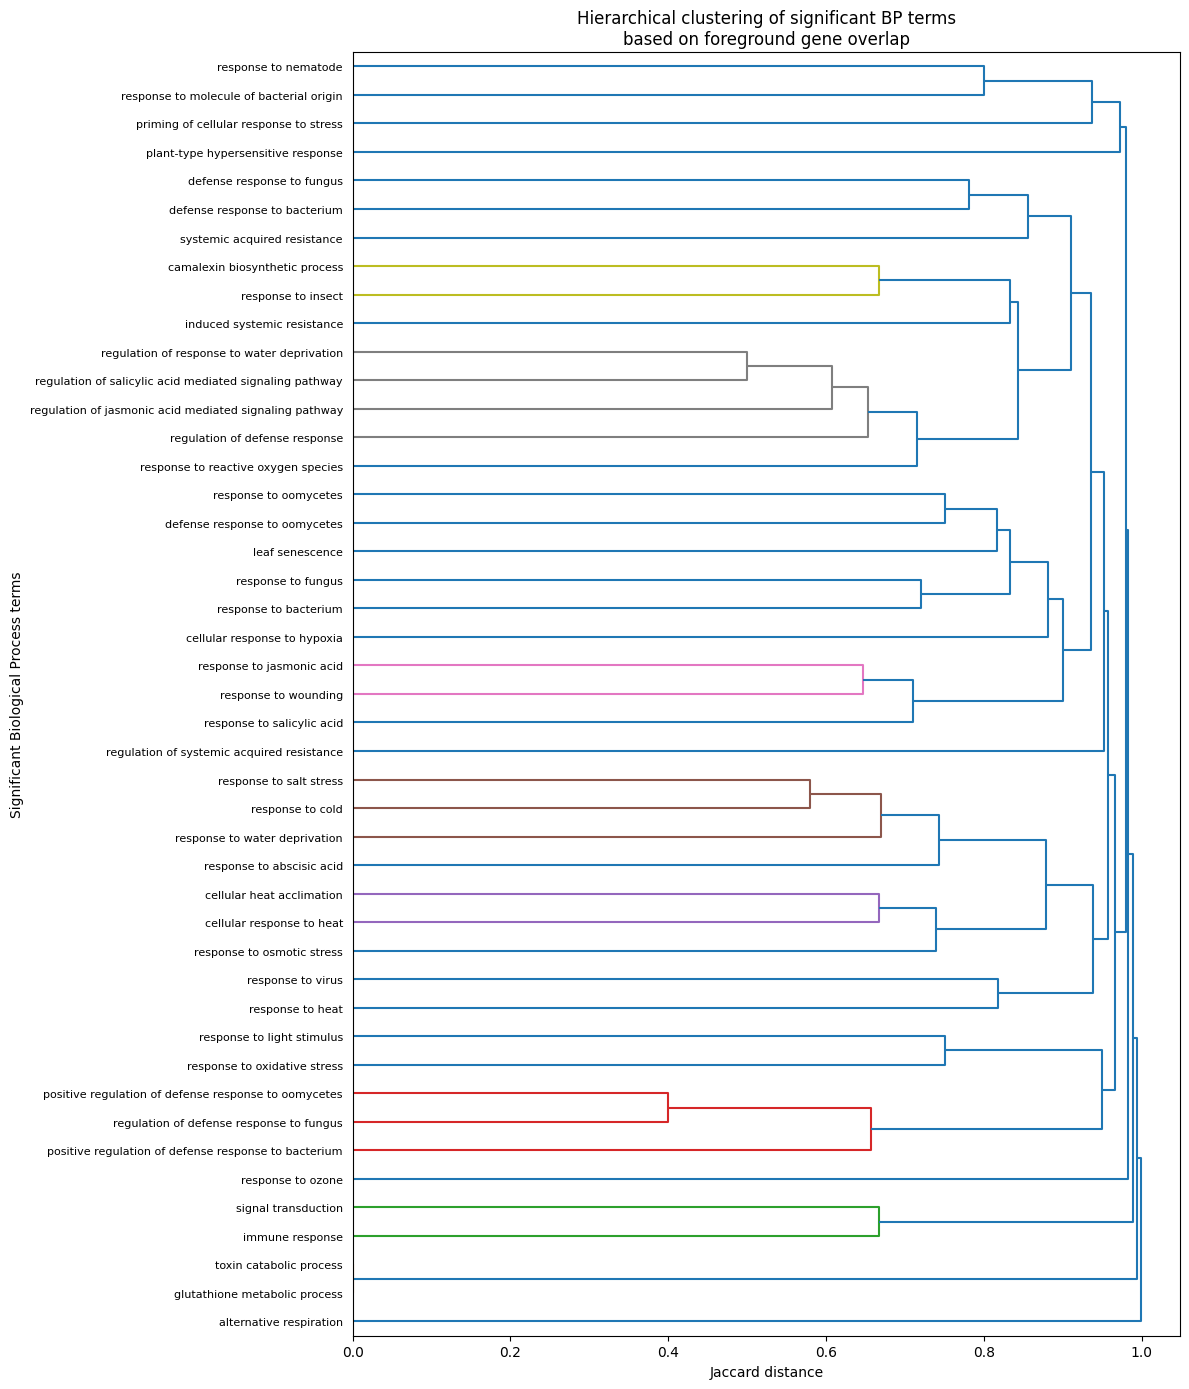

In [144]:
plt.figure(
    figsize=(12, 14)
)

dendrogram(
    bp_linkage,
    labels=term_labels,
    orientation="right",
    leaf_font_size=8
)

plt.xlabel(
    "Jaccard distance"
)

plt.ylabel(
    "Significant Biological Process terms"
)

plt.title(
    "Hierarchical clustering of significant BP terms\n"
    "based on foreground gene overlap"
)

plt.tight_layout()
plt.show()

### **Insight —** Hierarchical organization of significant Biological Process terms

##### Hierarchical clustering based on Jaccard distance revealed localized groups of significant GO terms supported by similar foreground gene sets, while many larger branches merged only at relatively high distances. This pattern is consistent with the pairwise-overlap analysis, which showed that most term pairs have little or no shared foreground membership.

#### Closely related terms formed local branches, including water-, osmotic-, and temperature-associated responses and several defense- and signaling-associated groups. Some terms were completely redundant at the foreground-gene level; for example, glutathione metabolic process and toxin catabolic process were supported by the same four genes and therefore merged at Jaccard distance 0.

#### Overall, the dendrogram organizes the enrichment results into multiple partially distinct functional themes containing smaller pockets of strong GO-term overlap and redundancy, rather than one homogeneous functional pattern.

### Inspecting Hierarchical Clustering Merge Distances

#### This block is examining the heights at which clusters were joined in the dendrogram.

#### That matters because the dendrogram visually suggested that some GO terms form tight local groups while larger groups only merge at relatively high Jaccard distances. Here, instead of relying only on the picture, we inspect those merge distances numerically.

#### The merge distances from the average-linkage clustering were examined to quantify the heights at which significant Biological Process terms and term clusters were joined. 

#### Because clustering was based on 1 - Jaccard similarity, lower merge distances represent greater similarity in foreground gene membership, while higher distances indicate weaker overlap.

#### The distribution and ordered sequence of merge distances provide a numerical complement to the dendrogram, showing whether clustering is characterized mainly by tight low-distance groups, high-distance mergers, or a mixture of both. 

#### Later merge heights represent distances between clusters under the average-linkage rule and therefore should not be interpreted as individual pairwise Jaccard distances

In [145]:
merge_distances = bp_linkage[:, 2]

pd.Series(
    merge_distances
).describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95
    ]
)

count    44.000000
mean      0.785078
std       0.189300
min       0.000000
25%       0.668899
50%       0.817058
75%       0.937744
90%       0.977847
95%       0.987596
max       0.998485
dtype: float64

In [146]:
np.sort(
    merge_distances
)

array([0.        , 0.4       , 0.5       , 0.57894737, 0.60714286,
       0.64705882, 0.65277778, 0.65714286, 0.66666667, 0.66666667,
       0.66666667, 0.66964286, 0.71037037, 0.71527778, 0.72      ,
       0.73888889, 0.74335863, 0.75      , 0.75      , 0.78125   ,
       0.8       , 0.81593407, 0.81818182, 0.83287363, 0.83333333,
       0.8426455 , 0.85606061, 0.87866845, 0.88101898, 0.90010377,
       0.91047096, 0.93585987, 0.9375    , 0.93847611, 0.9496633 ,
       0.95168766, 0.95706965, 0.96626895, 0.97222222, 0.98025714,
       0.98292661, 0.98841961, 0.99344207, 0.99848485])

### Identifying The Large Gaps in Hierarchical Clustering Merge Distances

#### The ordered merge distances were compared to identify large jumps between successive clustering steps. A large gap indicates that terms or clusters merged below the gap were joined at relatively similar gene-membership profiles, while the next merger required a substantially larger Jaccard distance.

#### These gaps can help identify plausible dendrogram cut heights for exploring broader functional groups. They are used as a guide rather than as a definitive rule, because the largest gap in a hierarchical tree does not by itself establish the biologically correct number of clusters.

In [147]:
sorted_merge_distances = np.sort(
    merge_distances
)

merge_distance_gaps = np.diff(
    sorted_merge_distances
)

gap_table = pd.DataFrame(
    {
        "lower_distance": sorted_merge_distances[:-1],
        "upper_distance": sorted_merge_distances[1:],
        "gap": merge_distance_gaps
    }
)

gap_table.sort_values(
    "gap",
    ascending=False
).head(10)

,lower_distance,upper_distance,gap
0,0.000000,0.400000,0.400000
1,0.400000,0.500000,0.100000
2,0.500000,0.578947,0.078947
11,0.669643,0.710370,0.040728
4,0.607143,0.647059,0.039916
18,0.750000,0.781250,0.031250
3,0.578947,0.607143,0.028195
30,0.910471,0.935860,0.025389
26,0.856061,0.878668,0.022608
28,0.881019,0.900104,0.019085


### **Insight —** Absence of a natural global dendrogram cut

#### Inspection of the 44 hierarchical-clustering merge distances did not reveal a clear global separation point for dividing the 45 significant Biological Process terms into well-defined clusters. 

#### The largest gap occurred between Jaccard distances 0 and 0.4, but this was driven by an exceptional pair of terms with identical foreground gene sets that merged at distance zero. Beyond this initial jump, the remaining merge-distance gaps were substantially smaller and distributed throughout the hierarchy.

#### Therefore, the dendrogram does not provide strong evidence for a single natural cut height that would divide the GO terms into a fixed set of discrete groups. Imposing such a cut would introduce an arbitrary clustering decision. 

#### Subsequent redundancy analysis therefore focuses on explicit strong pairwise gene overlap rather than forcing a global cluster structure onto the enrichment results.

### Identifying Strongly Overlapping Significant Biological Process Term

#### Because the dendrogram did not provide a clear global cut height, redundancy was examined directly using pairwise foreground-gene overlap. Term pairs with an overlap coefficient of at least 0.5 were treated as strongly overlapping, meaning that at least half of the smaller term's foreground gene set was contained within the other term.

#### Strong pairs were ranked using overlap coefficient, Jaccard similarity, and the number of shared genes. The number of unique GO terms participating in at least one strong-overlap pair was also calculated to determine how broadly these locally redundant relationships were distributed across the significant enrichment results.

In [148]:
strong_bp_overlap = (
    bp_term_overlap[
        bp_term_overlap[
            "overlap_coefficient"
        ] >= 0.5
    ]
    .copy()
    .sort_values(
        [
            "overlap_coefficient",
            "jaccard",
            "intersection"
        ],
        ascending=False
    )
)

In [149]:
strong_bp_overlap.shape

(88, 9)

In [150]:
strong_bp_overlap[
    [
        "go_term_a",
        "go_term_b",
        "genes_a",
        "genes_b",
        "intersection",
        "jaccard",
        "overlap_coefficient"
    ]
].head(30)

,go_term_a,go_term_b,genes_a,genes_b,intersection,jaccard,overlap_coefficient
174,glutathione metabolic process,toxin catabolic process,4,4,4,1.000000,1.000000
976,regulation of defense response to fungus,positive regulation of defense response to oom...,5,3,3,0.600000,1.000000
988,regulation of jasmonic acid mediated signaling...,regulation of response to water deprivation,6,3,3,0.500000,1.000000
770,induced systemic resistance,defense response to fungus,3,15,3,0.200000,1.000000
608,response to bacterium,positive regulation of defense response to oom...,22,3,3,0.136364,1.000000
817,response to salicylic acid,regulation of salicylic acid mediated signalin...,22,3,3,0.136364,1.000000
818,response to salicylic acid,regulation of response to water deprivation,22,3,3,0.136364,1.000000
943,defense response to bacterium,regulation of salicylic acid mediated signalin...,24,3,3,0.125000,1.000000
944,defense response to bacterium,regulation of response to water deprivation,24,3,3,0.125000,1.000000
212,immune response,signal transduction,6,14,5,0.333333,0.833333


In [151]:
len(
    set(strong_bp_overlap["go_id_a"])
    |
    set(strong_bp_overlap["go_id_b"])
)

39

### **Insight —** Strong-overlap structure among significant Biological Process terms

#### Applying an overlap-coefficient threshold of 0.5 identified 88 strongly overlapping pairs among the 990 possible comparisons between significant Biological Process terms. Thirty-nine of the 45 significant terms (86.7%) shared at least half of the smaller term’s foreground gene set with at least one other significant term, while six terms had no partner meeting this threshold.

#### This shows that gene sharing is common among the enriched GO terms, but it is concentrated within particular groups rather than spread evenly across all 45 terms. The six terms without a strong-overlap partner are relatively separate from the rest under this criterion.

#### The 0.5 threshold is simply a practical rule for defining substantial gene overlap; it is not a statistical significance threshold. For that reason, strongly connected GO terms should be treated as related or overlapping results, not automatically as the same biological pathway.

### Identifying Isolated and Highly Connected Significant Biological Process Terms

#### The strong-overlap relationships were used to examine how individual significant GO terms are positioned within the overlap structure. Terms that did not participate in any pair with an overlap coefficient of at least 0.5 were identified as isolated under this criterion.

#### For the remaining terms, the number of strong-overlap relationships was counted. This value represents how many other significant terms share at least half of the smaller term's foreground gene set with a given term. Terms with many such links occupy highly connected positions in the overlap structure, whereas terms with few links participate in more limited local overlap.

#### These link counts describe gene-set overlap, not biological importance or statistical significance.

In [152]:
strong_overlap_term_ids = (
    set(strong_bp_overlap["go_id_a"])
    |
    set(strong_bp_overlap["go_id_b"])
)

all_significant_bp_ids = set(
    significant_bp_enrichment["go_id"]
)

isolated_bp_ids = (
    all_significant_bp_ids
    - strong_overlap_term_ids
)

In [153]:
isolated_bp_terms = (
    significant_bp_enrichment[
        significant_bp_enrichment["go_id"].isin(
            isolated_bp_ids
        )
    ][
        [
            "go_id",
            "go_term",
            "foreground_with_term",
            "enrichment_ratio",
            "fdr_bh"
        ]
    ]
    .sort_values("fdr_bh")
)

isolated_bp_terms

,go_id,go_term,foreground_with_term,enrichment_ratio,fdr_bh
128,GO:0009627,systemic acquired resistance,13,28.875758,1.558718e-13
68,GO:0009624,response to nematode,6,8.523256,2.521927e-03
823,GO:0010230,alternative respiration,3,33.318182,2.648431e-03
783,GO:0080136,priming of cellular response to stress,3,30.541667,3.190918e-03
27,GO:0009408,response to heat,7,4.212644,3.223225e-02
25,GO:0009416,response to light stimulus,7,3.904871,4.678431e-02


In [154]:
term_degree = pd.concat(
    [
        strong_bp_overlap[
            ["go_id_a", "go_term_a"]
        ].rename(
            columns={
                "go_id_a": "go_id",
                "go_term_a": "go_term"
            }
        ),
        strong_bp_overlap[
            ["go_id_b", "go_term_b"]
        ].rename(
            columns={
                "go_id_b": "go_id",
                "go_term_b": "go_term"
            }
        )
    ],
    ignore_index=True
)

term_degree = (
    term_degree
    .groupby(
        ["go_id", "go_term"]
    )
    .size()
    .rename("n_strong_links")
    .reset_index()
    .sort_values(
        "n_strong_links",
        ascending=False
    )
)

term_degree.head(15)

,go_id,go_term,n_strong_links
14,GO:0009617,response to bacterium,13
29,GO:0042742,defense response to bacterium,12
21,GO:0009751,response to salicylic acid,11
38,GO:2000070,regulation of response to water deprivation,10
16,GO:0009625,response to insect,9
37,GO:2000031,regulation of salicylic acid mediated signalin...,9
1,GO:0002229,defense response to oomycetes,8
24,GO:0010120,camalexin biosynthetic process,6
27,GO:0031347,regulation of defense response,6
30,GO:0050832,defense response to fungus,6


### **Insight —** Highly connected and relatively separate GO terms

#### Among the 39 significant Biological Process terms that had at least one strong-overlap relationship, some terms were connected to many more terms than others. `Response to bacterium`, `defense response to bacterium`, `response to salicylic acid`, and `regulation of response to water deprivation` had the largest numbers of strong links, meaning that their foreground gene sets overlapped substantially with several other enriched GO terms.

#### These highly connected terms should not automatically be interpreted as the most biologically important processes. Their high number of links mainly shows that they share many genes with other significant categories and therefore contribute strongly to the overlap seen in the GO results.

#### Six significant terms — `systemic acquired resistance`, `response to nematode`, `alternative respiration`, `priming of cellular response to stress`, `response to heat`, and `response to light stimulus` — had no partner with an overlap coefficient of at least 0.5. These terms are therefore relatively separate from the main strong-overlap groups under the chosen threshold, although they may still share some genes with other enriched processes.

### Building the Strong-Overlap Network of Significant Biological Process Terms

#### The strong pairwise overlap relationships were combined into a network to examine how the significant GO terms are connected as a whole. 

#### Each significant Biological Process term was represented as a node, and an edge was added between two terms when their foreground gene sets had an overlap coefficient of at least 0.5.

#### All 45 significant terms were included as nodes so that terms without any strong-overlap partner remained visible as isolated nodes. The resulting network was then separated into connected components. A connected component contains terms that can be reached from one another through one or more strong-overlap relationships, although not every pair of terms within a component must directly overlap.

#### This provides a way to identify larger groups of related GO terms without forcing a fixed number of clusters from the dendrogram.

In [155]:
import networkx as nx

G = nx.Graph()

In [156]:
for _, row in significant_bp_enrichment.iterrows():                           # adding the strong overlap relationships

    G.add_node(
        row["go_id"],
        go_term=row["go_term"]
    )

In [157]:
for _, row in strong_bp_overlap.iterrows():

    G.add_edge(
        row["go_id_a"],
        row["go_id_b"],
        overlap_coefficient=row["overlap_coefficient"],
        jaccard=row["jaccard"],
        intersection=row["intersection"]
    )

In [158]:
G.number_of_nodes(), G.number_of_edges()

(45, 88)

In [159]:
components = sorted(
    nx.connected_components(G),
    key=len,
    reverse=True
)

component_sizes = [
    len(component)
    for component in components
]

component_sizes

[35, 2, 2, 1, 1, 1, 1, 1, 1]

> ### **Note -** Why connected components were used
>
>#### The dendrogram did not show a clear point where all 45 significant GO terms could be divided into a fixed number of meaningful clusters. Instead of choosing an arbitrary cut, the analysis used the strong-overlap relationships that had already been defined using an overlap coefficient of at least 0.5.
>
>#### A network was built in which each GO term was represented as a node and each strong-overlap relationship as an edge. Connected components were then used to identify groups of terms that were linked to one another through these strong relationships. This allowed the overall overlap structure to be examined without forcing the terms into a predetermined number of clusters.
>
>#### A connected component does not mean that every term in the group directly overlaps with every other term. It only means that the terms are connected through one or more strong-overlap relationships.

In [160]:
len(components)

9

### **Insight —** Connected structure of the strong-overlap network

#### The network contained 45 significant Biological Process terms connected by 88 strong-overlap relationships, forming nine connected components. One large component contained 35 terms, two smaller components contained two terms each, and the remaining six terms were isolated.

#### This means that 35 of the 39 terms with at least one strong-overlap partner were connected within the same larger network. However, terms can belong to the same component through a chain of connections, so this does not mean that every pair of terms in the 35-term component strongly overlaps.

#### Overall, the result shows that most of the overlapping GO terms belong to one large connected structure, while two small term pairs remain separate from it and six significant terms have no strong-overlap partner. This suggests substantial sharing of foreground genes across many enriched processes, while some processes remain more separate under the chosen overlap threshold.

### Inspecting the GO Terms Within Each Connected Component

#### After identifying the connected components of the strong-overlap network, the enrichment and network information for each GO term were combined into a single table. 

#### For every significant Biological Process term, the table records its component membership, component size, number of strong-overlap partners, foreground gene count, enrichment ratio, and BH-adjusted FDR.

#### This allows the biological content of each component to be examined directly. Particular attention was given to the two small two-term components and the large 35-term component. The number of strong links is used only to describe how connected a term is within the overlap network and is not treated as a measure of biological importance.

In [161]:
component_records = []

for component_id, component in enumerate(
    components,
    start=1
):

    for go_id in component:

        term_row = (
            significant_bp_enrichment[
                significant_bp_enrichment["go_id"] == go_id
            ]
            .iloc[0]
        )

        component_records.append(
            {
                "component_id": component_id,
                "component_size": len(component),
                "go_id": go_id,
                "go_term": term_row["go_term"],
                "n_strong_links": G.degree(go_id),
                "foreground_with_term": term_row[
                    "foreground_with_term"
                ],
                "enrichment_ratio": term_row[
                    "enrichment_ratio"
                ],
                "fdr_bh": term_row["fdr_bh"],
            }
        )

component_table = pd.DataFrame(
    component_records
)

component_table = (
    component_table
    .sort_values(
        [
            "component_id",
            "n_strong_links",
            "fdr_bh"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
)

In [162]:
component_table.groupby(
    "component_id"
).agg(
    component_size=("component_size", "first"),
    n_terms=("go_id", "count"),
    max_degree=("n_strong_links", "max")
)

,component_size,n_terms,max_degree
component_id,,,
1,35,35,13
2,2,2,1
3,2,2,1
4,1,1,0
5,1,1,0
6,1,1,0
7,1,1,0
8,1,1,0
9,1,1,0


In [163]:
component_table[
    component_table["component_size"] == 2
][
    [
        "component_id",
        "go_term",
        "n_strong_links",
        "enrichment_ratio",
        "fdr_bh"
    ]
]

,component_id,go_term,n_strong_links,enrichment_ratio,fdr_bh
35,2,immune response,1,17.452381,0.000071
36,2,signal transduction,1,2.850556,0.011603
38,3,toxin catabolic process,1,10.623188,0.013333
37,3,glutathione metabolic process,1,10.397163,0.013771


In [164]:
component_table[
    component_table["component_size"] == 35
][
    [
        "go_term",
        "n_strong_links",
        "foreground_with_term",
        "enrichment_ratio",
        "fdr_bh"
    ]
]

,go_term,n_strong_links,foreground_with_term,enrichment_ratio,fdr_bh
20,response to bacterium,13,22,18.794872,2.545761e-19
0,defense response to bacterium,12,24,8.282486,3.994272e-13
8,response to salicylic acid,11,22,20.361111,8.118430e-20
9,regulation of response to water deprivation,10,3,19.289474,1.235155e-02
18,response to insect,9,4,10.859259,1.259477e-02
7,regulation of salicylic acid mediated signalin...,9,3,15.270833,2.198266e-02
15,defense response to oomycetes,8,6,9.644737,1.463459e-03
6,response to water deprivation,6,21,7.048077,3.388722e-10
5,defense response to fungus,6,15,7.699580,1.390026e-07
2,camalexin biosynthetic process,6,4,37.589744,1.523649e-04


### **Insight —** Composition of the strong-overlap network

#### The strong-overlap network contained one large component of 35 significant Biological Process terms, two separate two-term components, and six isolated terms.

#### The large component included terms related to defense, hormone responses, abiotic stress, redox processes, and other stress-related responses. Some of the most highly connected terms were `response to bacterium`, `defense response to bacterium`, `response to salicylic acid`, and `regulation of response to water deprivation`. This shows that several different areas of the enrichment result are linked through substantial sharing of foreground genes. However, belonging to the same component does not mean that all 35 terms directly overlap or represent one biological pathway.

#### The two smaller components showed more localized overlap. `Immune response` and `signal transduction` formed one pair, with much of the smaller immune-response gene set also present in signal transduction. `Glutathione metabolic process` and `toxin catabolic process` formed the second pair and were supported by the same foreground genes.

#### The remaining six significant terms had no strong-overlap partner at the 0.5 overlap-coefficient threshold, making them relatively separate from the other enriched terms under this definition.

### Visualizing the Largest Strong-Overlap Component

#### The largest connected component was extracted from the strong-overlap network and visualized separately to examine its internal pattern of connections. Node size was scaled by the number of strong-overlap partners, so larger nodes represent GO terms connected to more terms within this component. Each edge represents a pair with an overlap coefficient of at least 0.5.

#### A spring layout was used only to arrange the nodes for visualization. The exact position or distance between nodes in the figure should therefore not be interpreted as a biological measurement. The biologically relevant information is the presence of strong-overlap connections and the number of such connections associated with each term.

In [165]:
largest_component = components[0]

G_largest = G.subgraph(
    largest_component
).copy()

G_largest.number_of_nodes(), G_largest.number_of_edges()

(35, 86)

In [166]:
pos = nx.spring_layout(
    G_largest,
    seed=42,
    k=0.9
)

> ### **Note -** spring_layout
>
> #### spring_layout treats connected nodes somewhat like springs
>
> #### - strongly interconnected regions tend to sit closer together
>
> #### - sparsely connected terms tend to sit farther apart.

In [167]:
largest_degree = dict(
    G_largest.degree()
)

In [168]:
node_sizes = [
    300 + largest_degree[node] * 120
    for node in G_largest.nodes()
]

In [169]:
node_labels = {
    node: G_largest.nodes[node]["go_term"]
    for node in G_largest.nodes()
}

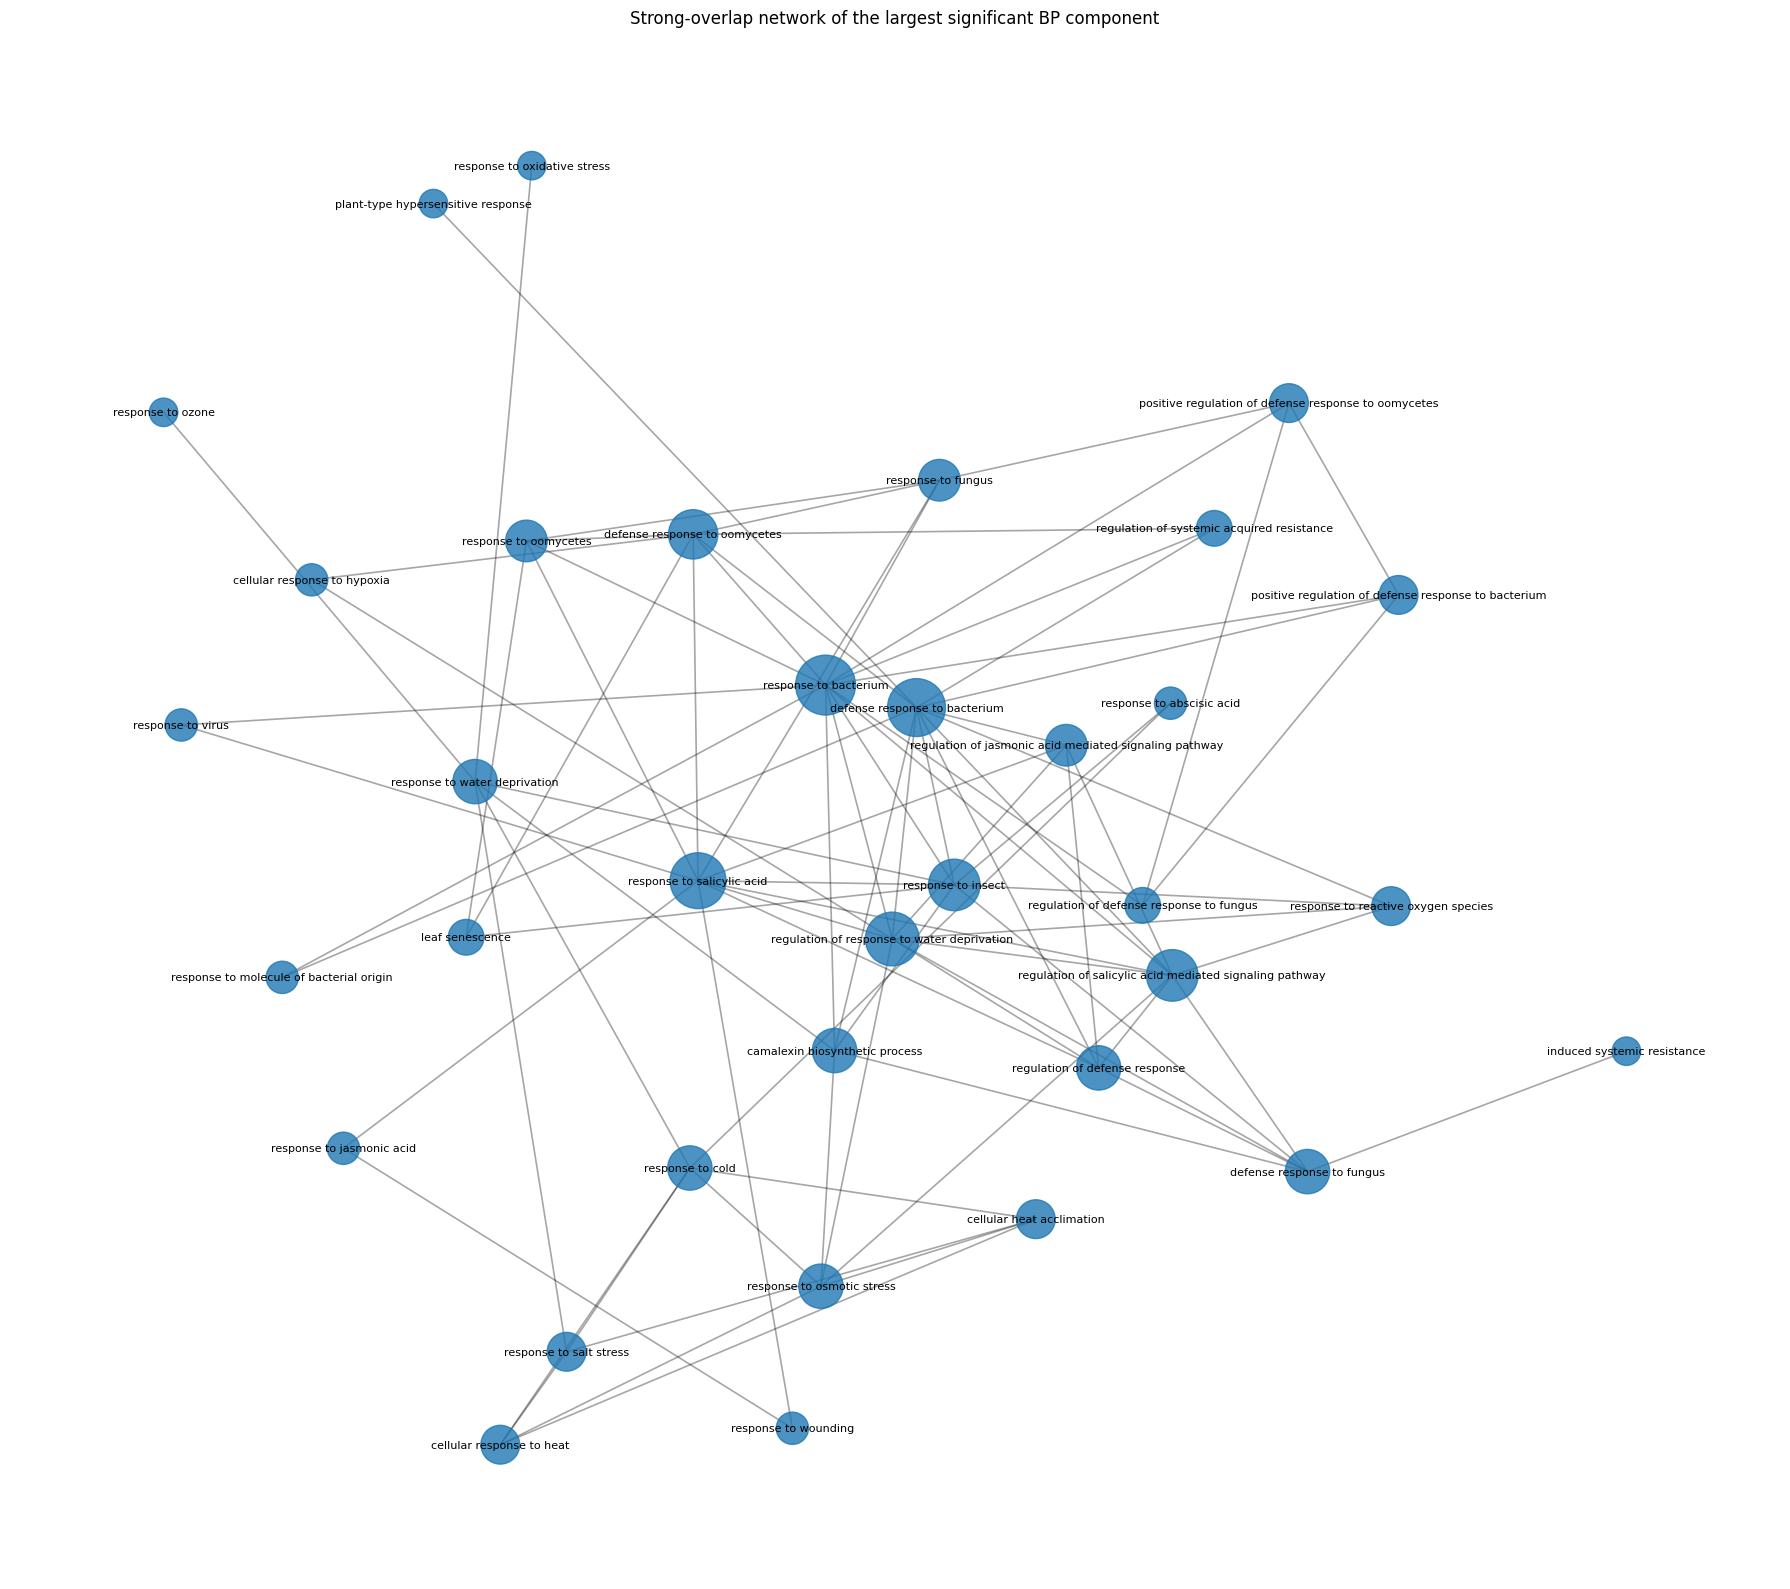

In [170]:
plt.figure(
    figsize=(18, 16)
)

nx.draw_networkx_nodes(
    G_largest,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_largest,
    pos,
    alpha=0.35,
    width=1.2
)

nx.draw_networkx_labels(
    G_largest,
    pos,
    labels=node_labels,
    font_size=8
)

plt.title(
    "Strong-overlap network of the largest significant BP component"
)

plt.axis("off")

plt.tight_layout()

plt.show()

### **Insight —** Largest strong-overlap component

#### The largest connected component contained 35 significant Biological Process terms linked by 86 strong-overlap relationships. Terms such as `response to bacterium`, `defense response to bacterium`, `response to salicylic acid`, and `regulation of response to water deprivation` had many strong connections with other terms in the component.

#### The network shows that many of the significant GO terms are connected through shared foreground genes rather than representing completely separate results. Some terms have many strong-overlap partners, while others are connected through only a few relationships.

#### The exact position of a term in the figure comes from the spring layout and does not have a direct biological meaning. The interpretation therefore comes from which terms are connected and how many strong-overlap relationships they have, rather than how close together they appear in the plot.

### Identifying Communities Within the Largest Strong-Overlap Component

#### The largest connected component contained 35 GO terms, but membership in one connected component does not mean that all terms are equally strongly related. 

#### Community detection was therefore used to examine whether smaller groups of terms had stronger overlap relationships within the group than with the rest of the component.

#### Greedy modularity community detection was applied using the overlap coefficient as the edge weight, allowing stronger gene-overlap relationships to contribute more to the grouping. The resulting communities represent groups defined by the structure of the overlap network and are not assumed to correspond directly to individual biological pathways.

#### Modularity was then calculated to measure how well the detected groups capture the internal connection pattern of the network. It is a network structure score rather than a statistical significance test.

> ### **Note -** Greedy modularity community detection
>
> #### The analysis used greedy modularity community detection. The method begins with the network divided into very small groups and repeatedly joins the pair of groups that produces the greatest improvement in modularity. It continues this process until further merging no longer improves the modularity score. The method is called greedy because at each step it chooses the merge that gives the best immediate improvement rather than testing every possible way of dividing the network.
>
> #### Modularity measures how well a proposed division separates the network into groups with stronger connections inside the groups than would be expected from the overall connection pattern of the network. A higher positive modularity value generally means that the network has a clearer community structure, although there is no single value that automatically proves that the communities are biologically meaningful.

In [171]:
from networkx.algorithms.community import (                     # importing the community detection functions
    greedy_modularity_communities,                              # this will find the communities
    modularity                                                  # this will help us measure how strongly the network supports that division
)

bp_communities = list(
    greedy_modularity_communities(
        G_largest,
        weight="overlap_coefficient"
    )
)

In [172]:
len(bp_communities)

4

In [173]:
[
    len(community)
    for community in bp_communities
]

[11, 11, 9, 4]

In [174]:
bp_modularity = modularity(
    G_largest,
    bp_communities,
    weight="overlap_coefficient"
)

bp_modularity

0.4262700145857794

### Insight — Communities within the largest overlap network

#### The 35-term connected component was divided into four communities containing 11, 11, 9, and 4 GO terms. The weighted modularity was 0.426, showing that strong-overlap relationships tended to occur more within these groups than between them.

#### The algorithm identified these four communities from the pattern and strength of the overlap relationships; the number of groups was not chosen in advance.

#### These communities should therefore be treated as groups of GO terms that share stronger gene-overlap relationships with one another. They should not automatically be considered separate biological pathways. The biological meaning of each community needs to be determined by examining the GO terms and genes it contains.

### Inspecting the GO Terms Within Each Detected Community

#### The four communities identified within the largest connected component were examined by combining community membership with the existing enrichment and network results for each GO term. For every term, the table includes its number of strong-overlap partners, foreground gene count, enrichment ratio, and BH-adjusted FDR.

#### The terms within each community were then displayed separately to determine whether the network-defined groups correspond to recognizable biological themes. Community labels were not assigned in advance; their biological interpretation is based on the GO terms contained within each group.

In [175]:
community_records = []

for community_id, community in enumerate(
    bp_communities,
    start=1
):

    for go_id in community:

        term_row = (
            significant_bp_enrichment[
                significant_bp_enrichment["go_id"] == go_id
            ]
            .iloc[0]
        )

        community_records.append(
            {
                "community_id": community_id,
                "community_size": len(community),
                "go_id": go_id,
                "go_term": term_row["go_term"],
                "n_strong_links": G_largest.degree(go_id),
                "foreground_with_term": term_row[
                    "foreground_with_term"
                ],
                "enrichment_ratio": term_row[
                    "enrichment_ratio"
                ],
                "fdr_bh": term_row["fdr_bh"],
            }
        )

community_table = pd.DataFrame(
    community_records
)

community_table = (
    community_table
    .sort_values(
        [
            "community_id",
            "n_strong_links",
            "fdr_bh"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
)

In [176]:
for community_id in sorted(
    community_table["community_id"].unique()
):

    print(
        f"\nCOMMUNITY {community_id}"
    )

    display(
        community_table[
            community_table[
                "community_id"
            ] == community_id
        ][
            [
                "go_term",
                "n_strong_links",
                "foreground_with_term",
                "enrichment_ratio",
                "fdr_bh",
            ]
        ]
    )


COMMUNITY 1


,go_term,n_strong_links,foreground_with_term,enrichment_ratio,fdr_bh
9,response to bacterium,13,22,18.794872,2.545761e-19
3,defense response to oomycetes,8,6,9.644737,1.463459e-03
1,response to fungus,5,10,11.311728,1.709231e-06
7,response to oomycetes,5,4,20.361111,1.519630e-03
2,positive regulation of defense response to bac...,4,4,16.288889,3.041932e-03
6,positive regulation of defense response to oom...,4,3,30.541667,3.190918e-03
0,leaf senescence,3,11,10.665344,7.477460e-07
5,regulation of systemic acquired resistance,3,4,32.577778,2.584609e-04
8,regulation of defense response to fungus,3,5,16.967593,4.747470e-04
4,response to molecule of bacterial origin,2,6,18.325000,6.049242e-05



COMMUNITY 2


,go_term,n_strong_links,foreground_with_term,enrichment_ratio,fdr_bh
11,defense response to bacterium,12,24,8.282486,3.994272e-13
16,response to salicylic acid,11,22,20.361111,8.118430e-20
18,regulation of response to water deprivation,10,3,19.289474,1.235155e-02
12,regulation of salicylic acid mediated signalin...,9,3,15.270833,2.198266e-02
19,regulation of defense response,6,5,11.746795,2.290381e-03
17,regulation of jasmonic acid mediated signaling...,5,6,17.452381,7.068682e-05
15,response to reactive oxygen species,4,5,16.509009,5.205228e-04
21,cellular response to hypoxia,2,18,9.239496,2.092865e-10
13,response to jasmonic acid,2,11,10.337179,9.359460e-07
14,response to wounding,2,12,6.515556,2.759801e-05



COMMUNITY 3


,go_term,n_strong_links,foreground_with_term,enrichment_ratio,fdr_bh
23,response to water deprivation,6,21,7.048077,3.388722e-10
28,response to cold,6,12,4.212644,1.263186e-03
27,response to osmotic stress,6,8,6.070393,1.997950e-03
22,response to salt stress,4,15,4.469512,8.227737e-05
29,cellular heat acclimation,4,3,33.318182,2.648431e-03
24,cellular response to heat,4,5,8.254505,9.753737e-03
26,response to abscisic acid,2,23,6.385985,2.549682e-10
25,response to ozone,1,3,11.453125,4.678431e-02
30,response to oxidative stress,1,8,3.502987,4.678431e-02



COMMUNITY 4


,go_term,n_strong_links,foreground_with_term,enrichment_ratio,fdr_bh
33,response to insect,9,4,10.859259,1.259477e-02
31,defense response to fungus,6,15,7.699580,1.390026e-07
32,camalexin biosynthetic process,6,4,37.589744,1.523649e-04
34,induced systemic resistance,1,3,18.325000,1.333304e-02


### **Observations —** Biological composition of the four communities

#### Community 1 contains terms related mainly to pathogen and defense responses, including response to bacterium, responses to fungi and oomycetes, response to molecule of bacterial origin, response to virus, and regulation of systemic acquired resistance. Leaf senescence is also included in this community.

#### Community 2 contains a mixture of defense, hormone, redox, and damage-response terms. These include responses to salicylic acid and jasmonic acid, regulation of defense responses, reactive oxygen species, hypoxia, wounding, hypersensitive response, and regulation of response to water deprivation.

#### Community 3 is composed mainly of abiotic-stress-related terms, including response to water deprivation, response to cold, osmotic and salt stress, heat acclimation, heat response, abscisic acid response, oxidative stress, and ozone response.

#### Community 4 contains four terms related to more specific defense responses: camalexin biosynthetic process, induced systemic resistance, insect response, and fungal defense.

### **Insight —** What the community structure adds to the biological story

#### The communities show that the persistent high-breadth genes are associated with several related stress-response systems rather than one single type of response. One part of the network is strongly connected to pathogen and defense biology, another combines defense with hormone, redox, and damage responses, while a separate group is centered more clearly on abiotic stress.

#### This is important because it suggests that the genes showing persistent expression across multiple abiotic stresses are linked to a broader plant stress-response system in which abiotic stress, defense signaling, hormones, and redox responses share some of the same genes.

#### The network therefore helps explain why many different GO terms were enriched: some of them are different biological descriptions of overlapping stress-response genes rather than completely separate pathways.

### Examining Strong-Overlap Connections Within and Between Communities

#### Each strong-overlap edge in the 35-term network was classified according to whether the two connected GO terms belonged to the same detected community or to different communities. This provides a direct view of how much of the network connectivity occurs within the four communities and how much connects them to one another.

#### Connections between different communities were also counted by community pair. Because the network is undirected, community-pair labels should be ordered consistently so that, for example, a Community 1–2 edge and a Community 2–1 edge are treated as the same type of connection.

In [177]:
community_map = {}

for community_id, community in enumerate(
    bp_communities,
    start=1
):
    for go_id in community:
        community_map[go_id] = community_id

In [178]:
community_edges = []

for node_a, node_b, data in G_largest.edges(
    data=True
):

    community_a = community_map[node_a]
    community_b = community_map[node_b]

    community_edges.append(
        {
            "go_id_a": node_a,
            "go_id_b": node_b,
            "community_a": community_a,
            "community_b": community_b,
            "same_community": (
                community_a == community_b
            ),
            "overlap_coefficient": data[
                "overlap_coefficient"
            ],
            "jaccard": data["jaccard"],
        }
    )

community_edge_table = pd.DataFrame(
    community_edges
)

In [179]:
community_edge_table[
    "same_community"
].value_counts()

same_community
True     59
False    27
Name: count, dtype: int64

In [180]:
community_edge_table.groupby(
    ["community_a", "community_b"]
).size()

community_a  community_b
1            1              19
             2               2
             4               3
2            1               9
             2              22
             4               4
3            2               2
             3              14
             4               3
4            2               3
             3               1
             4               4
dtype: int64

### **Insight** — Connections within and between communities

#### Of the 86 strong-overlap edges in the 35-term component, 59 (68.6%) connected GO terms within the same community, while 27 (31.4%) connected terms from different communities.

#### This shows that the four communities contain more strong-overlap relationships within themselves, but they are still connected to one another. The strongest connection between different communities occurred between Communities 1 and 2, showing substantial gene sharing between pathogen/defense-related terms and terms associated with hormones, defense regulation, redox stress, and damage responses.

#### There was no direct strong-overlap edge between Communities 1 and 3, although both remained connected through other communities in the larger network.

#### Because the communities contain different numbers of GO terms, simply comparing edge counts can be misleading. The next step therefore compares edge density, which takes community size into account.

### Comparing Edge Density Within and Between Communities

#### The previous edge counts showed that more strong-overlap relationships occurred within communities than between them. However, the four communities contain different numbers of GO terms, giving larger communities more possible term pairs and therefore more opportunities to form edges.

#### Edge density was therefore calculated to account for community size. Internal density measures the proportion of all possible term pairs within a community that are connected by a strong-overlap edge. Between-community density similarly measures the proportion of all possible pairs between two communities that are strongly connected.

#### These densities describe how common strong-overlap relationships are within and between the detected communities. They are descriptive measures of the thresholded network and do not represent statistical significance.

In [181]:
community_density_records = []

for community_id, community in enumerate(
    bp_communities,
    start=1
):

    subgraph = G_largest.subgraph(
        community
    )

    community_density_records.append(
        {
            "community_id": community_id,
            "n_terms": len(community),
            "internal_edges": subgraph.number_of_edges(),
            "density": nx.density(subgraph),
        }
    )

community_density = pd.DataFrame(
    community_density_records
)

community_density

,community_id,n_terms,internal_edges,density
0,1,11,19,0.345455
1,2,11,22,0.400000
2,3,9,14,0.388889
3,4,4,4,0.666667


In [182]:
between_community_records = []

for i in range(1, 5):

    for j in range(i + 1, 5):

        nodes_i = set(
            community_table[
                community_table["community_id"] == i
            ]["go_id"]
        )

        nodes_j = set(
            community_table[
                community_table["community_id"] == j
            ]["go_id"]
        )

        edge_count = sum(
            1
            for u, v in G_largest.edges()
            if (
                (u in nodes_i and v in nodes_j)
                or
                (u in nodes_j and v in nodes_i)
            )
        )

        possible_edges = (
            len(nodes_i) * len(nodes_j)
        )

        between_community_records.append(
            {
                "community_a": i,
                "community_b": j,
                "observed_edges": edge_count,
                "possible_edges": possible_edges,
                "edge_density": (
                    edge_count / possible_edges
                ),
            }
        )

between_community_density = pd.DataFrame(
    between_community_records
)

between_community_density

,community_a,community_b,observed_edges,possible_edges,edge_density
0,1,2,11,121,0.090909
1,1,3,0,99,0.000000
2,1,4,3,44,0.068182
3,2,3,2,99,0.020202
4,2,4,7,44,0.159091
5,3,4,4,36,0.111111


### **Insight —** Connectivity within and between communities

#### The four communities were much more strongly connected within themselves than they were to other communities. Their internal edge densities were 0.345, 0.400, 0.389, and 0.667, while the densities between different communities ranged from 0 to 0.159.

#### Even the community with the lowest internal density was therefore more than twice as densely connected as the strongest pair of different communities. Community 4 was especially tightly connected, with four of its six possible internal term pairs linked by strong gene overlap.

#### There was no direct strong-overlap connection between Communities 1 and 3, although both were still connected indirectly through the larger network.

#### Together with the positive modularity score, these results show that the four communities are not just arbitrary divisions of the network. The GO terms within each community share strong-overlap relationships more often than terms from different communities. However, these groups are still based on patterns of gene overlap and should not automatically be treated as separate biological pathways.

### Testing the Sensitivity of the GO-Term Network to the Overlap Threshold

#### The main network analysis defined strong GO-term overlap using an overlap coefficient of at least 0.5. Because this cutoff is a practical analysis choice rather than a biological boundary, the network was rebuilt using thresholds of 0.4, 0.5, and 0.6.

#### All 45 significant Biological Process terms were retained at every threshold, including terms that had no qualifying edges. For each network, the number of edges, connected components, size of the largest component, number of isolated terms, and full distribution of component sizes were compared.

#### This analysis tests whether the main network pattern depends strongly on the exact 0.5 cutoff. Similar overall structure across nearby thresholds would support the stability of the main result, while large changes would indicate that the network is sensitive to the chosen definition of strong overlap.

#### We are not using this analysis to search for a better threshold. We are checking whether the conclusions drawn from our chosen 0.5 threshold remain reasonable when that choice is varied.

In [183]:
overlap_thresholds = [
    0.40,
    0.50,
    0.60
]

threshold_graphs = {}
threshold_summary_records = []

significant_nodes = (
    significant_bp_enrichment[
        ["go_id", "go_term"]
    ]
    .drop_duplicates()
)

In [184]:
for threshold in overlap_thresholds:

    G_threshold = nx.Graph()

    for _, row in significant_nodes.iterrows():                   # keeping all 45 GO terms even if some become isolated

        G_threshold.add_node(
            row["go_id"],
            go_term=row["go_term"]
        )

    threshold_edges = (
        bp_term_overlap[
            bp_term_overlap[
                "overlap_coefficient"
            ] >= threshold
        ]
    )

    for _, row in threshold_edges.iterrows():

        G_threshold.add_edge(
            row["go_id_a"],
            row["go_id_b"],
            overlap_coefficient=row[
                "overlap_coefficient"
            ],
            jaccard=row["jaccard"],
            intersection=row["intersection"]
        )

    threshold_graphs[threshold] = G_threshold

    components_threshold = sorted(
        nx.connected_components(
            G_threshold
        ),
        key=len,
        reverse=True
    )

    threshold_summary_records.append(
        {
            "overlap_threshold": threshold,
            "n_nodes": G_threshold.number_of_nodes(),
            "n_edges": G_threshold.number_of_edges(),
            "n_components": len(
                components_threshold
            ),
            "largest_component_size": len(
                components_threshold[0]
            ),
            "n_isolated_terms": len(
                list(
                    nx.isolates(
                        G_threshold
                    )
                )
            ),
        }
    )

In [185]:
threshold_summary = pd.DataFrame(
    threshold_summary_records
)

threshold_summary

,overlap_threshold,n_nodes,n_edges,n_components,largest_component_size,n_isolated_terms
0,0.4,45,115,7,37,4
1,0.5,45,88,9,35,6
2,0.6,45,51,18,26,15


In [186]:
for threshold in overlap_thresholds:

    G_threshold = threshold_graphs[
        threshold
    ]

    components_threshold = sorted(
        nx.connected_components(
            G_threshold
        ),
        key=len,
        reverse=True
    )

    print(
        f"\nThreshold = {threshold}"
    )

    print(
        "Component sizes:",
        [
            len(component)
            for component
            in components_threshold
        ]
    )


Threshold = 0.4
Component sizes: [37, 2, 2, 1, 1, 1, 1]

Threshold = 0.5
Component sizes: [35, 2, 2, 1, 1, 1, 1, 1, 1]

Threshold = 0.6
Component sizes: [26, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### **Insight —** Sensitivity of the overlap network to the chosen threshold

#### The overall network pattern was compared using overlap-coefficient thresholds of 0.40, 0.50, and 0.60.

#### At the more permissive 0.40 threshold, the network contained 115 edges, and the largest connected component included 37 of the 45 significant GO terms. At the main 0.50 threshold, the network contained 88 edges, with 35 terms still belonging to the largest component. This shows that the large connected group remained mostly intact after weaker overlap relationships were removed.

#### At the stricter 0.60 threshold, the network became more fragmented, with 51 edges, a largest component of 26 terms, and 15 isolated terms compared with six at the 0.50 threshold.

#### Overall, the presence of a large connected group was maintained across nearby threshold choices, although stricter filtering removed many weaker connections and separated more terms from the main network. The 0.50 threshold is therefore kept as a practical and interpretable definition of strong overlap, rather than being treated as a uniquely correct biological cutoff.

### Comparing Membership of the Largest Component Across Overlap Thresholds

#### The previous sensitivity analysis compared the size of the largest connected component at overlap thresholds of 0.40, 0.50, and 0.60. However, similar component sizes do not necessarily mean that the same GO terms remain connected.

#### The GO-term membership of the largest component was therefore compared between thresholds. For each pair of thresholds, the number of shared terms and the Jaccard similarity between the two component memberships were calculated. A high Jaccard value indicates that the largest connected group contains largely the same GO terms despite the change in overlap threshold.

#### This provides a more direct test of whether the main connected group is stable across reasonable changes to the strong-overlap definition, rather than relying only on component size.

In [187]:
largest_components_by_threshold = {}

for threshold in overlap_thresholds:

    G_threshold = threshold_graphs[
        threshold
    ]

    components_threshold = sorted(
        nx.connected_components(
            G_threshold
        ),
        key=len,
        reverse=True
    )

    largest_components_by_threshold[
        threshold
    ] = set(
        components_threshold[0]
    )

In [188]:
for threshold_a, threshold_b in [
    (0.40, 0.50),
    (0.50, 0.60),
    (0.40, 0.60),
]:

    set_a = largest_components_by_threshold[
        threshold_a
    ]

    set_b = largest_components_by_threshold[
        threshold_b
    ]

    intersection = len(
        set_a & set_b
    )

    union = len(
        set_a | set_b
    )

    print(
        f"{threshold_a} vs {threshold_b}"
    )

    print(
        "Shared terms:",
        intersection
    )

    print(
        "Jaccard:",
        intersection / union
    )

    print()

0.4 vs 0.5
Shared terms: 35
Jaccard: 0.9459459459459459

0.5 vs 0.6
Shared terms: 26
Jaccard: 0.7428571428571429

0.4 vs 0.6
Shared terms: 26
Jaccard: 0.7027027027027027



In [189]:
len(
    largest_components_by_threshold[0.60]
    &
    largest_components_by_threshold[0.50]
)

26

### **Insight —** Stability of the largest component across overlap thresholds

#### The largest connected component remained largely made up of the same GO terms as the overlap threshold became stricter.

#### At the 0.40 threshold, the largest component contained 37 terms, and all 35 terms from the main 0.50 component were included within it. Their Jaccard similarity was 0.946, showing very little change in membership.

#### At the stricter 0.60 threshold, the largest component decreased to 26 terms, and all 26 were still part of the 35-term component found at 0.50. The Jaccard similarity between these two components was 0.743.

#### This shows that increasing the overlap requirement mainly removes terms from the existing large group rather than replacing them with a different set of GO terms. The main connected group is therefore reasonably stable across the tested thresholds, although it becomes smaller as the definition of strong overlap becomes stricter.

### Testing the Stability of Community Structure Across Overlap Thresholds

#### Community detection was repeated within the largest connected component at overlap-coefficient thresholds of 0.40, 0.50, and 0.60. This tests whether the smaller groups identified within the main network depend strongly on the exact threshold used to define an overlap edge.

#### For each threshold, weighted greedy-modularity community detection was applied using the overlap coefficient as the edge weight. The size of the largest component, number of edges, number and sizes of detected communities, and weighted modularity were recorded.

#### These comparisons describe how the community structure changes as the overlap definition becomes more or less strict. Similar community counts and sizes would suggest broad structural stability, but the actual GO-term membership of the communities must also be compared before concluding that the same biological groups are preserved across thresholds.

In [190]:
threshold_community_summary = []                                 # stores the summary information

threshold_communities = {}                                       # stores the actual GO-term sets assigned to the communities

for threshold in overlap_thresholds:

    G_threshold = threshold_graphs[                              # retrieving the full network at the particular threshold
        threshold
    ]

    largest_nodes = (                                            # retrieving the largest component membership
        largest_components_by_threshold[
            threshold
        ]
    )

    G_threshold_largest = (                                      # extracting only the largest component
        G_threshold.subgraph(
            largest_nodes
        ).copy()
    )

    communities_threshold = list(                                # running the greedy modularity
        greedy_modularity_communities(
            G_threshold_largest,
            weight="overlap_coefficient"
        )
    )

    threshold_communities[                                       # storing the actual communities
        threshold
    ] = communities_threshold

    modularity_threshold = modularity(                           # calculating modularity
        G_threshold_largest,
        communities_threshold,
        weight="overlap_coefficient"
    )

    threshold_community_summary.append(                          # building the summary record
        {
            "overlap_threshold": threshold,
            "largest_component_size": (                          # number of GO terms that are being included in community detection
                G_threshold_largest.number_of_nodes()
            ),
            "n_edges": (                                         # number of qualifying overlap relationships occuring inside largest connected component
                G_threshold_largest.number_of_edges()
            ),
            "n_communities": len(                                # number of communities greedy modularity found inside the largest component
                communities_threshold
            ),
            "community_sizes": sorted(                           # number of GO terms in every detected community
                [
                    len(community)
                    for community
                    in communities_threshold
                ],
                reverse=True
            ),
            "modularity": modularity_threshold,
        }
    )

In [191]:
threshold_community_summary = pd.DataFrame(
    threshold_community_summary
)

threshold_community_summary

,overlap_threshold,largest_component_size,n_edges,n_communities,community_sizes,modularity
0,0.4,37,113,3,"[13, 13, 11]",0.396022
1,0.5,35,86,4,"[11, 11, 9, 4]",0.426270
2,0.6,26,49,4,"[9, 7, 7, 3]",0.478130


### **Insight —** Stability of community structure across overlap thresholds

#### Community structure remained present across overlap-coefficient thresholds of 0.40, 0.50, and 0.60. The largest connected component was divided into three communities at 0.40 and four communities at both 0.50 and 0.60.

#### Weighted modularity remained positive at all three thresholds: 0.396, 0.426, and 0.478, respectively. This shows that, across the tested thresholds, strong-overlap relationships continued to be more concentrated within groups of GO terms than spread evenly across the network.

#### The increase from three communities at 0.40 to four at the stricter thresholds suggests that some groups that are joined by weaker overlap relationships at 0.40 become separated when those weaker connections are removed.

#### Because the network itself changes as the threshold changes, the modularity values should not be treated as a simple ranking of which threshold is “better.” Instead, the results show that a grouped community structure remains visible across different reasonable definitions of strong overlap.

### Comparing Community Membership Across Overlap Thresholds

#### The previous sensitivity analysis showed that community structure remained present as the overlap threshold changed, but similar numbers of communities do not necessarily mean that the same GO terms remain grouped together.

#### Community membership was therefore compared directly between the 0.40 and 0.50 networks and between the 0.50 and 0.60 networks. Every community from one threshold was compared with every community from the other threshold using the number of shared GO terms and Jaccard similarity.

#### This allows communities to be matched based on their actual GO-term membership rather than their numerical labels, which may change between separate community-detection runs. It also allows possible splitting or merging of communities across thresholds to be identified instead of assuming a one-to-one correspondence.

In [192]:
def compare_community_sets(
    communities_a,
    communities_b
):

    records = []

    for i, community_a in enumerate(
        communities_a,
        start=1
    ):

        for j, community_b in enumerate(
            communities_b,
            start=1
        ):

            shared = len(
                community_a & community_b
            )

            union = len(
                community_a | community_b
            )

            records.append(
                {
                    "community_a": i,
                    "community_b": j,
                    "size_a": len(community_a),
                    "size_b": len(community_b),
                    "shared_terms": shared,
                    "jaccard": (
                        shared / union
                        if union > 0
                        else 0
                    ),
                }
            )

    return pd.DataFrame(records)

In [193]:
community_comparison_040_050 = (
    compare_community_sets(
        threshold_communities[0.40],
        threshold_communities[0.50]
    )
)

community_comparison_040_050.sort_values(
    "jaccard",
    ascending=False
)

,community_a,community_b,size_a,size_b,shared_terms,jaccard
8,3,1,11,11,11,1.000000
5,2,2,13,11,11,0.846154
2,1,3,13,9,9,0.692308
3,1,4,13,4,2,0.133333
7,2,4,13,4,2,0.133333
1,1,2,13,11,0,0.000000
0,1,1,13,11,0,0.000000
4,2,1,13,11,0,0.000000
6,2,3,13,9,0,0.000000
9,3,2,11,11,0,0.000000


In [194]:
community_comparison_050_060 = (
    compare_community_sets(
        threshold_communities[0.50],
        threshold_communities[0.60]
    )
)

community_comparison_050_060.sort_values(
    "jaccard",
    ascending=False
)

,community_a,community_b,size_a,size_b,shared_terms,jaccard
4,2,1,11,9,9,0.818182
9,3,2,9,7,7,0.777778
15,4,4,4,3,3,0.750000
2,1,3,11,7,7,0.636364
3,1,4,11,3,0,0.000000
5,2,2,11,7,0,0.000000
1,1,2,11,7,0,0.000000
0,1,1,11,9,0,0.000000
7,2,4,11,3,0,0.000000
6,2,3,11,7,0,0.000000


### **Insight —** Stability of community membership across overlap thresholds

#### The main communities identified at the 0.50 threshold remained largely recognizable when the overlap threshold was changed.

#### At the more permissive 0.40 threshold, one of the 11-term communities was reproduced exactly at 0.50. Two other 0.50 communities were contained within larger groups at 0.40, suggesting that the weaker overlap relationships allowed some otherwise separate groups to remain joined. The fourth 0.50 community was not identified as a separate group at 0.40 and became visible only after those weaker connections were removed.

#### At the stricter 0.60 threshold, each of the four 0.50 communities still retained a recognizable subset of its original terms. The terms that remained from each community stayed together rather than being redistributed across different groups.

#### Overall, changing the overlap threshold mainly changed how many terms remained connected and how finely the network was divided, while the main grouping pattern was largely preserved. This supports the idea that the four communities found at the 0.50 threshold are not simply an artifact of that exact cutoff.

### Summarizing the Genes Supporting Each GO-Term Community

#### The GO-term communities were next examined at the gene level to determine how many foreground genes support each community and how often the same genes appear across multiple terms within that community.

#### For each community, the unique foreground genes associated with its significant GO terms were collected. The total number of gene–term memberships was also counted, and the number of community GO terms associated with each gene was calculated.

#### This allows the communities to be compared not only by their GO-term composition, but also by the number of underlying genes and the extent to which those genes are repeatedly represented across related GO terms. A high number of terms per gene indicates greater reuse of the same genes within the community, but does not by itself imply greater biological importance.

In [195]:
community_gene_sets = {}

for community_id, community in enumerate(
    bp_communities,
    start=1
):

    community_genes = set(
        significant_bp_membership[
            significant_bp_membership[
                "go_id"
            ].isin(community)
        ]["gene_id"]
    )

    community_gene_sets[
        community_id
    ] = community_genes

In [196]:
community_gene_summary_records = []

for community_id, community in enumerate(
    bp_communities,
    start=1
):

    membership_subset = (
        significant_bp_membership[
            significant_bp_membership[
                "go_id"
            ].isin(community)
        ]
    )

    genes = community_gene_sets[
        community_id
    ]

    gene_term_breadth = (
        membership_subset
        .groupby("gene_id")["go_id"]
        .nunique()
    )

    community_gene_summary_records.append(
        {
            "community_id": community_id,
            "n_go_terms": len(community),
            "n_unique_genes": len(genes),
            "n_gene_term_memberships": len(
                membership_subset
            ),
            "mean_terms_per_gene": (
                gene_term_breadth.mean()
            ),
            "max_terms_per_gene": (
                gene_term_breadth.max()
            ),
        }
    )

community_gene_summary = pd.DataFrame(
    community_gene_summary_records
)

community_gene_summary

,community_id,n_go_terms,n_unique_genes,n_gene_term_memberships,mean_terms_per_gene,max_terms_per_gene
0,1,11,42,81,1.928571,6
1,2,11,56,116,2.071429,9
2,3,9,48,98,2.041667,6
3,4,4,18,26,1.444444,4


### **Insight —** Gene-level composition of the four communities

#### The four GO-term communities were supported by fairly broad sets of foreground genes rather than by only a few repeatedly annotated genes. Communities 1–3 contained 42, 56, and 48 unique genes, while the smaller Community 4 contained 18 genes.

#### In Communities 1–3, each participating gene was associated with about two significant GO terms on average, showing that some genes contribute to several related terms within the same community. Community 4 showed less repeated gene membership across its terms. Community 2 contained the most broadly represented individual gene, with one gene appearing in nine significant terms.

#### These results show that the community patterns are supported by many genes, although some genes contribute to several GO terms within the same group. Because a gene can also appear in GO terms belonging to different communities, the next step is to measure how much the gene sets of the four communities overlap with one another.

### Comparing Gene Overlap Between GO-Term Communities

#### The network communities were defined from overlap between significant GO terms, but genes can contribute to GO terms belonging to more than one community. The foreground gene sets supporting each pair of communities were therefore compared directly.

#### For every community pair, the number of shared genes, Jaccard similarity, and overlap coefficient were calculated. Jaccard similarity measures the overall similarity of the two community gene sets, while the overlap coefficient measures how much of the smaller gene set is contained within the larger one.

#### This analysis shows whether the biological themes represented by different GO-term communities are supported mainly by separate sets of genes or whether some of the same persistent genes contribute across multiple communities.

In [197]:
from itertools import combinations                       # combinations() is useful for generating every unique pair from a collection

community_gene_overlap_records = []

for community_a, community_b in combinations(
    community_gene_sets.keys(),
    2
):

    genes_a = community_gene_sets[
        community_a
    ]

    genes_b = community_gene_sets[
        community_b
    ]

    intersection = len(
        genes_a & genes_b
    )

    union = len(
        genes_a | genes_b
    )

    jaccard = (
        intersection / union
        if union > 0
        else 0
    )

    overlap_coefficient = (
        intersection
        / min(
            len(genes_a),
            len(genes_b)
        )
    )

    community_gene_overlap_records.append(
        {
            "community_a": community_a,
            "community_b": community_b,
            "genes_a": len(genes_a),
            "genes_b": len(genes_b),
            "shared_genes": intersection,
            "jaccard": jaccard,
            "overlap_coefficient": overlap_coefficient,
        }
    )

community_gene_overlap = pd.DataFrame(
    community_gene_overlap_records
)

community_gene_overlap

,community_a,community_b,genes_a,genes_b,shared_genes,jaccard,overlap_coefficient
0,1,2,42,56,24,0.324324,0.571429
1,1,3,42,48,11,0.139241,0.261905
2,1,4,42,18,7,0.132075,0.388889
3,2,3,56,48,17,0.195402,0.354167
4,2,4,56,18,11,0.174603,0.611111
5,3,4,48,18,9,0.157895,0.500000


### **Insight —** Gene sharing between the four communities

#### The four GO-term communities were supported by partly different, but still overlapping, sets of foreground genes.

#### Communities 1 and 2 shared the most genes, with 24 genes in common. These shared genes made up 57.1% of the smaller Community 1 gene set, showing a strong connection between the pathogen/defense-related and hormone/defense/redox-related communities.

#### Community 1 and the mainly abiotic-stress Community 3 were more separate, sharing only 11 genes, or 26.2% of the smaller gene set. Communities 2 and 3 shared 17 genes, showing that some genes contribute to both signaling/defense-related and abiotic-stress-related processes.

#### The smaller Community 4 also shared many of its genes with other communities, including 61.1% with Community 2 and 50.0% with Community 3.

#### Overall, the communities are not supported by completely separate sets of genes. Each has its own gene composition, but some persistent genes contribute to biological processes across more than one community.

### Measuring How Many GO-Term Communities Each Gene Contributes To

#### Because the four GO-term communities share some foreground genes, each gene was assigned to every community in which it appeared. The number of distinct communities associated with each gene was then counted.

#### This community breadth shows whether a gene is represented only within one functional group or contributes to significant GO terms across several communities. The distribution of community breadth was examined, and genes represented across the largest number of communities were identified for further interpretation.

#### Community breadth describes cross-community GO annotation and should not be interpreted by itself as a measure of biological importance.

#### The three outputs to inspect are especially useful here: the breadth distribution, the highest-breadth genes, and the total number of unique genes represented across the four communities.

In [198]:
gene_community_records = []

for community_id, genes in community_gene_sets.items():

    for gene_id in genes:

        gene_community_records.append(
            {
                "gene_id": gene_id,
                "community_id": community_id,
            }
        )

gene_community_membership = pd.DataFrame(
    gene_community_records
)

In [199]:
gene_community_breadth = (
    gene_community_membership
    .groupby("gene_id")["community_id"]
    .nunique()
    .rename("n_communities")
    .reset_index()
)

In [200]:
gene_community_breadth[
    "n_communities"
].value_counts(
    sort=False
).sort_index()

n_communities
1    55
2    34
3    11
4     2
Name: count, dtype: int64

In [201]:
gene_community_breadth.sort_values(
    [
        "n_communities",
        "gene_id"
    ],
    ascending=[
        False,
        True
    ]
).head(30)

,gene_id,n_communities
64,AT3G56400,4
68,AT4G02380,4
6,AT1G15520,3
7,AT1G19020,3
10,AT1G21250,3
23,AT1G73260,3
26,AT1G80840,3
39,AT2G38470,3
41,AT2G40750,3
47,AT3G01420,3


In [202]:
gene_community_breadth[
    "gene_id"
].nunique()

102

### **Insight —** Genes shared across multiple communities

#### The four communities in the largest GO-overlap component were supported by 102 unique foreground genes. Of these, 55 genes (53.9%) appeared in only one community, while 47 genes (46.1%) appeared in at least two.

#### Among the shared genes, 34 appeared in two communities, 11 appeared in three, and two genes — `AT3G56400` and `AT4G02380` — appeared in all four communities.

#### This shows that the communities are supported by a mixture of genes that are mainly associated with one group and genes that contribute to several groups. The latter may help explain why different biological themes in the network remain connected through shared genes.

#### Community breadth measures how widely a gene is represented across the four GO-term communities. It is different from persistence breadth, which measures how many experimental stress conditions showed persistent expression for that gene. The next step can therefore combine these two measurements to identify genes that are both persistent across many stresses and represented across several functional groups.

### Integrating Community Breadth with Stress Persistence and Gene Annotation

#### Gene-level community membership was combined with the earlier persistence and annotation results to examine whether genes represented across several GO-term communities were also persistent across multiple experimental stress conditions.

#### For each gene, the number and identity of represented communities were recorded and merged with persistence breadth, persistence direction, gene model type, and the available gene description. Genes were then ordered first by the number of communities in which they appeared and then by the number of stress conditions showing persistent expression.

#### This provides an exploratory way to identify genes that combine broad functional representation with broad stress persistence. The ranking is used to prioritize genes for closer biological interpretation and should not be treated as a direct measure of biological importance or causality.

In [203]:
gene_community_profile = (
    gene_community_membership
    .groupby("gene_id")
    .agg(
        n_communities=(
            "community_id",
            "nunique"
        ),
        communities=(
            "community_id",
            lambda x: ",".join(
                map(
                    str,
                    sorted(set(x))
                )
            )
        )
    )
    .reset_index()
)

In [204]:
# Combining functional-community information with stress-persistence information and gene annotation

bridge_gene_summary = (
    gene_community_profile
    .merge(
        persistent_gene_annotation[
            [
                "gene_id",
                "n_persistent_conditions",
                "n_persistent_up",
                "n_persistent_down",
                "gene_model_type",
                "best_description"
            ]
        ],
        on="gene_id",
        how="left",
        validate="one_to_one"
    )
)

In [205]:
bridge_gene_summary = (
    bridge_gene_summary
    .sort_values(
        [
            "n_communities",
            "n_persistent_conditions"
        ],
        ascending=[
            False,
            False
        ]
    )
)

In [206]:
bridge_gene_summary.head(30)

,gene_id,n_communities,communities,n_persistent_conditions,n_persistent_up,n_persistent_down,gene_model_type,best_description
64,AT3G56400,4,"1,2,3,4",5,5,0,protein_coding,WRKY DNA-binding protein 70
68,AT4G02380,4,"1,2,3,4",4,4,0,protein_coding,senescence-associated gene 21
10,AT1G21250,3,"1,2,4",7,7,0,protein_coding,cell wall-associated kinase
55,AT3G26830,3,"1,3,4",7,7,0,protein_coding,Cytochrome P450 superfamily protein
59,AT3G49120,3,"2,3,4",7,7,0,protein_coding,peroxidase CB
41,AT2G40750,3,"2,3,4",6,6,0,protein_coding,WRKY DNA-binding protein 54
47,AT3G01420,3,"2,3,4",6,6,0,protein_coding,Peroxidase superfamily protein
23,AT1G73260,3,"1,2,4",5,5,0,protein_coding,kunitz trypsin inhibitor 1
39,AT2G38470,3,"2,3,4",5,5,0,protein_coding,WRKY DNA-binding protein 33
6,AT1G15520,3,"1,2,3",4,4,0,protein_coding,pleiotropic drug resistance 12


### **Insight —** Combining functional breadth with stress persistence

#### Combining community membership with persistence across stress conditions identified genes that were broad in both parts of the analysis. Two genes, `AT3G56400` and `AT4G02380`, appeared in all four GO-term communities, while another 11 genes appeared in three communities.

#### Several of these three-community genes were also persistent across six or seven stress conditions. Their annotations included a `cell wall-associated kinase`, a `cytochrome P450 protein`, `peroxidases`, and `WRKY transcription factors`, showing that genes with broad persistence can also be associated with several different stress-related functional groups.

#### For the high-community-breadth genes shown in this analysis, persistent expression remained above control in every condition in which the gene met the persistence criterion.

#### Community breadth and persistence breadth describe two different properties and are therefore kept separate rather than being combined into a single score. The next step examines which specific stress conditions contribute to the persistence of these broadly represented genes.

### Identifying the Stress Conditions and Persistence Direction of Multi-Community Genes

#### The specific stress conditions contributing to each community-associated gene's persistence were added to the gene-level summary. This makes it possible to distinguish genes with similar persistence breadth but different stress-response patterns.

#### Genes represented in at least three GO-term communities were examined in detail using their community membership, persistence breadth, specific persistent conditions, persistence direction, and available gene descriptions.

#### Persistence direction was also summarized for all genes represented in the four communities and separately for genes represented in at least two communities. A gene was classified as consistently above control when all conditions in which it met the persistence criterion showed above-control recovery expression.

In [207]:
gene_condition_profile = (
    persistent_genes[
        persistent_genes["gene_id"].isin(
            bridge_gene_summary["gene_id"]
        )
    ]
    .groupby("gene_id")
    .agg(
        persistent_conditions=(
            "condition",
            lambda x: ", ".join(
                sorted(set(x))
            )
        )
    )
    .reset_index()
)

In [208]:
bridge_gene_summary = (
    bridge_gene_summary
    .merge(
        gene_condition_profile,
        on="gene_id",
        how="left",
        validate="one_to_one"
    )
)

In [209]:
bridge_gene_summary[
    bridge_gene_summary[
        "n_communities"
    ] >= 3
][
    [
        "gene_id",
        "n_communities",
        "communities",
        "n_persistent_conditions",
        "persistent_conditions",
        "n_persistent_up",
        "n_persistent_down",
        "best_description"
    ]
]

,gene_id,n_communities,communities,n_persistent_conditions,persistent_conditions,n_persistent_up,n_persistent_down,best_description
0,AT3G56400,4,"1,2,3,4",5,"drought, heat_drought, heat_drought_high_light...",5,0,WRKY DNA-binding protein 70
1,AT4G02380,4,"1,2,3,4",4,"drought, heat_drought, heat_drought_high_light...",4,0,senescence-associated gene 21
2,AT1G21250,3,"1,2,4",7,"cold, drought, heat, heat_drought, heat_drough...",7,0,cell wall-associated kinase
3,AT3G26830,3,"1,3,4",7,"cold, drought, heat, heat_drought, heat_drough...",7,0,Cytochrome P450 superfamily protein
4,AT3G49120,3,"2,3,4",7,"cold, drought, heat, heat_drought, heat_drough...",7,0,peroxidase CB
5,AT2G40750,3,"2,3,4",6,"cold, drought, heat, heat_drought_high_light, ...",6,0,WRKY DNA-binding protein 54
6,AT3G01420,3,"2,3,4",6,"drought, heat, heat_drought, heat_drought_high...",6,0,Peroxidase superfamily protein
7,AT1G73260,3,"1,2,4",5,"drought, heat, heat_drought, heat_drought_high...",5,0,kunitz trypsin inhibitor 1
8,AT2G38470,3,"2,3,4",5,"drought, heat_drought, heat_drought_high_light...",5,0,WRKY DNA-binding protein 33
9,AT1G15520,3,"1,2,3",4,"cold, heat_drought, heat_high_light, high_light",4,0,pleiotropic drug resistance 12


In [210]:
community_gene_direction_summary = (
    bridge_gene_summary
    .assign(
        all_persistent_up=lambda df:
            df["n_persistent_up"]
            == df["n_persistent_conditions"]
    )
    ["all_persistent_up"]
    .value_counts()
)

community_gene_direction_summary

all_persistent_up
True     101
False      1
Name: count, dtype: int64

In [211]:
multi_community_gene_direction_summary = (
    bridge_gene_summary[
        bridge_gene_summary[
            "n_communities"
        ] >= 2
    ]
    .assign(
        all_persistent_up=lambda df:
            df["n_persistent_up"]
            == df["n_persistent_conditions"]
    )
    ["all_persistent_up"]
    .value_counts()
)

multi_community_gene_direction_summary

all_persistent_up
True    47
Name: count, dtype: int64

### **Insight —** Directional consistency of genes underlying the functional network

#### Genes supporting the four functional communities showed a strikingly consistent persistence direction. Of the 102 unique genes represented in these communities, 101 (99.0%) remained persistently above control in every stress condition in which they met the persistence criterion.

#### This pattern was even clearer among genes shared across communities: all 47 multi-community genes (100%) remained above control in every one of their persistent conditions. This shows that the genes linking different enriched functional groups are drawn almost entirely from the same directional expression pattern, rather than from a mixture of persistent above- and below-control responses.

#### Because persistence was defined from the processed rlog expression matrix using an exploratory response threshold, this result describes a strong directional pattern in the data and should not be interpreted as formal differential-expression significance.

### Inspecting the Single Gene That Breaks the Directional Pattern

#### The directional summary showed that only one of the 102 genes represented in the four GO-term communities was not persistently above control in every condition where it met the persistence criterion.

#### This gene was therefore isolated and examined at the individual condition level. Its persistence records were retrieved directly from the condition-level persistence table to determine which stress conditions showed above- or below-control persistence.

#### This check identifies the source of the single exception to the otherwise highly consistent directional pattern and verifies that the summary reflects the underlying condition-level records.

In [212]:
direction_check = (
    bridge_gene_summary
    .assign(
        all_persistent_up=lambda df:
            df["n_persistent_up"]
            == df["n_persistent_conditions"]
    )
)

direction_check[
    direction_check["all_persistent_up"] == False
][
    [
        "gene_id",
        "n_communities",
        "communities",
        "n_persistent_conditions",
        "n_persistent_up",
        "n_persistent_down",
        "persistent_conditions",
        "best_description"
    ]
]

,gene_id,n_communities,communities,n_persistent_conditions,n_persistent_up,n_persistent_down,persistent_conditions,best_description
83,AT2G28190,1,3,4,1,3,"drought, heat, heat_drought, high_humidity",copper/zinc superoxide dismutase 2


In [213]:
exception_gene = (
    direction_check.loc[
        ~direction_check["all_persistent_up"],
        "gene_id"
    ]
    .iloc[0]
)

persistent_genes[
    persistent_genes["gene_id"] == exception_gene
][
    [
        "gene_id",
        "condition",
        "direction"
    ]
]

,gene_id,condition,direction
667,AT2G28190,drought,down
1517,AT2G28190,heat,down
1683,AT2G28190,heat_drought,down
2250,AT2G28190,high_humidity,up


### **Insight —** Directional consistency of genes underlying the functional network

#### Persistent-expression direction was highly consistent among genes supporting the four functional communities. Of the 102 unique genes represented in these communities, 101 (99.0%) remained persistently above control in every stress condition in which they met the persistence criterion.

#### This pattern was complete among multi-community genes: all 47 genes represented in at least two communities remained above control across all of their persistent conditions.

#### The only exception was `AT2G28190`, annotated as `copper/zinc superoxide dismutase 2`. This gene belonged only to Community 3 and showed persistent expression below control under drought, heat, and heat+drought, but above control under high humidity.

#### Overall, the functional network is therefore supported almost entirely by genes showing persistent above-control expression, while `AT2G28190` provides one clear example in which persistence direction depends on the stress condition.

### Mapping High-Community-Breadth Genes Across Their Persistent Stress Conditions

#### Genes represented in at least three GO-term communities were examined across individual stress conditions to determine which experimental conditions contributed to their persistence breadth.

#### A gene-by-condition matrix was constructed from the condition-level persistence records. Each populated cell records the direction of persistence for that gene and condition, while `-` indicates that the gene did not meet the persistence criterion in that condition. The genes were ordered first by community breadth and then by persistence breadth.

#### The number of selected genes showing persistence under each stress condition was also calculated. This allows the analysis to identify whether persistence among broadly represented genes is distributed across many stresses or is concentrated in particular experimental conditions.

In [214]:
high_bridge_ids = set(
    bridge_gene_summary.loc[
        bridge_gene_summary["n_communities"] >= 3,
        "gene_id"
    ]
)

high_bridge_condition_matrix = (                                   # building a gene x condition table
    persistent_genes[
        persistent_genes["gene_id"].isin(
            high_bridge_ids
        )
    ]
    .pivot_table(
        index="gene_id",
        columns="condition",
        values="direction",
        aggfunc="first"
    )
    .fillna("-")
)

In [215]:
high_bridge_order = (
    bridge_gene_summary[
        bridge_gene_summary["n_communities"] >= 3
    ]
    .sort_values(
        [
            "n_communities",
            "n_persistent_conditions"
        ],
        ascending=[
            False,
            False
        ]
    )["gene_id"]
)

high_bridge_condition_matrix = (
    high_bridge_condition_matrix.loc[
        high_bridge_order
    ]
)

high_bridge_condition_matrix

condition,cold,drought,heat,heat_drought,heat_drought_high_light,heat_high_light,high_humidity,high_light
gene_id,,,,,,,,
AT3G56400,-,up,-,up,up,up,-,up
AT4G02380,-,up,-,up,up,-,-,up
AT1G21250,up,up,up,up,up,up,-,up
AT3G26830,up,up,up,up,up,up,-,up
AT3G49120,up,up,up,up,up,up,-,up
AT2G40750,up,up,up,-,up,up,-,up
AT3G01420,-,up,up,up,up,-,up,up
AT1G73260,-,up,up,up,up,-,-,up
AT2G38470,-,up,-,up,up,up,-,up


In [216]:
high_bridge_condition_counts = (
    persistent_genes[
        persistent_genes["gene_id"].isin(
            high_bridge_ids
        )
    ]
    .groupby("condition")["gene_id"]
    .nunique()
    .sort_values(
        ascending=False
    )
)

high_bridge_condition_counts

condition
high_light                 13
drought                    12
heat_drought_high_light    12
heat_drought               12
heat_high_light             7
heat                        6
cold                        5
high_humidity               1
Name: gene_id, dtype: int64

### **Insight —** Stress-condition distribution of functionally broad persistent genes

#### The 13 genes represented in at least three functional communities showed an uneven distribution of persistence across stress conditions. All 13/13 showed persistent expression above control following high-light stress, while 12/13 were persistent under drought, heat+drought, and heat+drought+high-light.

#### Persistence was less common under heat+high-light (7/13), heat (6/13), and cold (5/13). Only 1/13 genes was persistent under high humidity, and none of the 13 met the persistence criterion under cold+high-light.

#### These results show that the functionally broad genes are not equally persistent across all experimental stresses. Their persistence is especially common under high light, drought, and the combined heat+drought conditions, including the triple-stress condition. Interpretation of the triple-stress result should retain the earlier QC caution concerning the atypical `endpoint_T 2` replicate.

#### Importantly, failure to meet the persistence criterion does not by itself mean that a gene recovered to control levels. It could also reflect the absence of a qualifying endpoint response or a change in expression direction during recovery. The next analysis separates these possibilities.

### Ensuring All Experimental Stress Conditions Are Represented

#### The condition-level summaries initially contained only stress conditions represented among the persistence records. Conditions in which none of the selected genes met the persistence criterion could therefore be omitted automatically.

#### The gene-by-condition matrix and condition counts were reindexed using the complete list of nine experimental stress conditions. Missing matrix entries were represented by -, while missing condition counts were explicitly assigned a value of zero.

#### This ensures that zero persistence under a tested condition is clearly distinguished from the condition being absent from the analysis.

In [217]:
all_stress_conditions = [
    "cold",
    "cold_high_light",
    "drought",
    "heat",
    "heat_drought",
    "heat_drought_high_light",
    "heat_high_light",
    "high_humidity",
    "high_light",
]

high_bridge_condition_matrix = (
    high_bridge_condition_matrix
    .reindex(
        columns=all_stress_conditions,
        fill_value="-"
    )
)

high_bridge_condition_matrix

condition,cold,cold_high_light,drought,heat,heat_drought,heat_drought_high_light,heat_high_light,high_humidity,high_light
gene_id,,,,,,,,,
AT3G56400,-,-,up,-,up,up,up,-,up
AT4G02380,-,-,up,-,up,up,-,-,up
AT1G21250,up,-,up,up,up,up,up,-,up
AT3G26830,up,-,up,up,up,up,up,-,up
AT3G49120,up,-,up,up,up,up,up,-,up
AT2G40750,up,-,up,up,-,up,up,-,up
AT3G01420,-,-,up,up,up,up,-,up,up
AT1G73260,-,-,up,up,up,up,-,-,up
AT2G38470,-,-,up,-,up,up,up,-,up


In [218]:
high_bridge_condition_counts = (
    high_bridge_condition_counts
    .reindex(
        all_stress_conditions,
        fill_value=0
    )
)

high_bridge_condition_counts

condition
cold                        5
cold_high_light             0
drought                    12
heat                        6
heat_drought               12
heat_drought_high_light    12
heat_high_light             7
high_humidity               1
high_light                 13
Name: gene_id, dtype: int64

### Inspecting The Structure And Overall Distribution Of Recovery Categories

#### The recovery-category matrix was inspected before gene-level interpretation to confirm its dimensions, stress-condition columns, and the category values present across all gene–condition combinations.

#### All cells were flattened into a single sequence and counted, including missing values. This provides a basic validation of the classification table and confirms which recovery outcomes are available for the subsequent analysis.

In [219]:
recovery_categories.shape

(26118, 9)

In [220]:
recovery_categories.columns.tolist()

['cold',
 'cold_high_light',
 'drought',
 'heat',
 'heat_drought',
 'heat_drought_high_light',
 'heat_high_light',
 'high_humidity',
 'high_light']

### Counting all the Recovery Category Values in the Whole Matrix

In [221]:
pd.Series(
    recovery_categories
    .to_numpy()
    .ravel()
).value_counts(
    dropna=False
)

NaN                          173512
recovered                     57911
persistent_same_direction      3046
substantial_reversal            593
Name: count, dtype: int64

### **Observation —** Recovery-category distribution

#### The recovery_categories matrix contained 235,062 gene–condition combinations across 26,118 genes and 9 stress conditions. Of these, 57,911 were classified as recovered, 3,046 as persistent_same_direction, and 593 as substantial_reversal. The remaining 173,512 combinations were NaN.

#### In this matrix, NaN does not indicate missing data. It means that the gene's endpoint response did not exceed the empirical response floor in that condition and therefore did not receive a recovery classification.

#### The four possible outcomes can therefore be interpreted as:

#### - `no_qualifying_endpoint_response` : endpoint response did not exceed the exploratory response floor.

#### - `recovered` : endpoint response exceeded the floor, but recovery expression fell below the floor.

#### - `persistent_same_direction` : endpoint response exceeded the floor and recovery remained above the floor on the same side of control.

#### - `substantial_reversal` : endpoint response exceeded the floor, but recovery showed a substantial response on the opposite side of control.

### Classifying Recovery Outcomes of High-Community-Breadth Genes Across Stress Conditions

#### The 13 genes represented in at least three GO-term communities were mapped to the previously defined recovery categories across all nine stress conditions. Meaningful `NaN` values in the recovery matrix were explicitly relabeled as `no_qualifying_endpoint_response`, indicating that the endpoint response did not exceed the empirical response floor.

#### For each stress condition, the numbers of genes classified as `persistent_same_direction`, `recovered`, `substantial_reversal`, or `no_qualifying_endpoint_response` were then counted.

#### This separates different reasons why a gene may not satisfy the persistence criterion and allows condition-specific persistence patterns to be interpreted in terms of endpoint response, recovery, and reversal rather than persistence alone.

In [222]:
high_bridge_recovery_matrix = (                        # extracting the 13 genes from the full recovery matrix
    recovery_categories
    .loc[
        high_bridge_order,
        all_stress_conditions
    ]
    .copy()
)

high_bridge_recovery_matrix = (
    high_bridge_recovery_matrix
    .fillna(
        "no_qualifying_endpoint_response"
    )
)

high_bridge_recovery_matrix

,cold,cold_high_light,drought,heat,heat_drought,heat_drought_high_light,heat_high_light,high_humidity,high_light
gene_id,,,,,,,,,
AT3G56400,no_qualifying_endpoint_response,no_qualifying_endpoint_response,persistent_same_direction,recovered,persistent_same_direction,persistent_same_direction,persistent_same_direction,no_qualifying_endpoint_response,persistent_same_direction
AT4G02380,recovered,recovered,persistent_same_direction,recovered,persistent_same_direction,persistent_same_direction,no_qualifying_endpoint_response,recovered,persistent_same_direction
AT1G21250,persistent_same_direction,substantial_reversal,persistent_same_direction,persistent_same_direction,persistent_same_direction,persistent_same_direction,persistent_same_direction,no_qualifying_endpoint_response,persistent_same_direction
AT3G26830,persistent_same_direction,recovered,persistent_same_direction,persistent_same_direction,persistent_same_direction,persistent_same_direction,persistent_same_direction,no_qualifying_endpoint_response,persistent_same_direction
AT3G49120,persistent_same_direction,recovered,persistent_same_direction,persistent_same_direction,persistent_same_direction,persistent_same_direction,persistent_same_direction,no_qualifying_endpoint_response,persistent_same_direction
AT2G40750,persistent_same_direction,recovered,persistent_same_direction,persistent_same_direction,no_qualifying_endpoint_response,persistent_same_direction,persistent_same_direction,no_qualifying_endpoint_response,persistent_same_direction
AT3G01420,no_qualifying_endpoint_response,no_qualifying_endpoint_response,persistent_same_direction,persistent_same_direction,persistent_same_direction,persistent_same_direction,no_qualifying_endpoint_response,persistent_same_direction,persistent_same_direction
AT1G73260,no_qualifying_endpoint_response,no_qualifying_endpoint_response,persistent_same_direction,persistent_same_direction,persistent_same_direction,persistent_same_direction,no_qualifying_endpoint_response,recovered,persistent_same_direction
AT2G38470,no_qualifying_endpoint_response,recovered,persistent_same_direction,recovered,persistent_same_direction,persistent_same_direction,persistent_same_direction,recovered,persistent_same_direction


In [223]:
high_bridge_recovery_counts = {}

for condition in all_stress_conditions:

    high_bridge_recovery_counts[
        condition
    ] = (
        high_bridge_recovery_matrix[
            condition
        ]
        .value_counts()
    )

high_bridge_recovery_counts = (
    pd.DataFrame(
        high_bridge_recovery_counts
    )
    .fillna(0)
    .astype(int)
)

high_bridge_recovery_counts

,cold,cold_high_light,drought,heat,heat_drought,heat_drought_high_light,heat_high_light,high_humidity,high_light
no_qualifying_endpoint_response,7,6,1,1,1,1,6,8,0
persistent_same_direction,5,0,12,6,12,12,7,1,13
recovered,1,6,0,6,0,0,0,4,0
substantial_reversal,0,1,0,0,0,0,0,0,0


> ### **Note —** Recovery Interpretation
>
> #### For recovery-focused comparisons, the most informative denominator is often the number of genes that showed a qualifying endpoint response, rather than all 13 genes.
>
> #### For each stress condition: 
>
> #### endpoint-responsive genes = persistent + recovered + substantial reversal
>
> #### Genes classified as `no_qualifying_endpoint_response` are excluded from this denominator because they did not exceed the empirical response floor at the endpoint.

### **Insight —** Endpoint response and recovery outcome of functionally broad genes

#### Recovery-category analysis showed that the absence of persistence among the 13 functionally broad genes had different causes across stress conditions. High light showed the clearest pattern: all 13 genes had qualifying endpoint responses, and all 13 remained persistent in the same direction in the recovery samples.

#### Drought, heat+drought, and heat+drought+high-light each produced qualifying endpoint responses in 12 of 13 genes, and every one of those responders remained persistent. Under heat+high-light, only seven genes showed qualifying endpoint responses, but all seven remained persistent. Cold produced qualifying endpoint responses in six genes, five of which remained persistent.

#### Other stresses showed much greater recovery. Under heat, 12 genes had qualifying endpoint responses, with six remaining persistent and six recovering. Under high humidity, four of five qualifying responders recovered. The clearest contrast occurred under cold+high-light: seven genes showed qualifying endpoint responses, but none remained persistent; six recovered and one showed substantial reversal.

#### These results separate two different features of the stress response: how many of these genes show a qualifying endpoint response in the first place, and what happens to those responses in the recovery samples. Some stresses, particularly high light and drought-related conditions, showed both broad endpoint responses and strong persistence, whereas others showed substantial recovery despite initially engaging several of the same genes.

### Quantifying Endpoint Response and Recovery Outcomes Among High-Community-Breadth Genes

#### Recovery outcomes were summarized using two separate denominators. Endpoint response was measured relative to all 13 high-community-breadth genes, with endpoint responders defined as genes classified as persistent, recovered, or substantially reversed.

#### Persistence, recovery, and reversal percentages were then calculated only among genes with a qualifying endpoint response. This separates the breadth of the endpoint response from the fate of those responses in the recovery samples and avoids treating genes without a qualifying endpoint response as recovered genes

In [224]:
high_bridge_recovery_summary = (                           # transposing the matrix so we get one row for one stress condition
    high_bridge_recovery_counts
    .T                                                     # transposing makes it easy to calculate several new columns for every condition
    .copy()
)

high_bridge_recovery_summary[                              # calculating the number of endpoint responders using our earlier equation
    "endpoint_responders"
] = (
    high_bridge_recovery_summary[
        "persistent_same_direction"
    ]
    + high_bridge_recovery_summary[
        "recovered"
    ]
    + high_bridge_recovery_summary[
        "substantial_reversal"
    ]
)

In [225]:
# Finding percentage of the complete 13-gene set showing a qualifying endpoint response under a stress

high_bridge_recovery_summary[
    "endpoint_engagement_percent"
] = (
    high_bridge_recovery_summary[
        "endpoint_responders"
    ]
    / len(high_bridge_ids)                                 # using total number of selected genes (all 13 genes as denominator)
    * 100
)

# Finding percentage of genes showing qualifying endpoint response that remained persistent in the recovery samples

high_bridge_recovery_summary[
    "persistence_among_responders_percent"
] = (
    high_bridge_recovery_summary[
        "persistent_same_direction"
    ]
    / high_bridge_recovery_summary[
        "endpoint_responders"
    ]
    * 100
)

# Finding percentage of genes with qualifying endpoint responses that fell below response floor in the  recovery samples

high_bridge_recovery_summary[
    "recovery_among_responders_percent"
] = (
    high_bridge_recovery_summary[
        "recovered"
    ]
    / high_bridge_recovery_summary[
        "endpoint_responders"
    ]
    * 100
)

# Finding percentage of genes with qualifying endpoint responses that showed a substantial recovery response on the opposite side of control

high_bridge_recovery_summary[
    "reversal_among_responders_percent"
] = (
    high_bridge_recovery_summary[
        "substantial_reversal"
    ]
    / high_bridge_recovery_summary[
        "endpoint_responders"
    ]
    * 100
)

In [226]:
high_bridge_recovery_summary[
    [
        "no_qualifying_endpoint_response",
        "endpoint_responders",
        "persistent_same_direction",
        "recovered",
        "substantial_reversal",
        "endpoint_engagement_percent",
        "persistence_among_responders_percent",
        "recovery_among_responders_percent",
        "reversal_among_responders_percent",
    ]
]

,no_qualifying_endpoint_response,endpoint_responders,persistent_same_direction,recovered,substantial_reversal,endpoint_engagement_percent,persistence_among_responders_percent,recovery_among_responders_percent,reversal_among_responders_percent
cold,7,6,5,1,0,46.153846,83.333333,16.666667,0.000000
cold_high_light,6,7,0,6,1,53.846154,0.000000,85.714286,14.285714
drought,1,12,12,0,0,92.307692,100.000000,0.000000,0.000000
heat,1,12,6,6,0,92.307692,50.000000,50.000000,0.000000
heat_drought,1,12,12,0,0,92.307692,100.000000,0.000000,0.000000
heat_drought_high_light,1,12,12,0,0,92.307692,100.000000,0.000000,0.000000
heat_high_light,6,7,7,0,0,53.846154,100.000000,0.000000,0.000000
high_humidity,8,5,1,4,0,38.461538,20.000000,80.000000,0.000000
high_light,0,13,13,0,0,100.000000,100.000000,0.000000,0.000000


### **Insight —** Stress-specific endpoint response and recovery of functionally broad genes

#### Separating endpoint response from recovery outcome revealed clear differences among the 13 genes represented in at least three functional communities.

#### High light showed the strongest overall pattern: all 13 genes exceeded the endpoint-response floor, and all 13 remained persistent in the recovery samples. Drought, heat+drought, and heat+drought+high-light each produced qualifying endpoint responses in 12 of 13 genes, with every responder remaining persistent. Under heat+high-light, only 7 of 13 genes showed qualifying endpoint responses, but all seven persisted. Cold produced qualifying endpoint responses in six genes, five of which remained persistent.

#### Other stresses showed much greater recovery despite producing endpoint responses in several of the same genes. Under heat, 6 of 12 responders recovered, while the other six remained persistent. Under high humidity, 4 of 5 responders recovered. The clearest contrast occurred under cold+high-light: seven genes showed qualifying endpoint responses, but none remained persistent; six recovered and one showed substantial reversal.

#### These results show that stress conditions differ in two separate ways: how broadly they produce qualifying endpoint responses across this gene set, and how often those responses remain persistent in the recovery samples. Because these 13 genes were selected for broad persistence and functional-community representation, these percentages describe this selected gene set and should not be generalized to the transcriptome as a whole. Interpretation of the heat+drought+high-light condition should also retain the earlier QC caution concerning the atypical `endpoint_T 2` replicate.

### Final Summary Table for High-Community-Breadth Genes

#### A compact gene-level table was created for the 13 genes represented in at least three GO-term communities. The table combines community membership, persistence breadth, specific persistent stress conditions, persistence direction, gene model type, and available gene descriptions.

#### Genes were ordered first by the number of communities in which they appeared and then by persistence breadth. This table provides a concise reference for the selected genes and will support their subsequent biological interpretation.

In [227]:
high_bridge_gene_summary = (                                     # final consolidation step
    bridge_gene_summary[
        bridge_gene_summary["n_communities"] >= 3
    ][                                                           # selecting only the columns that we want in our final consolidation table
        [                                                        # each column answers a specific question
            "gene_id",                                           # which gene
            "n_communities",                                     # how many functional communities
            "communities",                                       # which communities
            "n_persistent_conditions",                           # how many stress conditions showed persisitence
            "persistent_conditions",                             # which stress conditions
            "n_persistent_up",                                   # how many persistent conditions were above control
            "n_persistent_down",                                 # how many were below control
            "gene_model_type",                                   # what type of gene model
            "best_description",                                  # available biological description
        ]
    ]
    .copy()
    .sort_values(
        [                                                        # the genes are first ordered by community breadth
            "n_communities",
            "n_persistent_conditions"                            # and then within the same community as persistence breadth
        ],
        ascending=[
            False,
            False
        ]
    )
)

In [228]:
high_bridge_gene_summary.shape

(13, 9)

### **Observation —** Final high-community-breadth gene set

#### The final candidate table had the expected dimensions of 13 genes × 9 fields. The 13 genes consisted of:

#### - 2 genes represented in all four functional communities

#### - 11 genes represented in three communities

#### The retained fields summarize each gene's community membership, persistence breadth and conditions, persistence direction, gene model type, and available functional description.

#### This confirms that the final gene-level table contains exactly the intended high-community-breadth candidate set.

### Exporting Final Cross-Community Gene and Recovery Tables

#### The final high-community-breadth gene table, stress-level recovery summary, and gene-by-condition recovery matrix were exported as CSV files to the biological interpretation results directory.

In [229]:
high_bridge_gene_summary.to_csv(                               # exporting high-community-breadth gene summary as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "high_breadth_cross_community_genes.csv",
    index=False
)

high_bridge_recovery_summary.to_csv(                           # exporting stress-level recovery summary as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "high_breadth_cross_community_recovery_summary.csv"
)

high_bridge_recovery_matrix.to_csv(                            # exporting gene-by-condition reecovery matrix as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "high_breadth_cross_community_recovery_matrix.csv"
)

### Exporting Significant BP Overlap-Network Analysis Tables

#### The reconstructed gene–term membership table, complete pairwise BP-term overlap table, and strong-overlap subset were exported as CSV files. 

#### Together, these files preserve the gene memberships underlying the significant BP terms, all 990 pairwise gene-overlap comparisons, and the 88 relationships used as edges in the primary overlap network.

In [230]:
significant_bp_membership.to_csv(                             # exporting significant BP gene-term memberships as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "significant_bp_gene_term_membership.csv",
    index=False
)

bp_term_overlap.to_csv(                                       # exporting all pairwise significant BP term overlaps as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "significant_bp_term_overlap_all.csv",
    index=False
)

strong_bp_overlap.to_csv(                                     # exporting strong significant BP term overlaps as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "significant_bp_term_overlap_strong.csv",
    index=False
)

### Exporting Significant BP Network and Community Analysis Tables

#### The connected-component assignments, community assignments, within-community densities, and between-community densities were exported as CSV files. 

#### Together, these tables preserve the main structural results of the significant BP overlap-network analysis, including how GO terms were grouped and how strongly terms were connected within and between the detected communities.

In [231]:
component_table.to_csv(                                      # exporting significant BP network components as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "significant_bp_network_components.csv",
    index=False
)

community_table.to_csv(                                      # exporting significant BP network communities as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "significant_bp_network_communities.csv",
    index=False
)

community_density.to_csv(                                    # exporting within-community edge density as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "significant_bp_community_density.csv",
    index=False
)

between_community_density.to_csv(                            # exporting between-community edge density as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "significant_bp_between_community_density.csv",
    index=False
)

### Exporting Community Gene-Overlap and Gene Community-Breadth Tables

#### The pairwise gene overlap between GO-term communities and the community breadth of individual genes were exported as CSV files. 

#### Together, these tables preserve the gene-level relationships underlying the network communities: one describes how strongly the complete community gene sets overlap, while the other records how widely each individual gene is represented across the four communities.

In [232]:
community_gene_overlap.to_csv(                              # exporting the pairwise gene overlap between BP communities as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "significant_bp_community_gene_overlap.csv",
    index=False
)

gene_community_breadth.to_csv(                              # exporting the gene-by-gene community breadth summary as CSV file
    BIOLOGICAL_INTERPRETATION_DIR
    / "significant_bp_gene_community_breadth.csv",
    index=False
)

### Visualizing Stress-Specific Recovery Outcomes of High-Community-Breadth Persistent Genes

#### Recovery outcomes for the 13 high-community-breadth genes were visualized using a stacked bar chart. Each bar represents one stress condition and contains all 13 genes, divided into genes with no qualifying endpoint response, recovered genes, substantial reversals, and genes showing persistence in the same direction.

#### Because each bar contains the same 13-gene set, the figure allows differences in both endpoint-response breadth and recovery outcome to be compared across stress conditions. The plot describes this selected high-community-breadth gene set and should not be interpreted as a transcriptome-wide summary.

In [233]:
recovery_plot_data = (
    high_bridge_recovery_summary[
        [
            "no_qualifying_endpoint_response",
            "recovered",
            "substantial_reversal",
            "persistent_same_direction",
        ]
    ]
    .copy()
)

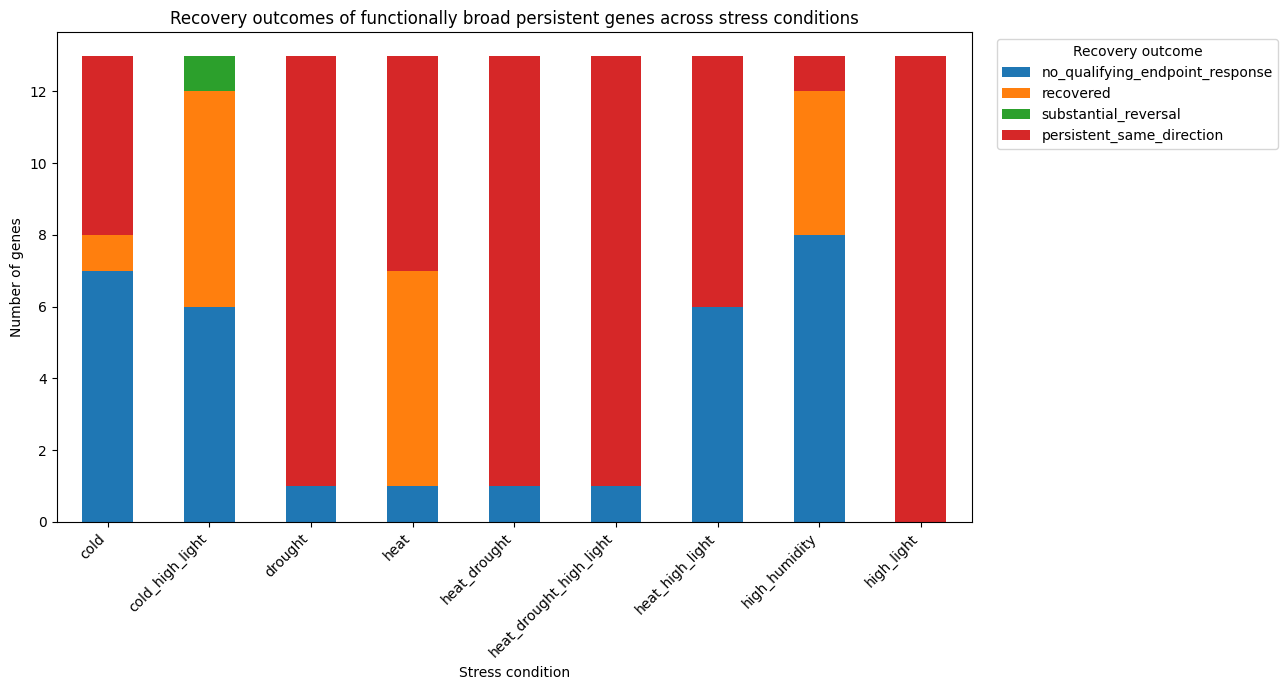

In [234]:
recovery_plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7)
)

plt.xlabel("Stress condition")
plt.ylabel("Number of genes")
plt.title(
    "Recovery outcomes of functionally broad persistent genes across stress conditions"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Recovery outcome",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### **Insight —** Stress-Specific Engagement and Recovery of the Cross-Community Gene Set

#### The 13 genes represented in at least three functional communities showed clearly different response and recovery patterns across stress conditions. High light produced the strongest persistence pattern: all 13 genes showed qualifying endpoint responses, and all remained persistently displaced from control in the recovery samples. Drought, heat+drought, and heat+drought+high-light showed a similar pattern, with all 12 qualifying responders remaining persistent.

#### In contrast, heat produced qualifying endpoint responses in 12 genes but showed much greater recovery, with 6 of the 12 responders recovering. Cold+high-light showed the strongest recovery pattern: seven genes had qualifying endpoint responses, six recovered and one substantially reversed, leaving no persistent genes. High humidity combined relatively limited endpoint response with predominantly recovered responses.

#### These results show that a low number of persistent genes can arise for different reasons. In some conditions, relatively few genes show a qualifying endpoint response in the first place, whereas in others, many genes respond at endpoint but no longer remain displaced from control in the recovery samples. These two aspects vary considerably across stress conditions.

#### Because these 13 genes were selected for both high persistence breadth and broad functional-community representation, the patterns describe this selected gene set rather than the transcriptome as a whole. Interpretation of the heat+drought+high-light condition should also retain the earlier QC caution concerning the atypical `endpoint_T 2` replicate.

### Visualizing Gene-Level Recovery-State Profiles Across Stress Conditions

#### The recovery categories of the 13 high-community-breadth genes were converted to discrete numeric codes solely for visualization and displayed as a gene-by-condition categorical matrix. Each cell represents the recovery state of one gene under one stress condition: no qualifying endpoint response, recovery, substantial reversal, or persistence in the same direction.

#### This visualization complements the stress-level stacked bar chart by preserving individual gene identities. It allows recovery patterns to be examined both across genes within a stress condition and across stress conditions for the same gene. The numeric codes are categorical plotting labels and do not represent an ordered biological scale.

In [235]:
recovery_state_codes = {                                 # converting the biological categories into numeric codes for better plotting
    "no_qualifying_endpoint_response": 0,
    "recovered": 1,
    "substantial_reversal": 2,
    "persistent_same_direction": 3,
}                                                        # this numeric codes are category codes not biological scores

high_bridge_recovery_numeric = (                         # converting the whole recovery matrix into these codes
    high_bridge_recovery_matrix
    .apply(
        lambda column:
            column.map(recovery_state_codes)
    )
    .astype(int)
)

In [236]:
high_bridge_recovery_numeric                            # inspecting the numeric matrix

,cold,cold_high_light,drought,heat,heat_drought,heat_drought_high_light,heat_high_light,high_humidity,high_light
gene_id,,,,,,,,,
AT3G56400,0,0,3,1,3,3,3,0,3
AT4G02380,1,1,3,1,3,3,0,1,3
AT1G21250,3,2,3,3,3,3,3,0,3
AT3G26830,3,1,3,3,3,3,3,0,3
AT3G49120,3,1,3,3,3,3,3,0,3
AT2G40750,3,1,3,3,0,3,3,0,3
AT3G01420,0,0,3,3,3,3,0,3,3
AT1G73260,0,0,3,3,3,3,0,1,3
AT2G38470,0,1,3,1,3,3,3,1,3


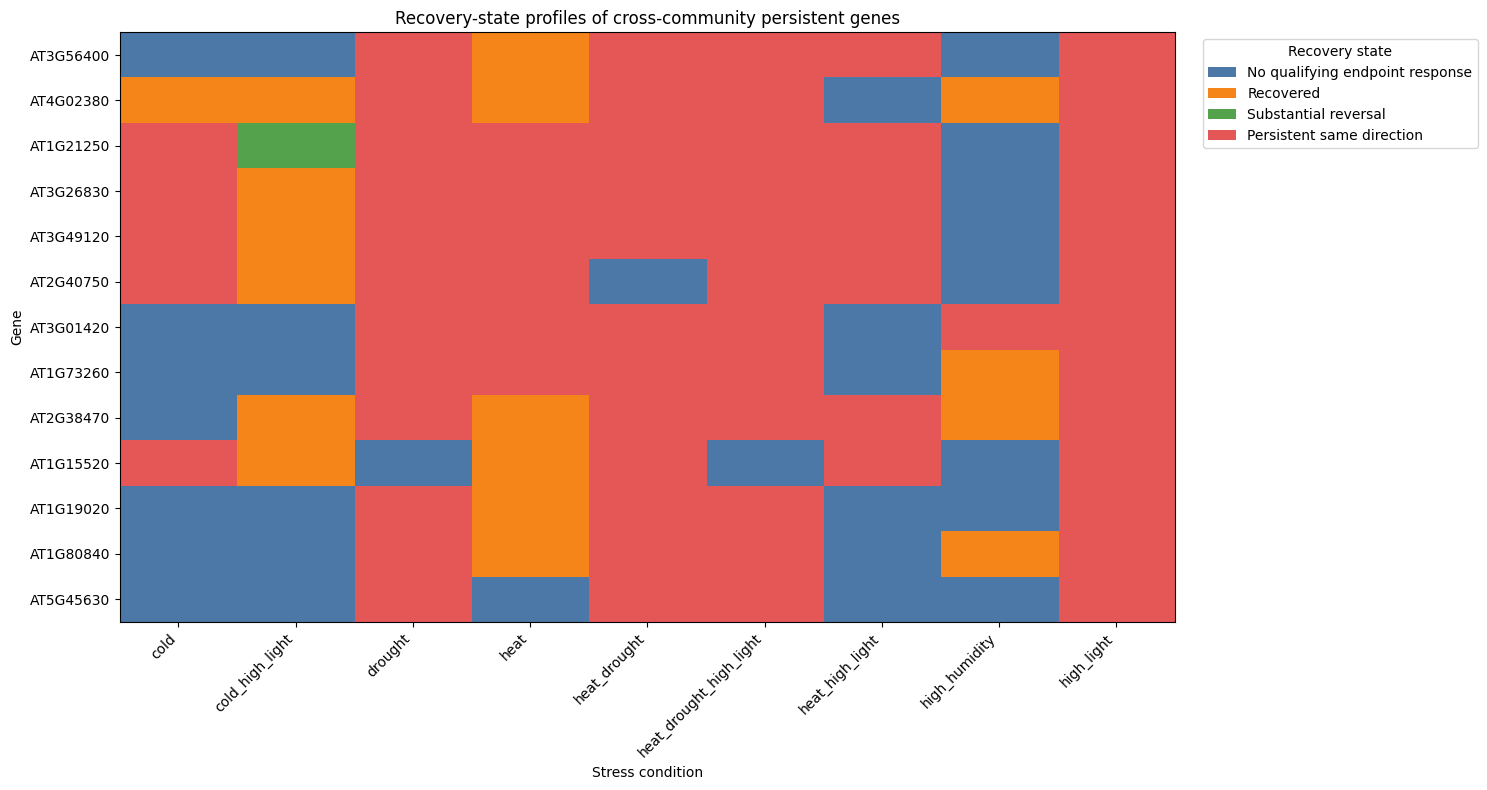

In [237]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

state_colors = [
    "#4C78A8",
    "#F58518",
    "#54A24B",
    "#E45756",
]

state_labels = [
    "No qualifying endpoint response",
    "Recovered",
    "Substantial reversal",
    "Persistent same direction",
]

cmap = ListedColormap(state_colors)

fig, ax = plt.subplots(
    figsize=(15, 8)
)

ax.imshow(
    high_bridge_recovery_numeric,
    cmap=cmap,
    vmin=-0.5,
    vmax=3.5,
    aspect="auto"
)

ax.set_xticks(
    range(
        len(
            high_bridge_recovery_numeric.columns
        )
    )
)

ax.set_xticklabels(
    high_bridge_recovery_numeric.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(
        len(
            high_bridge_recovery_numeric.index
        )
    )
)

ax.set_yticklabels(
    high_bridge_recovery_numeric.index
)

ax.set_xlabel(
    "Stress condition"
)

ax.set_ylabel(
    "Gene"
)

ax.set_title(
    "Recovery-state profiles of cross-community persistent genes"
)

legend_handles = [
    Patch(
        facecolor=color,
        label=label
    )
    for color, label in zip(
        state_colors,
        state_labels
    )
]

ax.legend(
    handles=legend_handles,
    title="Recovery state",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### **Insight —** Gene-Level Recovery Profiles of Cross-Community Persistent Genes

#### The gene-level recovery matrix shows that the 13 functionally broad genes share a strong persistence pattern, but their recovery outcomes still depend on the stress condition.

#### High light produced persistent same-direction responses in all 13 genes, while drought, heat+drought, and heat+drought+high-light were also dominated by persistence. In contrast, heat produced a mixture of persistent and recovered responses. Under cold+high-light, none of the selected genes remained persistent: six qualifying responders recovered, while AT1G21250 showed substantial reversal. High humidity produced qualifying endpoint responses in relatively few genes, and most of those responders recovered.

#### The matrix also shows that individual genes differ in the number and identity of stress conditions under which they remain persistent. Thus, these 13 genes share a broad tendency toward persistent expression, but they do not behave identically across stresses. Their recovery patterns remain strongly dependent on stress context.

### **Integrated Biological Interpretation**

#### The analysis identified a broad pattern of persistent expression shared across multiple environmental stress conditions, although this pattern was not equally represented across all stresses. Starting from **1,609 genes** that met the persistence criterion in at least one condition, **206 genes** were identified as persistent in four or more stress conditions. These high-breadth genes were overwhelmingly persistent **above control**, showing that broad persistence in this dataset is dominated by continued above-control expression rather than persistent below-control expression.

#### Functional enrichment showed that this high-breadth gene set was associated with a non-random collection of biological processes. GO-slim analysis identified broad enrichment for environmental and stress responses, signaling, membrane- and cell-wall-associated functions, transport, and related cellular processes. Detailed Biological Process enrichment refined this picture, identifying significant terms associated with abiotic stress, water deprivation and osmotic stress, abscisic acid, salicylic and jasmonic acid responses, defense-related processes, reactive oxygen species, hypoxia, wounding, temperature responses, and other stress-associated functions. The enrichment of pathogen- and immune-related terms does not mean that the plants experienced biotic stress. Instead, it shows that genes persistently associated with the abiotic-stress experiment also participate in broader plant defense and environmental-response functions.

#### Because many GO terms contain overlapping sets of genes, the gene sharing between significant terms was examined rather than treating every enriched term as an independent biological pathway. The resulting overlap network showed that strong gene sharing was concentrated within one large connected component rather than distributed evenly across all significant terms. Community analysis divided this component into four groups: one dominated by pathogen- and defense-related terms, one containing hormone, defense-regulation, redox, and damage-related terms, one dominated by abiotic-stress and acclimation terms, and a smaller defense-related group. Strong-overlap connections occurred more frequently within these communities than between them. The main grouping pattern also remained recognizable when the overlap threshold was varied, indicating that the communities were not simply produced by the exact **0.50** cutoff.

#### The communities were distinct but not supported by completely separate gene sets. Of the **102 unique genes** represented across the four communities, **55** occurred in only one community, while **47** appeared in at least two. Among the latter, **34 genes** appeared in two communities, **11** appeared in three, and two genes — `AT3G56400` and `AT4G02380` — appeared in all four. This shows that different functional groups are partly supported by different genes while still sharing a substantial subset of persistent genes. Community breadth describes the spread of a gene's GO annotations across the detected groups and should not by itself be interpreted as evidence that the gene coordinates or regulates those processes.

#### Combining community breadth with persistence across experimental conditions identified **13 genes** represented in at least three communities. Their annotations included WRKY transcription factors, a cell wall-associated kinase, peroxidases, a cytochrome P450 protein, and other stress-associated proteins. Several of these genes were also persistent across six or seven stress conditions. Functional-community breadth and persistence breadth therefore describe two different properties: the first measures how widely a gene is represented across the GO-term communities, while the second measures how many experimental stress conditions satisfy the persistence criterion for that gene.

#### Persistence direction among genes supporting the four communities was exceptionally consistent. Of the **102 genes**, **101 (99.0%)** remained above control in every condition in which they met the persistence criterion. This pattern was complete among genes represented in multiple communities: all **47 multi-community genes** remained above control across all of their persistent conditions. The only exception was `AT2G28190`, annotated as copper/zinc superoxide dismutase 2. This gene belonged only to Community 3 and showed persistent expression below control under drought, heat, and heat+drought, but above control under high humidity. The functional network is therefore supported almost entirely by genes showing persistent above-control expression, while retaining at least one clear example in which persistence direction depends on the stress condition.

#### The **13 high-community-breadth genes** also showed clear differences between stress conditions. Under **high light**, all 13 genes showed qualifying endpoint responses and all remained persistent in the recovery samples. **Drought, heat+drought, and heat+drought+high-light** each produced qualifying endpoint responses in **12 of 13 genes**, with every responder remaining persistent. Under **heat+high-light**, only seven genes showed qualifying endpoint responses, but all seven remained persistent. **Cold** produced qualifying endpoint responses in six genes, five of which remained persistent.

#### Other conditions showed much greater recovery among genes that had responded at endpoint. Under **heat**, 12 genes showed qualifying endpoint responses, but only six remained persistent while the other six were classified as recovered. Under **high humidity**, five genes showed qualifying endpoint responses and four of those were classified as recovered. **Cold+high-light** produced the clearest contrast with high light alone: seven genes showed qualifying endpoint responses, but none remained persistent in the recovery samples; six were classified as recovered and `AT1G21250` showed substantial reversal. Interpretation of the heat+drought+high-light result should retain the earlier QC caution concerning the atypical `endpoint_T 2` replicate.

#### These results show why persistence should not be interpreted from the final persistent-gene count alone. Two separate features contribute to the observed pattern: **how many genes show a qualifying endpoint response under a stress, and what state those responding genes show in the recovery samples**. Under heat+high-light, for example, the relatively small number of persistent genes resulted mainly from limited endpoint response across this gene set, because every qualifying responder remained persistent. Under heat, by contrast, endpoint response was broad, but half of the responders were classified as recovered. Cold+high-light differed again, with several qualifying endpoint responders but no persistent genes in the recovery samples.

#### Because these 13 genes were deliberately selected for broad persistence and broad representation across the GO-term communities, their recovery percentages should not be generalized to the transcriptome as a whole. They describe the behavior of a selected set of unusually broad persistent genes. The wider transcriptome can show a substantially different balance between persistence and recovery.

#### Overall, the analysis identifies a connected set of broadly persistent genes associated with several overlapping plant stress-response functions. These genes are predominantly characterized by persistent above-control expression, but their endpoint-response breadth and their recovery-state classification differ considerably between stress conditions. The results therefore support a shared but condition-dependent pattern of persistent expression rather than one universal response that behaves identically across all stresses. The high-breadth and multi-community genes identified here are best treated as **prioritized candidates for further investigation**, rather than as established regulators of stress memory or recovery.


### **Limitations**

#### Several limitations should be considered when interpreting this analysis.

#### First, the project uses the processed **rlog-transformed expression matrix** provided with `GSE226105` rather than raw sequencing reads or raw integer counts. rlog values are suitable for exploratory comparison, clustering, correlation analysis, PCA, and descriptive assessment of expression patterns, but they are not the appropriate input for formal count-based differential-expression models such as **DESeq2**. The persistence and recovery patterns identified here should therefore be interpreted as descriptive expression behavior rather than evidence of statistically significant differential expression. A separate raw-count differential-expression analysis is planned to test Endpoint vs Control, Recovery vs Control, and Recovery vs Endpoint contrasts and to determine how closely the exploratory persistence results agree with formal statistical inference.

#### Second, the **empirical response floor** used to define qualifying endpoint responses was derived from the **95th percentile of pairwise expression differences among control replicates**. This provides a data-informed exploratory threshold for separating larger expression differences from typical control-replicate variation, but it is not a conventional statistical significance cutoff and does not incorporate gene-specific variance estimates. The categories `recovered`, `persistent_same_direction`, and `substantial_reversal` therefore describe expression patterns relative to this operational threshold rather than hypothesis-test outcomes.

#### The endpoint and recovery samples also represent separate experimental groups rather than repeated measurements of the same individual plants. Consequently, terms such as recovery and persistence refer to differences between group-level expression states relative to control. They should not be interpreted as direct longitudinal tracking of expression within the same biological individuals.

#### **Each experimental group contains only three replicates**. This design is sufficient for exploratory comparison and replicate-level quality assessment, but estimates of group means and within-condition variability remain sensitive to individual samples. This is particularly relevant when interpreting conditions in which one replicate differs noticeably from the other two.

#### Third, quality control was performed on the **processed expression matrix** rather than on raw FASTQ files and sequencing-level metrics. The analysis could therefore assess sample concordance, expression distributions, replicate similarity, PCA structure, and related transcriptome-level patterns, but it could not independently evaluate read quality, adapter contamination, alignment quality, library complexity, or other upstream sequencing metrics.

#### One sample, `endpoint_T 2`, showed atypical behavior relative to the other heat+drought+high-light endpoint replicates. It was retained because the available evidence did not establish a clear technical failure, but interpretation of the triple-stress condition should retain this qualification. `endpoint_HEAT DROUGHT 3` also showed elevated within-treatment variability among highly variable genes, although it retained clear treatment identity and was not considered equivalent to the `endpoint_T 2` concern.

#### Fourth, **Gene Ontology** enrichment depends on the completeness, specificity, and evidence quality of existing **Arabidopsis** annotations. Some genes have extensive experimental or curated annotation, whereas others have fewer or less specific assigned terms. GO terms are also hierarchical and overlapping, meaning that several significant terms may describe related aspects of the same underlying gene set. The **overlap-network** and **community analyses** were used to examine this redundancy more directly, but the resulting communities remain annotation-based groups rather than experimentally demonstrated biological pathways.

#### The strong-overlap network also depends on an operational **overlap-coefficient threshold** of **0.50**. **Sensitivity analyses** at **0.40** and **0.60** showed that the main connected group and overall community pattern remained recognizable, supporting the conclusion that the result is not unique to the exact **0.50** cutoff. Nevertheless, the number of edges, component membership, and some peripheral terms change with the threshold. Network boundaries should therefore be treated as descriptive rather than absolute biological divisions.

#### Fifth, the **13 genes** examined in the **final recovery analysis** were deliberately selected because they showed both **high persistence breadth** and **broad representation** across the GO-term communities**. They are therefore a **selected high-breadth subset** rather than an unbiased sample of the transcriptome. Percentages calculated within this group, such as complete persistence among qualifying high-light responders, should not be generalized to the overall transcriptomic response. Earlier transcriptome-wide analyses showed that some stresses can have substantially different recovery patterns from those observed within this selected gene set.

#### Sixth, **transcriptional persistence** does not by itself establish physiological stress memory, causal regulation, protein activity, or phenotypic consequence. Changes in RNA abundance may not translate directly into corresponding changes in protein abundance or activity. Similarly, genes represented across several functional communities should not automatically be interpreted as master regulators or as causal links between biological processes. Community breadth and related terms are used here as descriptive properties of annotation and expression patterns.

#### Finally, the biological interpretation is based primarily on a single study and experimental design. Confidence in the identified persistent-expression candidates would be strengthened by validation in independent **Arabidopsis** stress datasets, particularly studies using comparable tissues, developmental stages, stress intensities, and recovery intervals. External datasets should be used for validation and biological context rather than directly combined with the present dataset when technologies, protocols, or experimental designs differ substantially.

### **Biological Conclusions**

#### This analysis supports several main biological conclusions.

#### First, recovery from environmental stress is not simply the disappearance of the endpoint expression response. Across the nine stress conditions, genes showed several different recovery-state patterns, including return toward the control range, persistence in the same direction, and occasional substantial reversal. The balance among these outcomes differed considerably between stress conditions.

#### Second, a subset of genes showed persistent expression across multiple environmental contexts. A total of **1,609 genes** met the persistence criterion in at least one stress condition, while **206 genes** were persistent in four or more conditions. Broad persistence was overwhelmingly characterized by expression remaining **above control**, showing that the shared high-breadth persistence pattern is dominated by continued above-control expression rather than persistent below-control expression.

#### Third, the high-breadth persistent gene set was functionally non-random. GO-slim and detailed Biological Process enrichment showed overrepresentation of stress- and environmental-response functions, including abiotic-stress responses, hormone-associated signaling, defense-related processes, redox responses, transport, and membrane- and cell-wall-associated functions. These results show that broadly persistent genes are concentrated within related stress-response functions rather than representing an arbitrary collection of expressed genes.

#### Fourth, the enriched Biological Process terms showed substantial local gene sharing without collapsing into one homogeneous functional group. Gene-overlap analysis revealed a large connected network containing several distinct communities. These included groups dominated by pathogen- and defense-related responses, hormone–defense–redox regulation, abiotic stress and acclimation, and a smaller defense-related group. Sensitivity analyses showed that the main connected structure and community pattern remained recognizable when the overlap threshold was changed, indicating that these patterns were not unique to the exact **0.50** cutoff.

#### Fifth, the functional communities were partly distinct but connected through shared genes. Of the **102 genes** represented across the four main communities, **47** appeared in at least two communities, **11** appeared in three, and two — `AT3G56400` and `AT4G02380` — appeared in all four. These multi-community genes are therefore useful candidates for further study because their annotations span several stress-related functional groups, although community breadth alone does not establish causal regulation or coordination between those processes.

#### Sixth, the genes with the broadest functional representation also showed substantial experimental persistence. **Thirteen genes** appeared in at least three functional communities, and several were persistent across six or seven stress conditions. All 13 remained **above control** in every condition in which they met the persistence criterion. This identifies a small group of genes that combine broad functional representation with repeated persistence across different environmental stresses.

#### Finally, the behavior of this 13-gene set depended strongly on stress context. **High light** produced qualifying endpoint responses in all 13 genes, and all remained persistent in the recovery samples. **Drought, heat+drought, and heat+drought+high-light** also showed strong persistence among qualifying responders. By contrast, **heat** produced broad endpoint responses but substantial recovery, **high humidity** showed limited endpoint response and predominantly recovered responders, and **cold+high-light** produced several qualifying endpoint responses but no persistent genes within this selected set. These results show that **endpoint-response breadth and recovery outcome are separate properties** and can differ considerably between stresses.

#### Overall, the results support a picture in which Arabidopsis recovery involves both reversible and persistent expression responses. A shared set of broadly persistent genes is associated with several overlapping stress-response functions, but the extent to which these genes respond at endpoint and remain displaced from control in recovery samples depends strongly on the stress condition. The identified genes and functional communities therefore provide **prioritized candidates for formal differential-expression testing and independent biological validation**, rather than definitive evidence of stress memory or causal regulatory mechanisms.